# Question-Driven NLP Assistant for Business Insight Extraction
## MSc Data Science - STU237014

### Pipeline overview
| Stage | Method | Key output |
|-------|--------|-----------|
| 1. Data loading | Yelp Open Dataset (50,000 reviews) | `df_reviews` |
| 2. Preprocessing | Lowercasing, stopword removal, lemmatisation | `clean_text` |
| 3. Sentiment | VADER -> Logistic Regression -> BERT | Accuracy, F1, McNemar |
| 4. Topic modelling | LDA (11 topics) vs BERTopic | C_V coherence, alignment |
| 5. ABSA | DeBERTa-v3, 5 aspects, 2,000 reviews | Aspect sentiment % |
| 6. Dashboard | Streamlit + ngrok | Interactive Q1-Q5 |


# EDA

## Data loading

In [1]:
import kagglehub
path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")

Using Colab cache for faster access to the 'yelp-dataset' dataset.


In [2]:
!pip install transformers torch gensim bertopic umap-learn hdbscan streamlit pyngrok pymannkendall -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.2 MB/s eta 0:00:00


In [3]:
import os
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import random
import re
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

try:
    import pymannkendall as mk
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pymannkendall', '-q'])
    import pymannkendall as mk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_recall_fscore_support


import pickle
import torch, transformers

from transformers import BertTokenizer, BertForSequenceClassification, BertModel, get_linear_schedule_with_warmup, pipeline
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from scipy import stats as stats

import gensim
from gensim import corpora
from gensim.models import LdaModel, Phrases
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.phrases import Phraser

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

from gensim.corpora import Dictionary

from pyngrok import ngrok
from google.colab import userdata
import subprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")
# Set style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
colors = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#f39c12',
    'blue': '#3498db',
    'dark': '#2c3e50'
}

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [4]:
review_path = os.path.join(path, 'yelp_academic_dataset_review.json')
business_path = os.path.join(path, 'yelp_academic_dataset_business.json')

# Load 50,000 reviews
reviews = []
with open(review_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 50000:
            break
        reviews.append(pd.read_json(line, typ='series'))

df_reviews = pd.DataFrame(reviews)

# Quick check
print("Shape:", df_reviews.shape)
print("\nColumns:", df_reviews.columns.tolist())
print("\nFirst 3 rows:")
df_reviews.head(3)

Shape: (50000, 9)

Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']

First 3 rows:


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


In [5]:
assert df_reviews.shape[0] == 50000, f"Expected 50,000 reviews, got {df_reviews.shape[0]}"
assert 'stars' in df_reviews.columns and 'text' in df_reviews.columns, "Missing required columns"
assert df_reviews['stars'].between(1, 5).all(), "Found star ratings outside 1-5 range"
print("Data load checks passed.")

Data load checks passed.


## Data Overview

In [6]:
# 1. General overview
print("=== DATA OVERVIEW ===")
print(f"Total reviews: {len(df_reviews):,}")
print(f"Total columns: {df_reviews.shape[1]}")
print(f"\nMissing values:\n{df_reviews.isnull().sum()}")

duplicate_review_id = df_reviews.duplicated(subset=["review_id"]).sum()
print(f"\nDuplicate review_id: {duplicate_review_id}")

=== DATA OVERVIEW ===
Total reviews: 50,000
Total columns: 9

Missing values:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

Duplicate review_id: 0



=== STAR RATING DISTRIBUTION ===
stars
1.0     5379
2.0     4003
3.0     5677
4.0    12721
5.0    22220
Name: count, dtype: int64


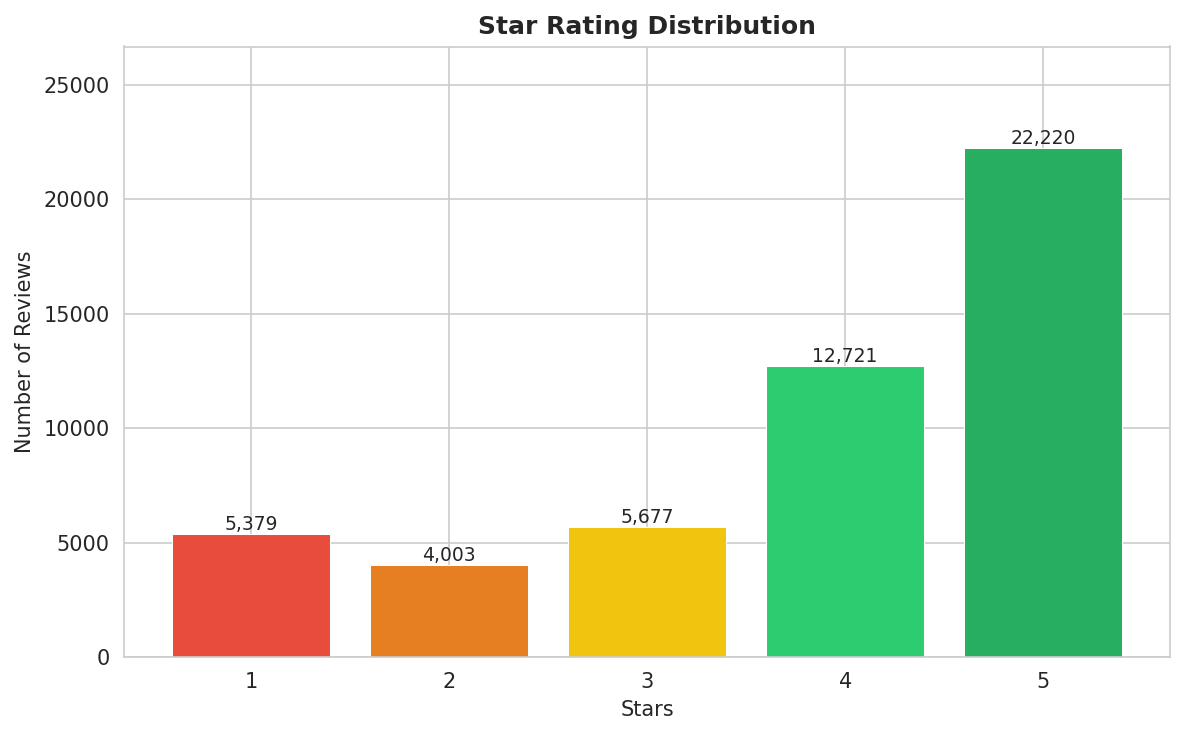

In [7]:
# 2. Star rating distribution
print("\n=== STAR RATING DISTRIBUTION ===")
print(df_reviews['stars'].value_counts().sort_index())

# Plot star rating distribution
star_counts = df_reviews['stars'].value_counts().sort_index()

plt.figure(figsize=(8,5))

bars = plt.bar(
    star_counts.index,
    star_counts.values,
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
    edgecolor='white',
    linewidth=0.5
)

plt.title('Star Rating Distribution', fontweight='bold')
plt.xlabel('Stars')
plt.ylabel('Number of Reviews')
plt.ylim(0, star_counts.max() * 1.2)

for bar, val in zip(bars, star_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks([1,2,3,4,5])

plt.tight_layout()
plt.show()



=== REVIEW TEXT LENGTH ===
Average: 547 characters
Shortest: 3 characters
Longest: 4997 characters


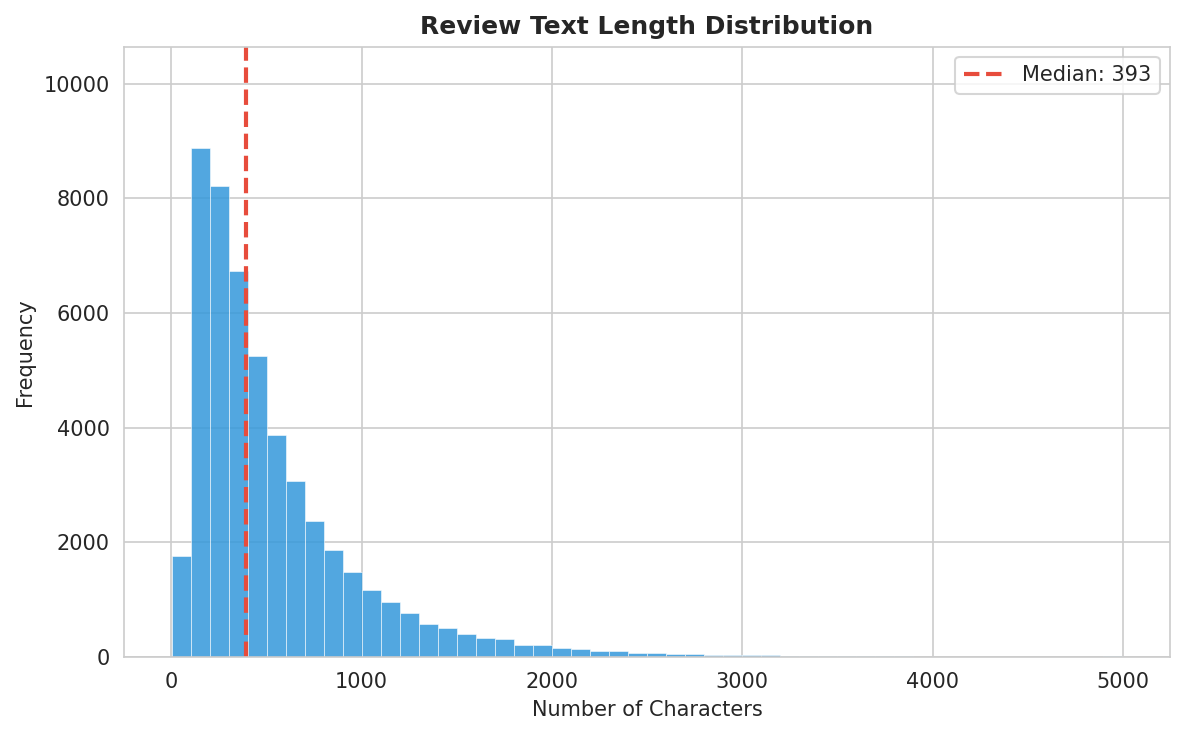

In [8]:
# 3. Review text length
df_reviews['text_length'] = df_reviews['text'].apply(len)
print(f"\n=== REVIEW TEXT LENGTH ===")
print(f"Average: {df_reviews['text_length'].mean():.0f} characters")
print(f"Shortest: {df_reviews['text_length'].min()} characters")
print(f"Longest: {df_reviews['text_length'].max()} characters")

plt.figure(figsize=(8,5))

plt.hist(
    df_reviews['text_length'],
    bins=50,
    color=colors['blue'],
    edgecolor='white',
    linewidth=0.3,
    alpha=0.85
)

# mean line
median_length = df_reviews['text_length'].median()

plt.axvline(
    median_length,
    color=colors['negative'],
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_length:.0f}'
)

plt.title('Review Text Length Distribution', fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

# y max = max frequency * 1.2
counts, _ = np.histogram(df_reviews['text_length'], bins=50)
plt.ylim(0, counts.max() * 1.2)

plt.legend()
plt.tight_layout()
plt.show()

=== SENTIMENT DISTRIBUTION ===
sentiment
positive    34941
negative     9382
neutral      5677
Name: count, dtype: int64


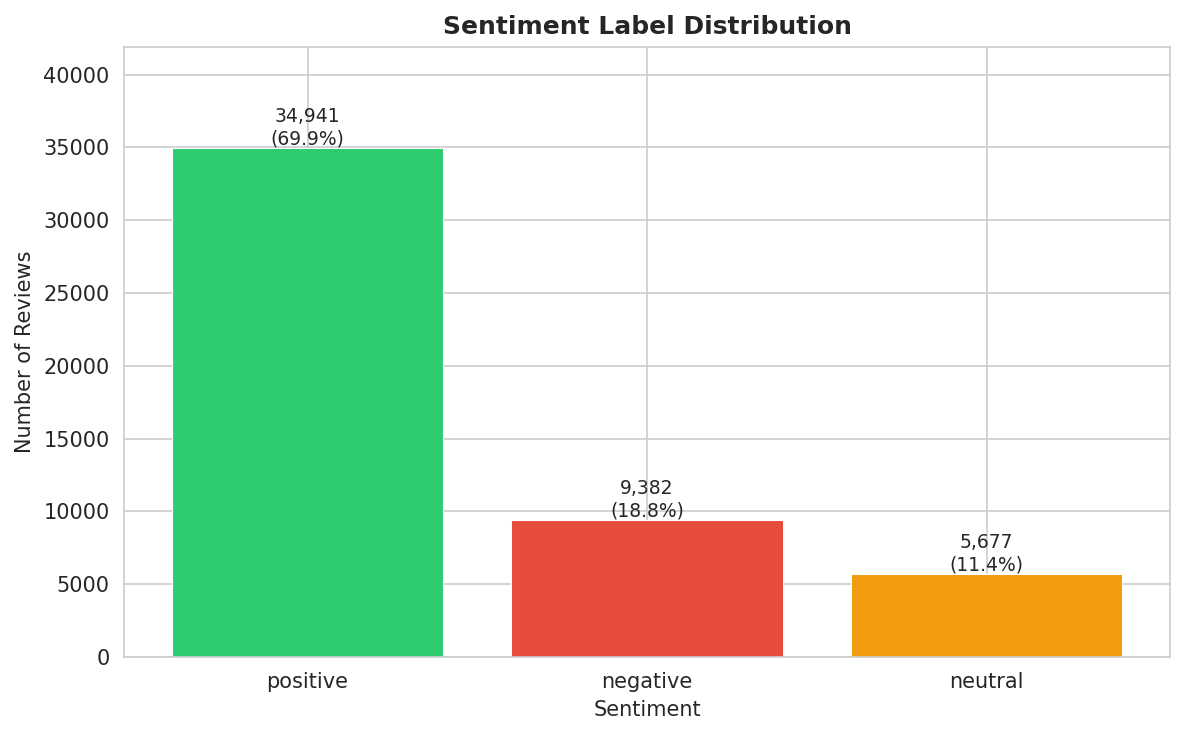

In [9]:
# 4.Create sentiment labels from star ratings
def stars_to_sentiment(stars):
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

df_reviews['sentiment'] = df_reviews['stars'].apply(stars_to_sentiment)

# Check the distribution
print("=== SENTIMENT DISTRIBUTION ===")
print(df_reviews['sentiment'].value_counts())

# Plot
sentiment_counts = df_reviews['sentiment'].value_counts()
sentiment_colors = [colors['positive'], colors['negative'], colors['neutral']]

plt.figure(figsize=(8,5))

bars2 = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=sentiment_colors,
    edgecolor='white',
    linewidth=0.5
)

plt.title('Sentiment Label Distribution', fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.ylim(0, sentiment_counts.max() * 1.2)
# value labels
for bar, val in zip(bars2, sentiment_counts.values):
    pct = val/len(df_reviews)*100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [10]:
assert df_reviews['sentiment'].isnull().sum() == 0, "Found reviews with no sentiment label"
assert set(df_reviews['sentiment'].unique()) <= {'positive', 'negative', 'neutral'}, "Unexpected sentiment value"
assert len(df_reviews) == 50000, "Row count changed during labeling - check for silent drops"
print("Sentiment labeling checks passed.")

Sentiment labeling checks passed.


## Text Preprocessing

In [11]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [12]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+', '', text)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Tokenise
    tokens = text.split()
    # 5. Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Apply to all 50,000 reviews
print("Preprocessing text")
df_reviews['clean_text'] = df_reviews['text'].apply(preprocess_text)

# Compare original vs cleaned
df_reviews[["text", "clean_text"]].head()

Preprocessing text


,text,clean_text
0,"If you decide to eat here, just be aware it is...",decide eat aware going take hour beginning end...
1,I've taken a lot of spin classes over the year...,ive taken lot spin class year nothing compare ...
2,Family diner. Had the buffet. Eclectic assortm...,family diner buffet eclectic assortment large ...
3,"Wow! Yummy, different, delicious. Our favo...",wow yummy different delicious favorite lamb cu...
4,Cute interior and owner (?) gave us tour of up...,cute interior owner gave u tour upcoming patio...


In [13]:
# Save dataframe at this checkpoint
df_reviews.to_csv('yelp_reviews_cleaned.csv', index=False)
print("Saved to yelp_reviews_cleaned.csv")

Saved to yelp_reviews_cleaned.csv


In [14]:
assert df_reviews['clean_text'].isnull().sum() == 0, "Found null values in clean_text"
assert (df_reviews['clean_text'].str.len() > 0).mean() > 0.99, "Too many reviews became empty after cleaning"
print("Preprocessing checks passed.")

Preprocessing checks passed.


# Business Category Analysis

In [15]:
# Load business metadata and merge with reviews
businesses = []
with open(business_path, 'r', encoding='utf-8') as f:
    for line in f:
        businesses.append(pd.read_json(line, typ='series'))

df_business = pd.DataFrame(businesses)[['business_id', 'categories', 'city', 'state']]
print(f'Business records loaded: {len(df_business):,}')

# Merge with reviews
df_merged = df_reviews.merge(df_business, on='business_id', how='left')
print(f'Merged shape: {df_merged.shape}')
print(f"Categories coverage: {df_merged['categories'].notna().mean()*100:.1f}%")


Business records loaded: 150,346
Merged shape: (50000, 15)
Categories coverage: 100.0%


In [16]:
# Category sentiment comparison
category_list = [
    'Restaurants', 'Hotels', 'Hair Salons',
    'Auto Repair', 'Coffee', 'Bars', 'Shopping'
]
category_results = []
for cat in category_list:
    mask = df_merged['categories'].str.contains(cat, case=False, na=False)
    subset = df_merged[mask]
    if len(subset) < 50:
        continue
    pos_pct = (subset['sentiment']=='positive').mean()*100
    neg_pct = (subset['sentiment']=='negative').mean()*100
    avg_star = subset['stars'].mean()
    category_results.append({
        'Category': cat,
        'Reviews': len(subset),
        'Positive %': round(pos_pct,1),
        'Negative %': round(neg_pct,1),
        'Avg Stars': round(avg_star,2)
    })
cat_df = pd.DataFrame(category_results).sort_values('Positive %', ascending=False)
print(cat_df.to_string(index=False))


   Category  Reviews  Positive %  Negative %  Avg Stars
Hair Salons      798        79.7        16.9       4.16
     Coffee     4031        73.6        15.7       3.98
   Shopping     3092        73.2        18.2       3.95
       Bars    13723        69.7        17.5       3.86
Restaurants    36149        68.6        18.8       3.81
Auto Repair      717        65.3        30.4       3.63
     Hotels     3009        65.1        22.8       3.67


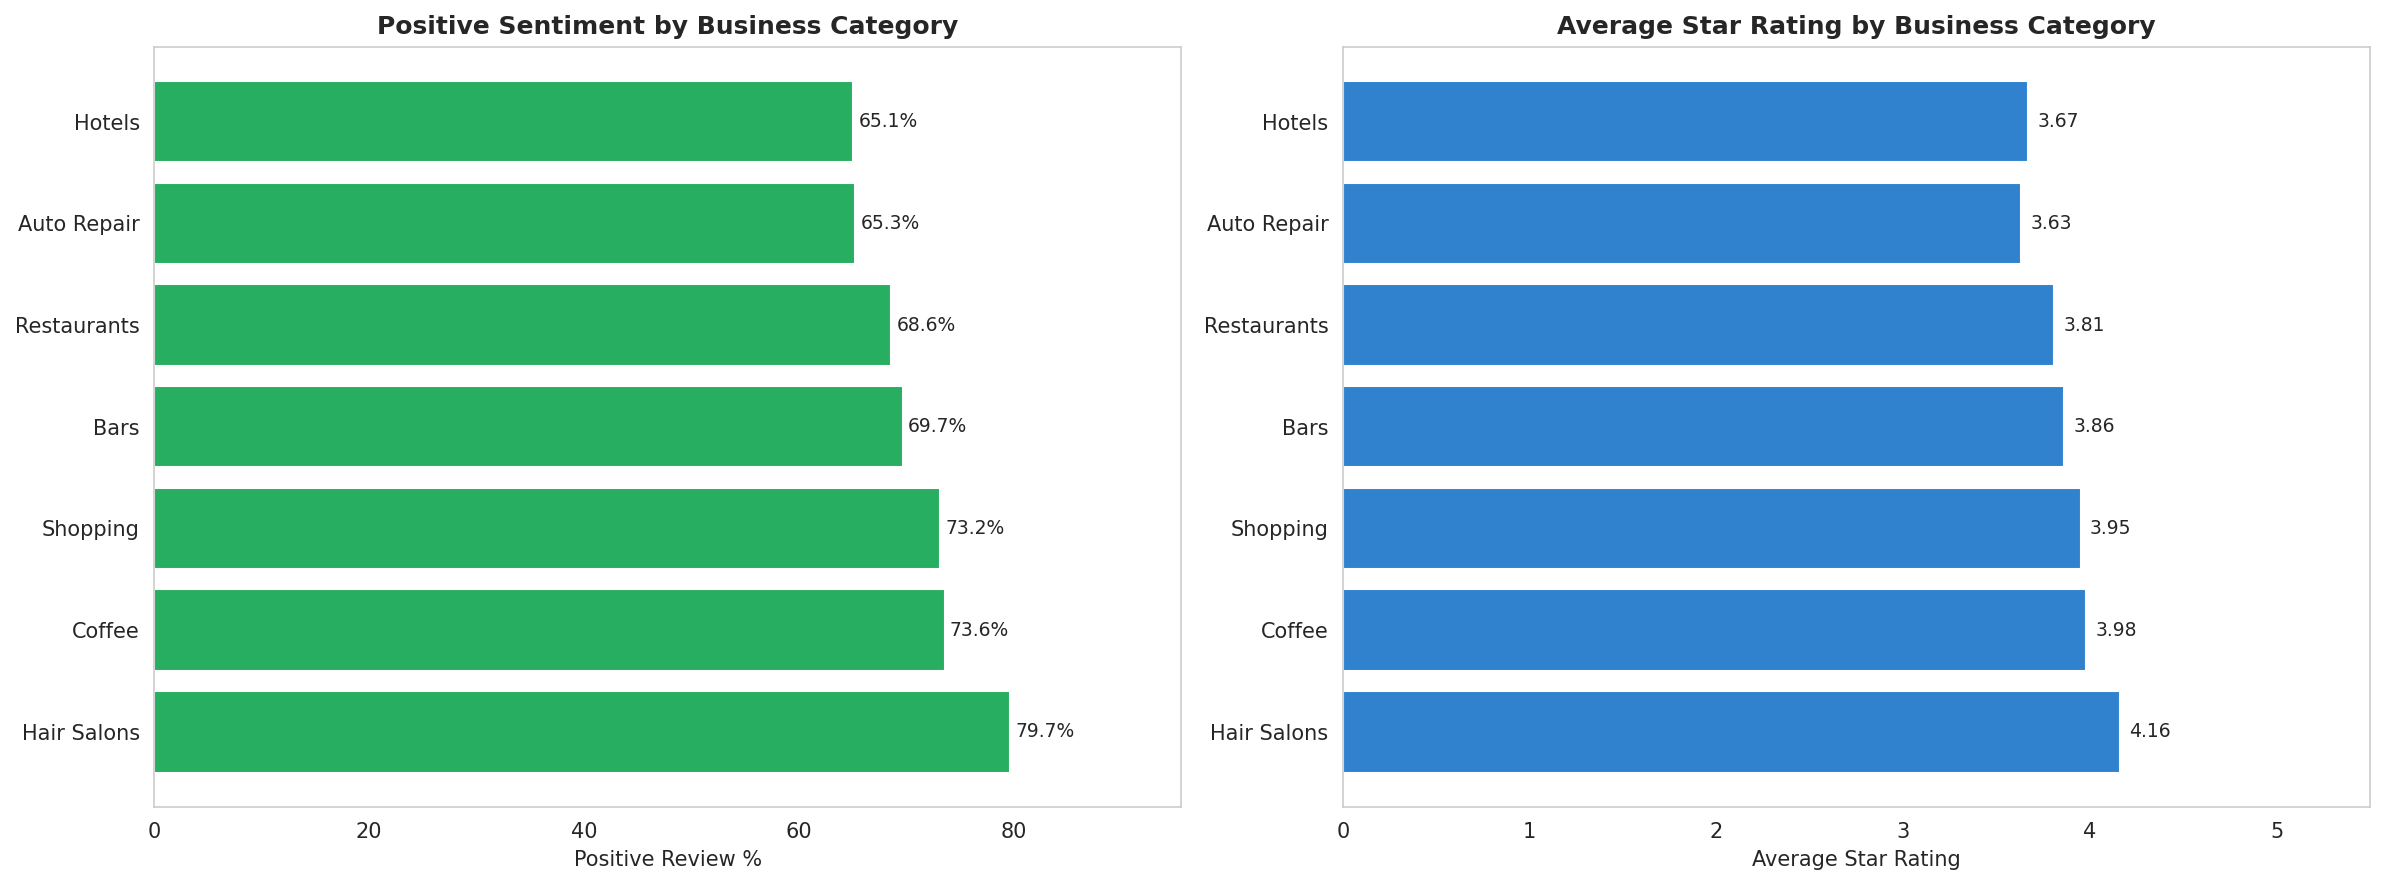

In [17]:
# Visualise category comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(
    cat_df['Category'],
    cat_df['Positive %'],
    color='#27ae60',
    edgecolor='white'
)

axes[0].set_xlabel('Positive Review %')
axes[0].set_title(
    'Positive Sentiment by Business Category',
    fontweight='bold'
)
axes[0].set_xlim(0, cat_df['Positive %'].max() * 1.2)
axes[0].grid(False)

for bar, val in zip(bars1, cat_df['Positive %']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )

bars2 = axes[1].barh(
    cat_df['Category'],
    cat_df['Avg Stars'],
    color='#3182ce',
    edgecolor='white'
)

axes[1].set_xlabel('Average Star Rating')
axes[1].set_title(
    'Average Star Rating by Business Category',
    fontweight='bold'
)
axes[1].set_xlim(0, 5.5)
axes[1].grid(False)

for bar, val in zip(bars2, cat_df['Avg Stars']):
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [18]:
# Save merged dataframe for Streamlit dashboard
df_merged.to_csv('yelp_reviews_merged.csv', index=False)
print('Saved yelp_reviews_merged.csv  shape:', df_merged.shape)

Saved yelp_reviews_merged.csv  shape: (50000, 15)


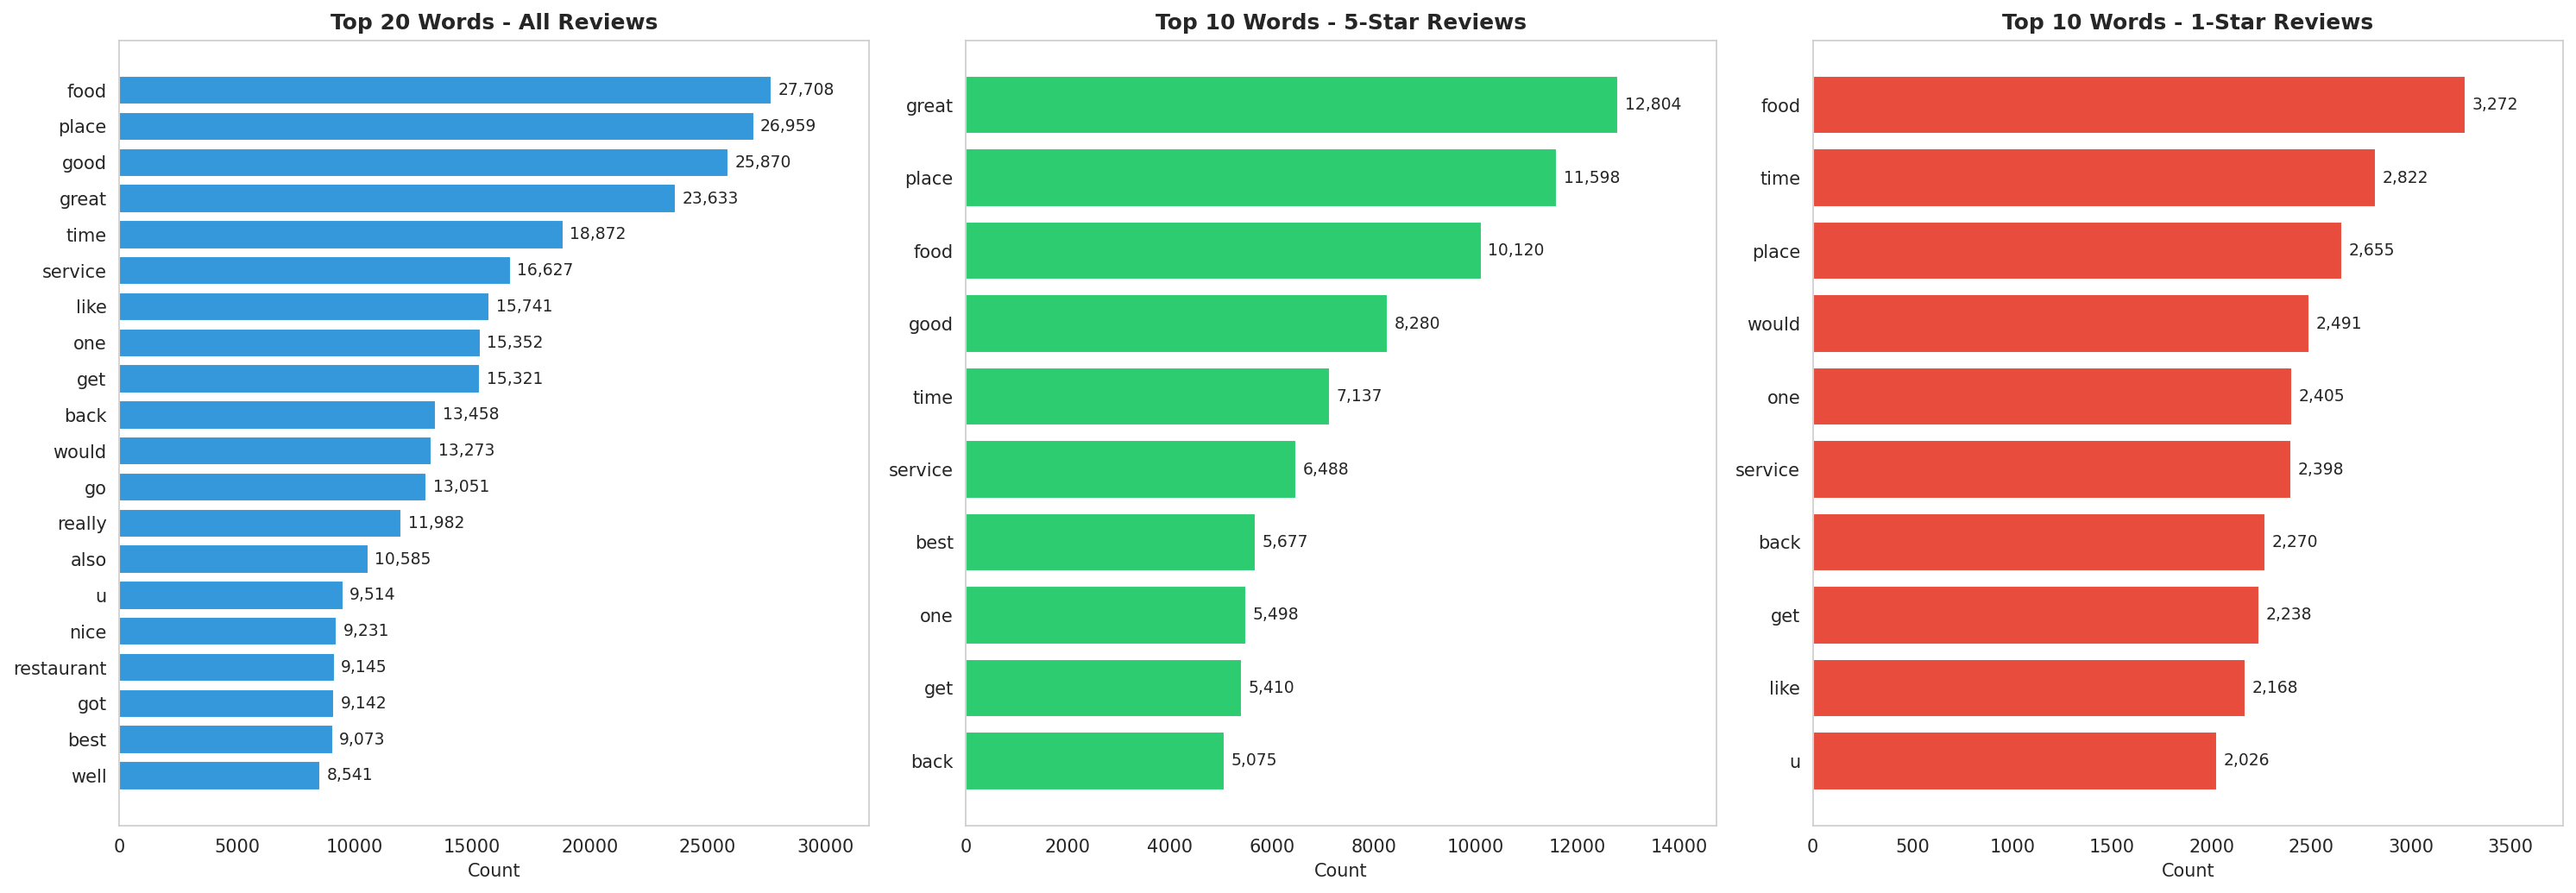

In [19]:
# Count words
all_words = ' '.join(df_reviews['clean_text']).split()

pos_words = ' '.join(df_reviews[df_reviews['stars'] == 5]['clean_text']).split()
neg_words = ' '.join(df_reviews[df_reviews['stars'] == 1]['clean_text']).split()

top_all = Counter(all_words).most_common(20)
top_pos = Counter(pos_words).most_common(10)
top_neg = Counter(neg_words).most_common(10)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

charts = [
    (top_all, 'Top 20 Words - All Reviews', '#3498db'),
    (top_pos, 'Top 10 Words - 5-Star Reviews', '#2ecc71'),
    (top_neg, 'Top 10 Words - 1-Star Reviews', '#e74c3c')
]

for ax, (data, title, color) in zip(axes, charts):
    words, counts = zip(*data)

    bars = ax.barh(
        words[::-1],
        counts[::-1],
        color=color
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')

    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + max(counts)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{int(width):,}',
            va='center',
            fontsize=9
        )

    ax.set_xlim(0, max(counts) * 1.15)
    ax.grid(False)

plt.tight_layout()
plt.show()

# OVERALL MANN-KENDALL TREND TEST

In [20]:
df_reviews['date']  = pd.to_datetime(df_reviews['date'])
df_reviews['month'] = df_reviews['date'].dt.to_period('M')

monthly_positive_pct = (
    df_reviews.groupby('month')
    .apply(lambda g: (g['sentiment'] == 'positive').mean() * 100)
)

print(f"Months covered: {len(monthly_positive_pct)}")
print(monthly_positive_pct.round(1))

series = monthly_positive_pct.dropna().values
result = mk.original_test(series)

print(f"\ntrend={result.trend}  p={result.p:.4f}  tau={result.Tau:+.4f}  "
      f"slope={result.slope:+.4f} pts/month  (n_months={len(series)})")

Months covered: 143
month
2005-03     60.0
2005-04     66.7
2005-05     77.8
2005-06    100.0
2005-07     58.8
           ...  
2018-06     73.7
2018-07     74.3
2018-08     75.0
2018-09     72.5
2018-10     77.3
Freq: M, Length: 143, dtype: float64

trend=increasing  p=0.0072  tau=+0.1518  slope=+0.0333 pts/month  (n_months=143)


In [21]:
# Sensitivity check for the Q4 trend: repeat Mann-Kendall on months with enough reviews
MIN_REVIEWS = 30
monthly = df_reviews.groupby('month').agg(
    n=('sentiment', 'size'),
    pos_pct=('sentiment', lambda s: (s == 'positive').mean() * 100)
)
print(f"Months with >= 1 review : {len(monthly)}")
print(f"Months with >= {MIN_REVIEWS} reviews: {(monthly['n'] >= MIN_REVIEWS).sum()}")
sub = monthly.loc[monthly['n'] >= MIN_REVIEWS, 'pos_pct']
if len(sub) >= 10:
    r = mk.original_test(sub.values)
    print(f"Restricted test: trend={r.trend}  p={r.p:.4f}  tau={r.Tau:+.4f}  slope={r.slope:+.4f} pts/month  (n_months={len(sub)})")
else:
    print("Too few months meet the threshold for a meaningful test.")


Months with >= 1 review : 143
Months with >= 30 reviews: 115
Restricted test: trend=increasing  p=0.0000  tau=+0.3056  slope=+0.0524 pts/month  (n_months=115)


# Baseline sentiment classifier

## Vader

In [22]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Function to predict sentiment using VADER
def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER on original text
print("Running VADER predictions... please wait")
df_reviews['vader_sentiment'] = df_reviews['text'].apply(vader_predict)

# Check predictions distribution
print("\n=== VADER PREDICTION DISTRIBUTION ===")
print(df_reviews['vader_sentiment'].value_counts())

Running VADER predictions... please wait

=== VADER PREDICTION DISTRIBUTION ===
vader_sentiment
positive    43727
negative     5663
neutral       610
Name: count, dtype: int64


=== VADER PERFORMANCE ===
              precision    recall  f1-score   support

    negative       0.77      0.46      0.58      9382
     neutral       0.16      0.02      0.03      5677
    positive       0.78      0.98      0.87     34941

    accuracy                           0.77     50000
   macro avg       0.57      0.49      0.49     50000
weighted avg       0.71      0.77      0.72     50000



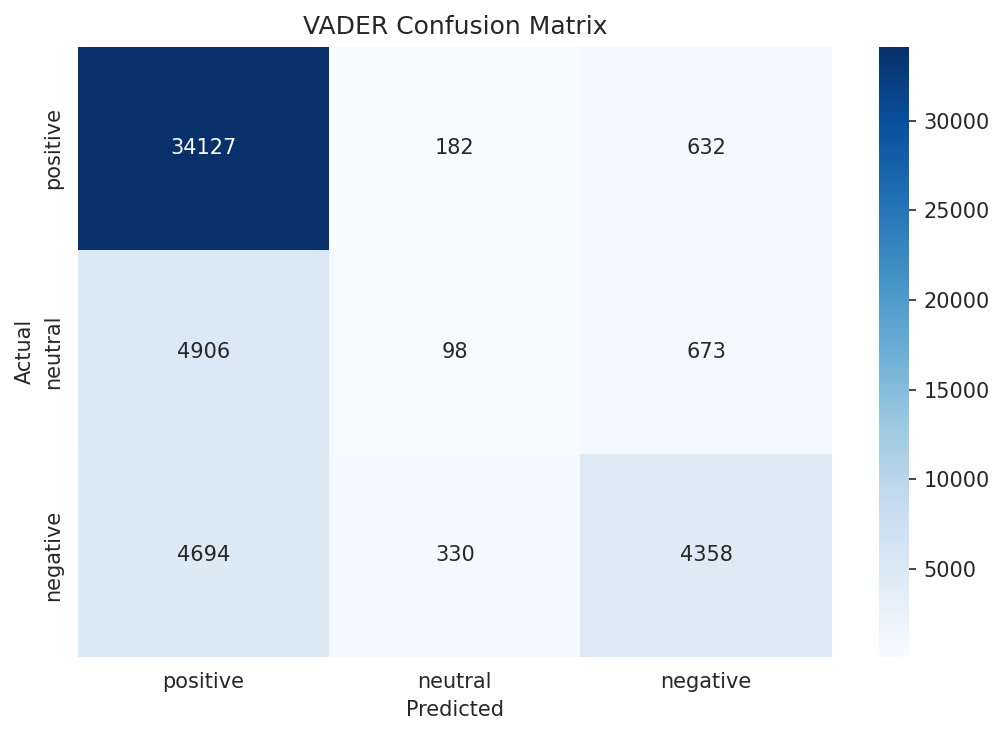

In [23]:
# Compare VADER predictions vs actual sentiment labels
print("=== VADER PERFORMANCE ===")
print(classification_report(df_reviews['sentiment'], df_reviews['vader_sentiment']))

# Confusion matrix
cm = confusion_matrix(df_reviews['sentiment'], df_reviews['vader_sentiment'],
                      labels=['positive', 'neutral', 'negative'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('VADER Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Logistics Regression

In [24]:
# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df_reviews['clean_text'],
    df_reviews['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_reviews['sentiment']
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

# Convert text to TF-IDF features
print("\nBuilding TF-IDF features")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression
print("Training Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = lr_model.predict(X_test_tfidf)
print("\n=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, y_pred))

Training samples: 40,000
Testing samples: 10,000

Building TF-IDF features
Training Logistic Regression

=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

    negative       0.81      0.78      0.80      1877
     neutral       0.56      0.26      0.36      1135
    positive       0.88      0.97      0.92      6988

    accuracy                           0.85     10000
   macro avg       0.75      0.67      0.69     10000
weighted avg       0.83      0.85      0.84     10000



In [25]:
# Save Logistic Regression model and TF-IDF vectorizer
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Models saved!")

Models saved!


## BERT

In [26]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [27]:
torch.use_deterministic_algorithms(True, warn_only=False)
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# Check GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [28]:
# Load BERT tokenizer
print("Loading BERT tokenizer")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Convert sentiment labels to numbers
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_reviews['label'] = df_reviews['sentiment'].map(label_map)

# Split data - same 80/20 split as before for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    df_reviews['text'],
    df_reviews['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_reviews['label']
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

# Create PyTorch Dataset
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets and dataloaders
train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset = ReviewDataset(X_test, y_test, tokenizer)

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, generator=g)

print(f" Train batches: {len(train_loader)}")
print(f" Test batches:  {len(test_loader)}")

Loading BERT tokenizer


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training samples: 40,000
Testing samples: 10,000
 Train batches: 1250
 Test batches:  313


In [29]:
assert len(X_train) + len(X_test) == len(df_reviews), "Train/test split doesn't sum to full dataset"
assert abs(len(X_test) / len(df_reviews) - 0.2) < 0.01, "Test split is not ~20% as intended"
assert set(y_train.unique()) == set(y_test.unique()), "Train/test have different label sets - stratification issue"
print("Train/test split checks passed.")

Train/test split checks passed.


In [30]:
seed_everything()

# Load pre-trained BERT model for classification (3 classes)
print("Loading BERT model")
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)
model = model.to(device)
print("BERT model loaded!")

# Training settings
EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# Training function
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)} | Loss: {total_loss/(batch_idx+1):.4f} | Acc: {correct/total:.4f}")

    return total_loss / len(loader), correct / total

# Evaluation function
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

# Train for 3 epochs
print("\n=== TRAINING BERT ===")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"Epoch {epoch + 1} complete | Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")

Loading BERT model


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded!

=== TRAINING BERT ===

Epoch 1/3
  Batch 100/1250 | Loss: 1.0681 | Acc: 0.4369
  Batch 200/1250 | Loss: 0.8307 | Acc: 0.6077
  Batch 300/1250 | Loss: 0.6964 | Acc: 0.6836
  Batch 400/1250 | Loss: 0.6187 | Acc: 0.7258
  Batch 500/1250 | Loss: 0.5664 | Acc: 0.7528
  Batch 600/1250 | Loss: 0.5354 | Acc: 0.7693
  Batch 700/1250 | Loss: 0.5111 | Acc: 0.7817
  Batch 800/1250 | Loss: 0.4915 | Acc: 0.7919
  Batch 900/1250 | Loss: 0.4768 | Acc: 0.7990
  Batch 1000/1250 | Loss: 0.4632 | Acc: 0.8057
  Batch 1100/1250 | Loss: 0.4520 | Acc: 0.8113
  Batch 1200/1250 | Loss: 0.4420 | Acc: 0.8165
Epoch 1 complete | Loss: 0.4372 | Accuracy: 0.8188

Epoch 2/3
  Batch 100/1250 | Loss: 0.2708 | Acc: 0.8962
  Batch 200/1250 | Loss: 0.2715 | Acc: 0.8958
  Batch 300/1250 | Loss: 0.2701 | Acc: 0.8960
  Batch 400/1250 | Loss: 0.2630 | Acc: 0.8983
  Batch 500/1250 | Loss: 0.2656 | Acc: 0.8978
  Batch 600/1250 | Loss: 0.2644 | Acc: 0.8985
  Batch 700/1250 | Loss: 0.2648 | Acc: 0.8984
  Batch 

In [31]:
# Evaluate on test set
print("Evaluating on test set...")
preds, labels = evaluate(model, test_loader, device)

# Convert numbers back to labels
label_names = ['negative', 'neutral', 'positive']
preds_named = [label_names[p] for p in preds]
labels_named = [label_names[l] for l in labels]

print("\n=== BERT TEST RESULTS ===")
print(classification_report(labels_named, preds_named))

# Save model
print("Saving BERT model...")
model.save_pretrained('bert_sentiment_model')
tokenizer.save_pretrained('bert_sentiment_model')
print("BERT model saved!")

Evaluating on test set...

=== BERT TEST RESULTS ===
              precision    recall  f1-score   support

    negative       0.83      0.85      0.84      1877
     neutral       0.54      0.48      0.51      1135
    positive       0.94      0.95      0.94      6988

    accuracy                           0.88     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.87      0.88      0.87     10000

Saving BERT model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved!


In [32]:
assert len(preds) == len(y_test), "Prediction count doesn't match test set size"
assert len(set(preds)) > 1, "Model predicted only one class - likely a training failure"
print("BERT evaluation checks passed.")

BERT evaluation checks passed.


## Comparison

                     Accuracy  Positive F1  Negative F1  Neutral F1
VADER                    0.77         0.87         0.57        0.03
Logistic Regression      0.85         0.92         0.80        0.36
BERT                     0.88         0.94         0.84        0.51


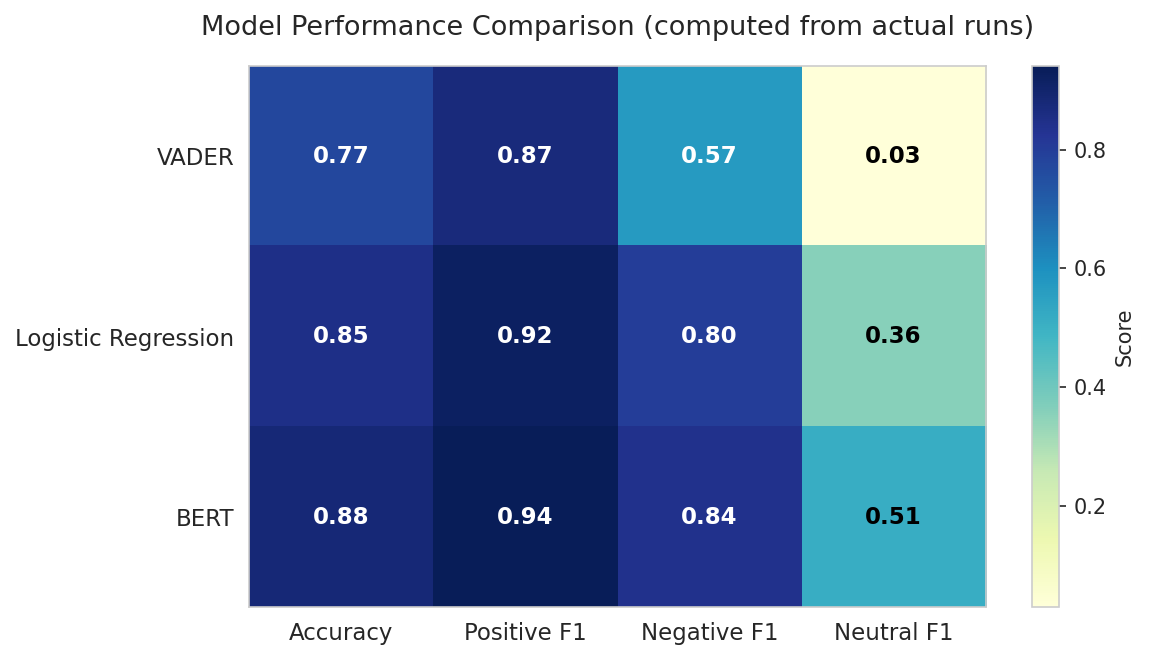

In [33]:
# Rebuild VADER preds on test set (same split)
_, X_test_raw, _, y_test_raw = train_test_split(
    df_reviews['text'], df_reviews['sentiment'],
    test_size=0.2, random_state=42, stratify=df_reviews['sentiment']
)
_, X_test_clean, _, _ = train_test_split(
    df_reviews['clean_text'], df_reviews['sentiment'],
    test_size=0.2, random_state=42, stratify=df_reviews['sentiment']
)

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

vader_preds   = X_test_raw.apply(vader_predict).values
y_test_vals   = y_test_raw.values

X_test_tfidf  = tfidf.transform(X_test_clean)
lr_preds      = lr_model.predict(X_test_tfidf)

label_names   = ['negative', 'neutral', 'positive']
bert_preds_named  = [label_names[p] for p in preds]
bert_labels_named = [label_names[l] for l in labels]

def extract_scores(y_true, y_pred):
    rpt = classification_report(y_true, y_pred, output_dict=True)
    acc = rpt['accuracy']
    pos = rpt.get('positive', rpt.get('2', {}))
    neg = rpt.get('negative', rpt.get('0', {}))
    neu = rpt.get('neutral',  rpt.get('1', {}))
    return acc, pos.get('f1-score',0), neg.get('f1-score',0), neu.get('f1-score',0), rpt

v_acc,  v_pos,  v_neg,  v_neu,  v_rpt  = extract_scores(y_test_vals, vader_preds)
lr_acc, lr_pos, lr_neg, lr_neu, lr_rpt = extract_scores(y_test_vals, lr_preds)
b_acc,  b_pos,  b_neg,  b_neu,  b_rpt  = extract_scores(bert_labels_named, bert_preds_named)

scores = pd.DataFrame(
    {
        'Accuracy':    [round(v_acc,2),  round(lr_acc,2), round(b_acc,2)],
        'Positive F1': [round(v_pos,2),  round(lr_pos,2), round(b_pos,2)],
        'Negative F1': [round(v_neg,2),  round(lr_neg,2), round(b_neg,2)],
        'Neutral F1':  [round(v_neu,2),  round(lr_neu,2), round(b_neu,2)],
    },
    index=['VADER', 'Logistic Regression', 'BERT']
)
print(scores)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(scores.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(np.arange(len(scores.columns)))
ax.set_xticklabels(scores.columns, fontsize=11)
ax.set_yticks(np.arange(len(scores.index)))
ax.set_yticklabels(scores.index, fontsize=11)
threshold = scores.values.max() * 0.6
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        value = scores.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if value > threshold else 'black')
ax.set_title('Model Performance Comparison (computed from actual runs)', fontsize=13, pad=15)
ax.grid(False)
plt.colorbar(im).set_label('Score')
plt.tight_layout()
plt.show()


In [34]:
assert (np.array(bert_labels_named) == y_test_vals).all(), "BERT and VADER/LR test sets are not aligned"

Getting VADER predictions...
Getting LR predictions...
Getting BERT predictions...


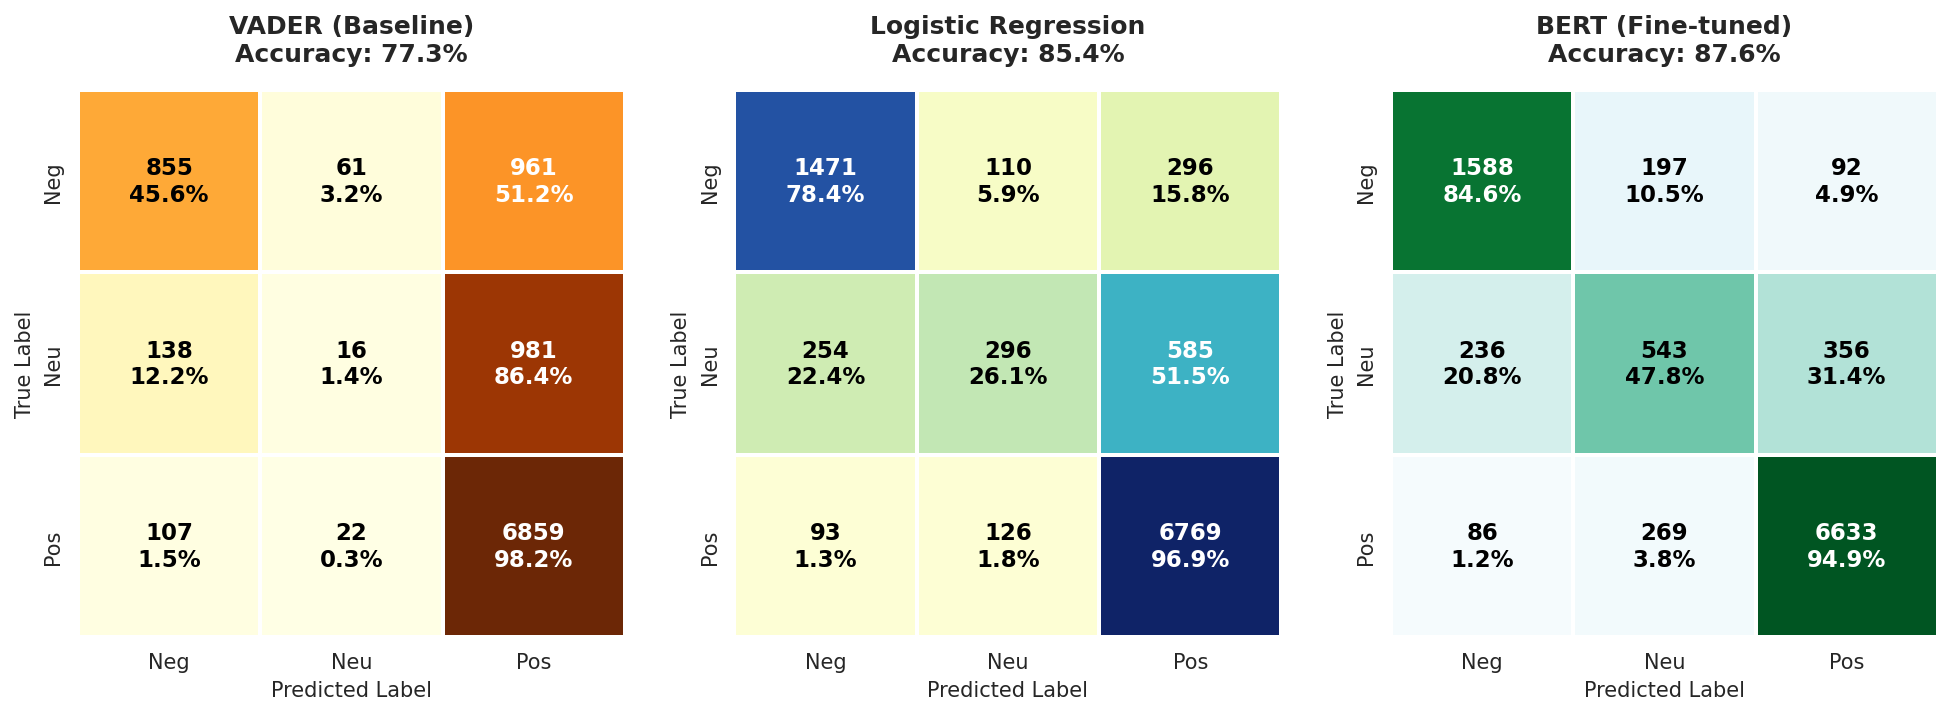

In [35]:
# 1. Rebuild test set
_, X_test_raw, _, y_test_raw = train_test_split(
    df_reviews['text'],
    df_reviews['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_reviews['sentiment']
)

_, X_test_clean, _, _ = train_test_split(
    df_reviews['clean_text'],
    df_reviews['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df_reviews['sentiment']
)

# 2. VADER predictions
print("Getting VADER predictions...")

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()


vader_preds = X_test_raw.apply(vader_predict).values
y_test_vals = y_test_raw.values

# 3. Logistic Regression predictions
print("Getting LR predictions...")

X_test_tfidf = tfidf.transform(X_test_clean)
lr_preds = lr_model.predict(X_test_tfidf)

# 4. BERT predictions

print("Getting BERT predictions...")

label_names = ['negative', 'neutral', 'positive']

bert_preds_named = [label_names[p] for p in preds]
bert_labels_named = [label_names[l] for l in labels]


# 5. Plot confusion matrices
sns.set_style("white")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))


model_data = [
    ('VADER (Baseline)', vader_preds, y_test_vals, 'YlOrBr'),
    ('Logistic Regression', lr_preds, y_test_vals, 'YlGnBu'),
    ('BERT (Fine-tuned)', bert_preds_named, bert_labels_named, 'BuGn')
]

class_labels = ['negative', 'neutral', 'positive']


for ax, (title, pred, true, cmap) in zip(axes, model_data):

    cm = confusion_matrix(true, pred, labels=class_labels)

    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    # create annotation labels with count + %
    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i,j]}\n{cm_pct[i,j]:.1f}%'

    heatmap = sns.heatmap(
        cm_pct,
        annot=annot,
        fmt='',
        cmap=cmap,
        linewidths=1,
        linecolor='white',
        square=True,
        cbar=False,
        xticklabels=['Neg', 'Neu', 'Pos'],
        yticklabels=['Neg', 'Neu', 'Pos'],
        vmin=0,
        vmax=100,
        ax=ax,
        annot_kws={
            'fontsize': 11,
            'fontweight': 'bold'
        }
    )

    threshold = 50

    for text, value in zip(ax.texts, cm_pct.flatten()):
        text.set_color('white' if value > threshold else 'black')

    # accuracy
    accuracy = np.trace(cm) / np.sum(cm) * 100

    ax.set_title(
        f'{title}\nAccuracy: {accuracy:.1f}%',
        fontsize=12,
        fontweight='bold',
        pad=14
    )

    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)


plt.show()


In [36]:
# McNemar's test, BERT vs VADER and BERT vs Logistic Regression

def mcnemar_compare(preds_a, preds_b, y_true, name_a, name_b):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    n11 = np.sum(correct_a & correct_b)
    n10 = np.sum(correct_a & ~correct_b)
    n01 = np.sum(~correct_a & correct_b)
    n00 = np.sum(~correct_a & ~correct_b)
    table = [[n11, n10], [n01, n00]]
    result = mcnemar(table, exact=False, correction=True)
    print(f"\n=== McNemar's test: {name_a} vs {name_b} ===")
    print(f"  {name_a} correct / {name_b} wrong: {n10}")
    print(f"  {name_b} correct / {name_a} wrong: {n01}")
    print(f"  statistic = {result.statistic:.4f}, p-value = {result.pvalue}")
    if result.pvalue < 0.05:
        winner = name_a if n10 > n01 else name_b
        print(f"  --> Statistically significant difference (p < 0.05). {winner} performs better.")
    else:
        print("  --> No statistically significant difference (p >= 0.05).")
    return result

y_true_arr = np.array(y_test_vals)
bert_arr = np.array(bert_preds_named)
vader_arr = np.array(vader_preds)
lr_arr = np.array(lr_preds)

res_bert_vader = mcnemar_compare(bert_arr, vader_arr, y_true_arr, "BERT", "VADER")
res_bert_lr = mcnemar_compare(bert_arr, lr_arr, y_true_arr, "BERT", "Logistic Regression")



=== McNemar's test: BERT vs VADER ===
  BERT correct / VADER wrong: 1432
  VADER correct / BERT wrong: 398
  statistic = 583.1087, p-value = 7.904399931939894e-129
  --> Statistically significant difference (p < 0.05). BERT performs better.

=== McNemar's test: BERT vs Logistic Regression ===
  BERT correct / Logistic Regression wrong: 695
  Logistic Regression correct / BERT wrong: 467
  statistic = 44.3451, p-value = 2.7530097070067405e-11
  --> Statistically significant difference (p < 0.05). BERT performs better.


In [37]:
print("\n=== ABLATION: Frozen BERT embeddings + Logistic Regression head ===")
print("(isolates the contribution of fine-tuning vs. using BERT purely as a feature extractor)")

bert_base = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_base.eval()

def get_cls_embedding(texts, batch_size=32, max_length=128):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size].tolist()
            enc = tokenizer(batch, padding=True, truncation=True,
                             max_length=max_length, return_tensors='pt').to(device)
            out = bert_base(**enc)
            cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)
    return np.vstack(embeddings)

# Re-use the same train/test split already created for BERT
X_train_emb = get_cls_embedding(X_train.reset_index(drop=True))
X_test_emb  = get_cls_embedding(X_test_raw.reset_index(drop=True))


frozen_clf = LogisticRegression(max_iter=1000, random_state=42)
frozen_clf.fit(X_train_emb, y_train)
frozen_preds = frozen_clf.predict(X_test_emb)

# Convert numerical predictions back to string labels for classification_report
# label_names is defined in a previous cell as ['negative', 'neutral', 'positive']
frozen_preds_named = [label_names[p] for p in frozen_preds]

print(classification_report(y_test_vals, frozen_preds_named))
frozen_acc = (frozen_preds_named == y_test_vals).mean()
print(f"Frozen-BERT + LR accuracy: {frozen_acc:.4f}  (fine-tuned BERT: {(bert_arr==y_true_arr).mean():.4f})")


=== ABLATION: Frozen BERT embeddings + Logistic Regression head ===
(isolates the contribution of fine-tuning vs. using BERT purely as a feature extractor)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

    negative       0.74      0.77      0.76      1877
     neutral       0.43      0.21      0.29      1135
    positive       0.88      0.94      0.91      6988

    accuracy                           0.83     10000
   macro avg       0.68      0.64      0.65     10000
weighted avg       0.81      0.83      0.81     10000

Frozen-BERT + LR accuracy: 0.8300  (fine-tuned BERT: 0.8764)


In [38]:
models = {
    "VADER": vader_preds,
    "Logistic Regression": lr_preds,
    "Fine-tuned BERT": bert_preds_named,
    "Frozen-BERT": frozen_preds_named
}

results = []

for name, preds in models.items():
    acc = accuracy_score(y_test_vals, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_vals,
        preds,
        average="weighted"
    )

    results.append([
        name,
        round(acc, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ])

metrics_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(metrics_df)

                 Model  Accuracy  Precision  Recall      F1
0                VADER    0.7730     0.7088  0.7730  0.7179
1  Logistic Regression    0.8536     0.8333  0.8536  0.8360
2      Fine-tuned BERT    0.8764     0.8717  0.8764  0.8738
3          Frozen-BERT    0.8300     0.8053  0.8300  0.8130


In [39]:
def wilson_ci(p, n, z=1.96):
    if p is None or n is None or n <= 0:
        return None, None
    p, n = float(p), float(n)
    denom   = 1 + z**2 / n
    centre  = (p + z**2 / (2*n)) / denom
    margin  = (z * (p*(1-p)/n + z**2/(4*n**2))**0.5) / denom
    return max(0.0, centre - margin), min(1.0, centre + margin)

test_n = len(y_test_vals)

ci_results = {}
for model_name, acc in [('VADER', v_acc), ('Logistic Regression', lr_acc), ('BERT', b_acc), ('Frozen-BERT + LR', frozen_acc)]:
    lo, hi = wilson_ci(acc, test_n)
    ci_results[model_name] = {'acc': acc, 'lo': lo, 'hi': hi}

print(f"Test set size: {test_n:,} samples  |  95% Wilson CI")
print(f"{'Model':<22} {'Accuracy':>9} {'95% CI':>20}")
print("-" * 55)
for m, v in ci_results.items():
    ci_str = f"[{v['lo']*100:.1f}% – {v['hi']*100:.1f}%]" if v['lo'] else "N/A"
    print(f"{m:<22} {v['acc']*100:>8.1f}%  {ci_str:>20}")

Test set size: 10,000 samples  |  95% Wilson CI
Model                   Accuracy               95% CI
-------------------------------------------------------
VADER                      77.3%       [76.5% – 78.1%]
Logistic Regression        85.4%       [84.7% – 86.0%]
BERT                       87.6%       [87.0% – 88.3%]
Frozen-BERT + LR           83.0%       [82.3% – 83.7%]


## Error Analysis

In [40]:
# ERROR ANALYSIS

X_test_text = X_test_raw.reset_index(drop=True)
y_true      = np.array(y_test_vals)
bert_pred   = np.array(bert_preds_named)

error_df = pd.DataFrame({
    'text':      X_test_text,
    'true':      y_true,
    'bert_pred': bert_pred,
    'vader_pred': np.array(vader_preds),
    'lr_pred':    np.array(lr_preds),
})
error_df['bert_correct'] = error_df['true'] == error_df['bert_pred']
error_df['text_length']  = error_df['text'].str.len()


In [41]:
# 1. ERROR BREAKDOWN BY TRUE CLASS x PREDICTED CLASS
print("=== BERT ERROR BREAKDOWN (true class -> predicted class) ===\n")
errors_only = error_df[~error_df['bert_correct']]
error_pivot = errors_only.groupby(['true', 'bert_pred']).size().unstack(fill_value=0)
print(error_pivot)
print(f"\nTotal misclassified: {len(errors_only)} / {len(error_df)} ({len(errors_only)/len(error_df)*100:.1f}%)")

# Specifically quantify the dominant error pattern
print("\nDominant error patterns (as % of ALL errors, not % of that true class):")
total_errors = len(errors_only)
for true_c in ['negative', 'neutral', 'positive']:
    for pred_c in ['negative', 'neutral', 'positive']:
        if true_c == pred_c:
            continue
        n = len(errors_only[(errors_only['true']==true_c) & (errors_only['bert_pred']==pred_c)])
        if n > 0:
            print(f"  True={true_c:<9} Pred={pred_c:<9}  n={n:<4}  ({n/total_errors*100:.1f}% of all errors)")

# % OF THAT TRUE CLASS - how often each class gets misclassified into each wrong bucket
print("Dominant error patterns (% of all errors  |  % of that true class):")
true_class_counts = error_df['true'].value_counts()
total_errors = len(errors_only)

rows = []
for true_c in ['negative', 'neutral', 'positive']:
    for pred_c in ['negative', 'neutral', 'positive']:
        if true_c == pred_c:
            continue
        n = len(errors_only[(errors_only['true']==true_c) & (errors_only['bert_pred']==pred_c)])
        if n > 0:
            pct_all_errors   = n / total_errors * 100
            pct_true_class   = n / true_class_counts[true_c] * 100
            rows.append((true_c, pred_c, n, pct_all_errors, pct_true_class))

rows.sort(key=lambda x: x[2], reverse=True)
print(f"  {'True':<10} {'Predicted':<10} {'Count':>6}  {'% all errors':>13}  {'% true class':>13}")
print("  " + "-"*58)
for true_c, pred_c, n, pct_all, pct_true in rows:
    pattern = f"{true_c.capitalize()} -> {pred_c.capitalize()}"
    print(f"  {pattern:<22} {n:>5}  {pct_all:>12.1f}%  {pct_true:>12.1f}%")

# Summary: recall per class
print("Recall per class (= 1 - error rate within that class):")
for cls in ['negative', 'neutral', 'positive']:
    total_cls = true_class_counts[cls]
    correct_cls = len(error_df[(error_df['true']==cls) & error_df['bert_correct']])
    recall = correct_cls / total_cls * 100
    print(f"  {cls.capitalize():<12}  {correct_cls:>5} / {total_cls:<5}  recall = {recall:.1f}%")


=== BERT ERROR BREAKDOWN (true class -> predicted class) ===

bert_pred  negative  neutral  positive
true                                  
negative          0      197        92
neutral         236        0       356
positive         86      269         0

Total misclassified: 1236 / 10000 (12.4%)

Dominant error patterns (as % of ALL errors, not % of that true class):
  True=negative  Pred=neutral    n=197   (15.9% of all errors)
  True=negative  Pred=positive   n=92    (7.4% of all errors)
  True=neutral   Pred=negative   n=236   (19.1% of all errors)
  True=neutral   Pred=positive   n=356   (28.8% of all errors)
  True=positive  Pred=negative   n=86    (7.0% of all errors)
  True=positive  Pred=neutral    n=269   (21.8% of all errors)
Dominant error patterns (% of all errors  |  % of that true class):
  True       Predicted   Count   % all errors   % true class
  ----------------------------------------------------------
  Neutral -> Positive      356          28.8%          31.4%


In [42]:
# 2. DOES REVIEW LENGTH PREDICT ERROR?

len_correct = error_df.loc[error_df['bert_correct'], 'text_length']
len_incorrect = error_df.loc[~error_df['bert_correct'], 'text_length']

print(f"\n=== TEXT LENGTH: correct vs incorrect predictions ===")
print(f"Correct predictions   - mean length: {len_correct.mean():.0f} chars (n={len(len_correct)})")
print(f"Incorrect predictions - mean length: {len_incorrect.mean():.0f} chars (n={len(len_incorrect)})")

t_stat, p_val = stats.ttest_ind(len_correct, len_incorrect, equal_var=False)
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.4f}")
if p_val < 0.05:
    direction = "longer" if len_incorrect.mean() > len_correct.mean() else "shorter"
    print(f"--> Misclassified reviews are statistically significantly {direction} on average (p<0.05).")
else:
    print("--> No statistically significant length difference between correct and incorrect predictions (p>=0.05).")


=== TEXT LENGTH: correct vs incorrect predictions ===
Correct predictions   - mean length: 521 chars (n=8764)
Incorrect predictions - mean length: 758 chars (n=1236)
Welch's t-test: t=-12.193, p=0.0000
--> Misclassified reviews are statistically significantly longer on average (p<0.05).


In [43]:
def mean_token_count(texts, tokenizer, sample_n=500, seed=42):
    sample = texts.sample(n=min(sample_n, len(texts)), random_state=seed)
    lengths = sample.apply(lambda t: len(tokenizer.encode(t, add_special_tokens=True)))
    return lengths.mean()

correct_texts   = error_df.loc[error_df['bert_correct'], 'text']
incorrect_texts = error_df.loc[~error_df['bert_correct'], 'text']

mean_tokens_correct   = mean_token_count(correct_texts, tokenizer)
mean_tokens_incorrect = mean_token_count(incorrect_texts, tokenizer)

mean_chars_correct   = correct_texts.str.len().mean()
mean_chars_incorrect = incorrect_texts.str.len().mean()

chars_per_token_correct   = mean_chars_correct / mean_tokens_correct
chars_per_token_incorrect = mean_chars_incorrect / mean_tokens_incorrect
chars_per_token_overall   = (chars_per_token_correct + chars_per_token_incorrect) / 2

print(f"Correctly classified - mean chars: {mean_chars_correct:.0f}, mean tokens: {mean_tokens_correct:.1f}, chars/token: {chars_per_token_correct:.2f}")
print(f"Misclassified - mean chars: {mean_chars_incorrect:.0f}, mean tokens: {mean_tokens_incorrect:.1f}, chars/token: {chars_per_token_incorrect:.2f}")
print(f"Approx. overall chars/token ratio: {chars_per_token_overall:.2f}")
print(f"Correctly classified reviews (~{mean_chars_correct:.0f} chars) correspond to ~{mean_chars_correct / chars_per_token_overall:.0f} tokens")
print(f"Misclassified reviews (~{mean_chars_incorrect:.0f} chars) correspond to ~{mean_chars_incorrect / chars_per_token_overall:.0f} tokens")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (726 > 512). Running this sequence through the model will result in indexing errors


Correctly classified - mean chars: 521, mean tokens: 126.5, chars/token: 4.12
Misclassified - mean chars: 758, mean tokens: 180.0, chars/token: 4.21
Approx. overall chars/token ratio: 4.17
Correctly classified reviews (~521 chars) correspond to ~125 tokens
Misclassified reviews (~758 chars) correspond to ~182 tokens


In [44]:
# 3. ALL THREE MODELS WRONG AT ONCE (the hardest cases) vs ONLY BERT WRONG (cases where BERT specifically struggles)

error_df['vader_correct'] = error_df['true'] == error_df['vader_pred']
error_df['lr_correct'] = error_df['true'] == error_df['lr_pred']

all_three_wrong = error_df[~error_df['bert_correct'] & ~error_df['vader_correct'] & ~error_df['lr_correct']]
only_bert_wrong = error_df[~error_df['bert_correct'] & error_df['vader_correct'] & error_df['lr_correct']]

print(f"\n=== AGREEMENT ACROSS MODELS ON ERRORS ===")
print(f"Reviews ALL THREE models got wrong: {len(all_three_wrong)} ({len(all_three_wrong)/len(error_df)*100:.2f}% of test set)")
print(f"Reviews ONLY BERT got wrong (others right): {len(only_bert_wrong)} ({len(only_bert_wrong)/len(error_df)*100:.2f}% of test set)")


=== AGREEMENT ACROSS MODELS ON ERRORS ===
Reviews ALL THREE models got wrong: 640 (6.40% of test set)
Reviews ONLY BERT got wrong (others right): 269 (2.69% of test set)


In [45]:
# 4. QUALITATIVE INSPECTION: sample actual misclassified neutral reviews
print("\n=== SAMPLE MISCLASSIFIED NEUTRAL REVIEWS (true=neutral, BERT predicted positive) ===")
neutral_to_pos = error_df[(error_df['true']=='neutral') & (error_df['bert_pred']=='positive')]
sample_n = min(5, len(neutral_to_pos))
for _, row in neutral_to_pos.sample(sample_n, random_state=42).iterrows():
    print(f"\n  [True: neutral | Predicted: positive]")
    print(f"  {row['text'][:220]}...")

print(f"\n\nTotal true-neutral reviews predicted positive: {len(neutral_to_pos)} "
      f"({len(neutral_to_pos)/len(error_df[error_df['true']=='neutral'])*100:.1f}% of all true-neutral test reviews)")


=== SAMPLE MISCLASSIFIED NEUTRAL REVIEWS (true=neutral, BERT predicted positive) ===

  [True: neutral | Predicted: positive]
  I was excited when IHOP finally opened in Edmonton, and I was finally able to go eat there this past weekend.  I was often scared off of going because of stories of long wait times, but we went at noon on a Sunday and it...

  [True: neutral | Predicted: positive]
  This is tricky because I had a pretty lame experience AT Deluxe, but my haircut turns out to be awesome.

So...

I had to wait half an hour for my appt. to start, and I had a busy day. No one was apologetic or attentive ...

  [True: neutral | Predicted: positive]
  This was a fun place with friendly and fun bartenders.  The food was pretty good too....

  [True: neutral | Predicted: positive]
  Bagels are okay a bit expensive but the sandwiches choices are really good!! Sure wish they had gluten free...

  [True: neutral | Predicted: positive]
  For a little place it was sure busy for a Thursday 

# Topic Modelling

## LDA

In [46]:
# Tokenise clean text into lists of words (LDA needs this format)
print("Preparing texts for LDA")
tokenised_texts = [text.split() for text in df_reviews['clean_text']]

# Build dictionary and corpus
dictionary = corpora.Dictionary(tokenised_texts)

# Filter out very rare and very common words
dictionary.filter_extremes(no_below=10, no_above=0.5)

# Convert to bag-of-words format
corpus = [dictionary.doc2bow(text) for text in tokenised_texts]

print(f"Dictionary size: {len(dictionary):,} unique words")
print(f"Corpus size: {len(corpus):,} documents")

Preparing texts for LDA
Dictionary size: 9,740 unique words
Corpus size: 50,000 documents


In [47]:
# BASELINE - 10 topics, exploratory run before grid search
print("Training LDA model")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("LDA model trained!")

# Print the topics
print("\n=== Initial Baseline TOPICS ===")
for idx, topic in lda_model.print_topics(num_words=8):
    words = [word.split('*')[1].replace('"', '').strip()
             for word in topic.split('+')]
    print(f"\nTopic {idx + 1}: {' | '.join(words)}")


coherence_model = CoherenceModel(
    model=lda_model,
    texts=tokenised_texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score_baseline = coherence_model.get_coherence()
print(f"Initial Baseline C_V Score: {coherence_score_baseline:.4f}")

Training LDA model
LDA model trained!

=== Initial Baseline TOPICS ===

Topic 1: place | great | food | good | really | service | go | time

Topic 2: chicken | good | sauce | cheese | burger | ordered | salad | fry

Topic 3: room | hotel | stay | clean | nice | staff | bed | stayed

Topic 4: car | work | day | hair | time | year | job | customer

Topic 5: coffee | cream | ice | cake | chocolate | tea | donut | flavor

Topic 6: breakfast | restaurant | shrimp | delicious | dinner | meal | service | wine

Topic 7: u | time | one | would | back | order | didnt | got

Topic 8: bar | music | night | game | drink | fun | event | bartender

Topic 9: pizza | store | shop | buy | item | crust | dog | find

Topic 10: roll | sushi | thai | pho | spring | santa | beach | fish
Initial Baseline C_V Score: 0.4815


Finding optimal number of topics...
  Topics: 5 | Coherence: 0.4905
  Topics: 7 | Coherence: 0.4953
  Topics: 9 | Coherence: 0.4948
  Topics: 11 | Coherence: 0.5427
  Topics: 13 | Coherence: 0.5356
  Topics: 15 | Coherence: 0.5247
  Topics: 17 | Coherence: 0.5133
  Topics: 19 | Coherence: 0.5070


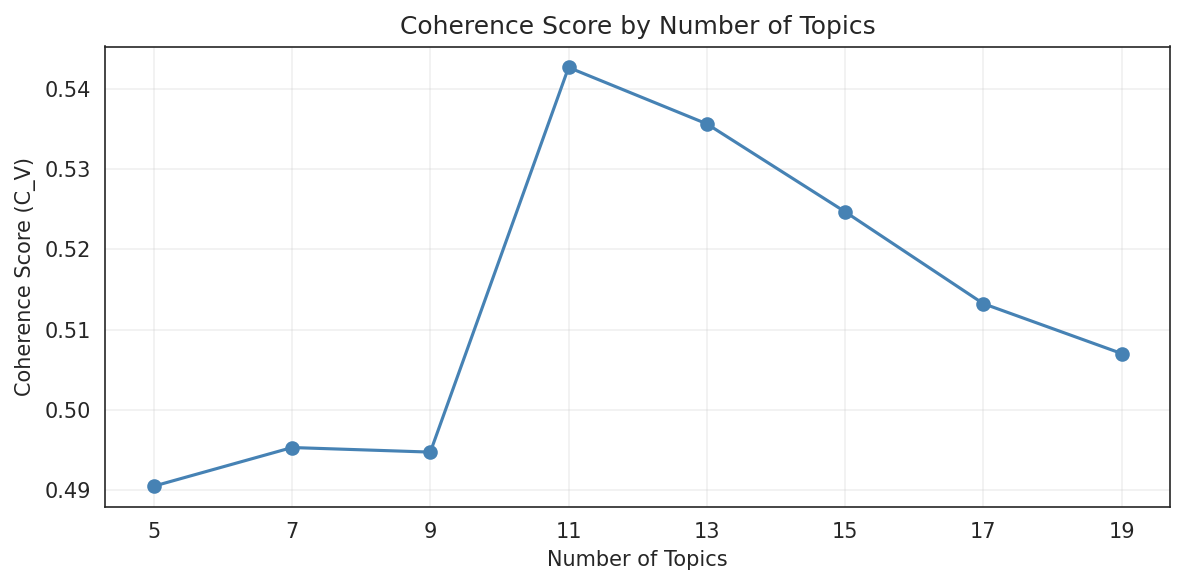


Best number of topics: 11 (score: 0.5427)


In [48]:
# Test different number of topics to find the best coherence score
print("Finding optimal number of topics...")

coherence_scores = []
topic_range = range(5, 20, 2)

for num_topics in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    coherence_model = CoherenceModel(
        model=model,
        texts=tokenised_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"  Topics: {num_topics} | Coherence: {score:.4f}")

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(list(topic_range), coherence_scores, marker='o', color='steelblue')
plt.title('Coherence Score by Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (C_V)')
plt.xticks(list(topic_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = coherence_scores.index(max(coherence_scores))
best_num = list(topic_range)[best_idx]
coherence_score_optimal = coherence_scores[best_idx]
print(f"\nBest number of topics: {best_num} (score: {coherence_score_optimal:.4f})")

In [49]:
# Custom stopwords
# Add domain-specific stopwords that are too common to be meaningful
custom_stopwords = {
    'place', 'good', 'great', 'really', 'one', 'get', 'go',
    'got', 'would', 'also', 'u', 'back', 'time', 'like',
    'food', 'restaurant', 'well', 'even', 'make', 'said',
    'order', 'ordered', 'came', 'come', 'went', 'going',
    'told', 'asked', 'took', 'taken', 'want', 'wanted'
}

# Re-tokenise with custom stopwords removed
print("Re-cleaning texts with custom stopwords...")
tokenised_texts_v2 = [
    [word for word in text.split() if word not in custom_stopwords]
    for text in df_reviews['clean_text']
]

# Rebuild dictionary and corpus
dictionary_v2 = corpora.Dictionary(tokenised_texts_v2)
dictionary_v2.filter_extremes(no_below=15, no_above=0.45)
corpus_v2 = [dictionary_v2.doc2bow(text) for text in tokenised_texts_v2]

print(f"New dictionary size: {len(dictionary_v2):,} unique words")

# Retrain with 11 topics
print("\nRetraining LDA v2...")
lda_v2 = LdaModel(
    corpus=corpus_v2,
    id2word=dictionary_v2,
    num_topics=11,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

# Check coherence
coherence_v2 = CoherenceModel(
    model=lda_v2,
    texts=tokenised_texts_v2,
    dictionary=dictionary_v2,
    coherence='c_v'
).get_coherence()

print(f"\n=== Custom stopwords COHERENCE SCORE ===")
print(f"New score: {coherence_v2:.4f}")

# Show topics
print("\n=== Custom stopwords TOPICS ===")
for idx, topic in lda_v2.print_topics(num_words=8):
    words = [word.split('*')[1].replace('"', '').strip()
             for word in topic.split('+')]
    print(f"\nTopic {idx + 1}: {' | '.join(words)}")

Re-cleaning texts with custom stopwords...
New dictionary size: 7,812 unique words

Retraining LDA v2...

=== Custom stopwords COHERENCE SCORE ===
New score: 0.5361

=== Custom stopwords TOPICS ===

Topic 1: pizza | burger | fry | ice | cheese | cream | wing | sandwich

Topic 2: dont | didnt | im | could | first | people | service | much

Topic 3: hair | dog | nail | cut | work | salon | job | class

Topic 4: bar | drink | beer | night | wine | selection | sushi | music

Topic 5: breakfast | egg | cake | brunch | chocolate | pancake | coffee | french

Topic 6: service | best | love | friendly | always | staff | definitely | ive

Topic 7: taco | mexican | thai | rice | noodle | bowl | chip | margarita

Topic 8: store | coffee | shop | tea | donut | item | find | buy

Topic 9: car | called | call | customer | phone | work | day | card

Topic 10: chicken | salad | sauce | dish | meal | fried | shrimp | cheese

Topic 11: room | hotel | stay | parking | clean | floor | nice | area


In [50]:
# Try looser dictionary filtering
dictionary_v3 = corpora.Dictionary(tokenised_texts)
dictionary_v3.filter_extremes(no_below=5, no_above=0.4)
corpus_v3 = [dictionary_v3.doc2bow(text) for text in tokenised_texts]

print(f"Dictionary v3 size: {len(dictionary_v3):,} unique words")

# Retrain with 11 topics
print("Retraining LDA v3...")
lda_v3 = LdaModel(
    corpus=corpus_v3,
    id2word=dictionary_v3,
    num_topics=11,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

# Check coherence
coherence_v3 = CoherenceModel(
    model=lda_v3,
    texts=tokenised_texts,
    dictionary=dictionary_v3,
    coherence='c_v'
).get_coherence()

print(f"\n=== Looser filter COHERENCE SCORE ===")
print(f"New score: {coherence_v3:.4f}")

Dictionary v3 size: 14,471 unique words
Retraining LDA v3...

=== Looser filter COHERENCE SCORE ===
New score: 0.5482


In [51]:
# Build bigram and trigram models
print("Building bigrams and trigrams...")
bigram = Phrases(tokenised_texts, min_count=20, threshold=100)
trigram = Phrases(bigram[tokenised_texts], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

# Apply to texts
tokenised_texts_v4 = [trigram_mod[bigram_mod[text]] for text in tokenised_texts]

# Check some examples
print("\n=== EXAMPLE: BIGRAMS/TRIGRAMS FOUND ===")
for text in tokenised_texts_v4[:5]:
    phrases = [word for word in text if '_' in word]
    if phrases:
        print(f"  {phrases}")

# Rebuild dictionary and corpus
dictionary_v4 = corpora.Dictionary(tokenised_texts_v4)
dictionary_v4.filter_extremes(no_below=10, no_above=0.5)
corpus_v4 = [dictionary_v4.doc2bow(text) for text in tokenised_texts_v4]

print(f"\nDictionary v4 size: {len(dictionary_v4):,} unique words")

# Retrain LDA
print("Retraining LDA with bigrams/trigrams...")
lda_v4 = LdaModel(
    corpus=corpus_v4,
    id2word=dictionary_v4,
    num_topics=11,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

# Check coherence
coherence_v4 = CoherenceModel(
    model=lda_v4,
    texts=tokenised_texts_v4,
    dictionary=dictionary_v4,
    coherence='c_v'
).get_coherence()

print(f"\n=== Bigrams test COHERENCE SCORE ===")
print(f"New score: {coherence_v4:.4f}")

# Show topics
print("\n=== Bigrams test TOPICS ===")
for idx, topic in lda_v4.print_topics(num_words=8):
    words = [word.split('*')[1].replace('"', '').strip()
             for word in topic.split('+')]
    print(f"\nTopic {idx + 1}: {' | '.join(words)}")

Building bigrams and trigrams...

=== EXAMPLE: BIGRAMS/TRIGRAMS FOUND ===
  ['spin_class', 'body_cycle', 'top_notch', 'body_cycle', 'smile_face']
  ['grape_leaf']
  ['cheese_curd']

Dictionary v4 size: 10,812 unique words
Retraining LDA with bigrams/trigrams...

=== Bigrams test COHERENCE SCORE ===
New score: 0.5005

=== Bigrams test TOPICS ===

Topic 1: coffee | cake | ice_cream | chocolate | flavor | tea | sweet | donut

Topic 2: hair | appointment | cut | class | tour | salon | nail | massage

Topic 3: table | restaurant | ordered | meal | came | server | dinner | u

Topic 4: store | car | work | shop | new | need | day | buy

Topic 5: bar | lot | beer | place | also | like | little | pretty

Topic 6: room | hotel | sushi | stay | clean | dog | roll | stayed

Topic 7: great | food | place | good | service | best | love | friendly

Topic 8: chicken | good | burger | sauce | sandwich | ordered | salad | cheese

Topic 9: pizza | italian | delivery | crust | cheese | pie | slice | pasta

In [52]:
# FINAL MODEL - 11 topics selected from grid search, passes=15
print("Training LDA model...")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=11,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

print("LDA model trained!")

# Print the topics
print("\n=== FINAL DISCOVERED TOPICS ===")
for idx, topic in lda_model.print_topics(num_words=8):
    words = [word.split('*')[1].replace('"', '').strip()
             for word in topic.split('+')]
    print(f"\nTopic {idx + 1}: {' | '.join(words)}")

Training LDA model...
LDA model trained!

=== FINAL DISCOVERED TOPICS ===

Topic 1: place | great | food | good | service | really | go | best

Topic 2: chicken | pizza | good | sauce | ordered | burger | cheese | salad

Topic 3: room | hotel | stay | clean | nice | bathroom | staff | bed

Topic 4: car | work | hair | day | job | year | called | customer

Topic 5: coffee | cream | ice | cake | chocolate | tea | flavor | donut

Topic 6: wine | shrimp | restaurant | dinner | dish | meal | appetizer | crab

Topic 7: time | u | would | one | back | got | didnt | order

Topic 8: bar | drink | night | music | bartender | game | seating | outside

Topic 9: store | dog | shop | buy | find | lot | park | item

Topic 10: roll | sushi | thai | soup | rice | noodle | dish | tour

Topic 11: breakfast | egg | brunch | pancake | french | coffee | toast | bacon


In [53]:
# Calculate coherence score
print("Calculating coherence score...")
coherence_model = CoherenceModel(
    model=lda_model,
    texts=tokenised_texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print(f"\n=== FINAL COHERENCE SCORE ===")
print(f"C_V Score: {coherence_score:.4f}")

# Save model
lda_model.save('lda_model_final')
dictionary.save('lda_dictionary_final.gensim')
print("\nLDA model saved!")

Calculating coherence score...

=== FINAL COHERENCE SCORE ===
C_V Score: 0.5573

LDA model saved!


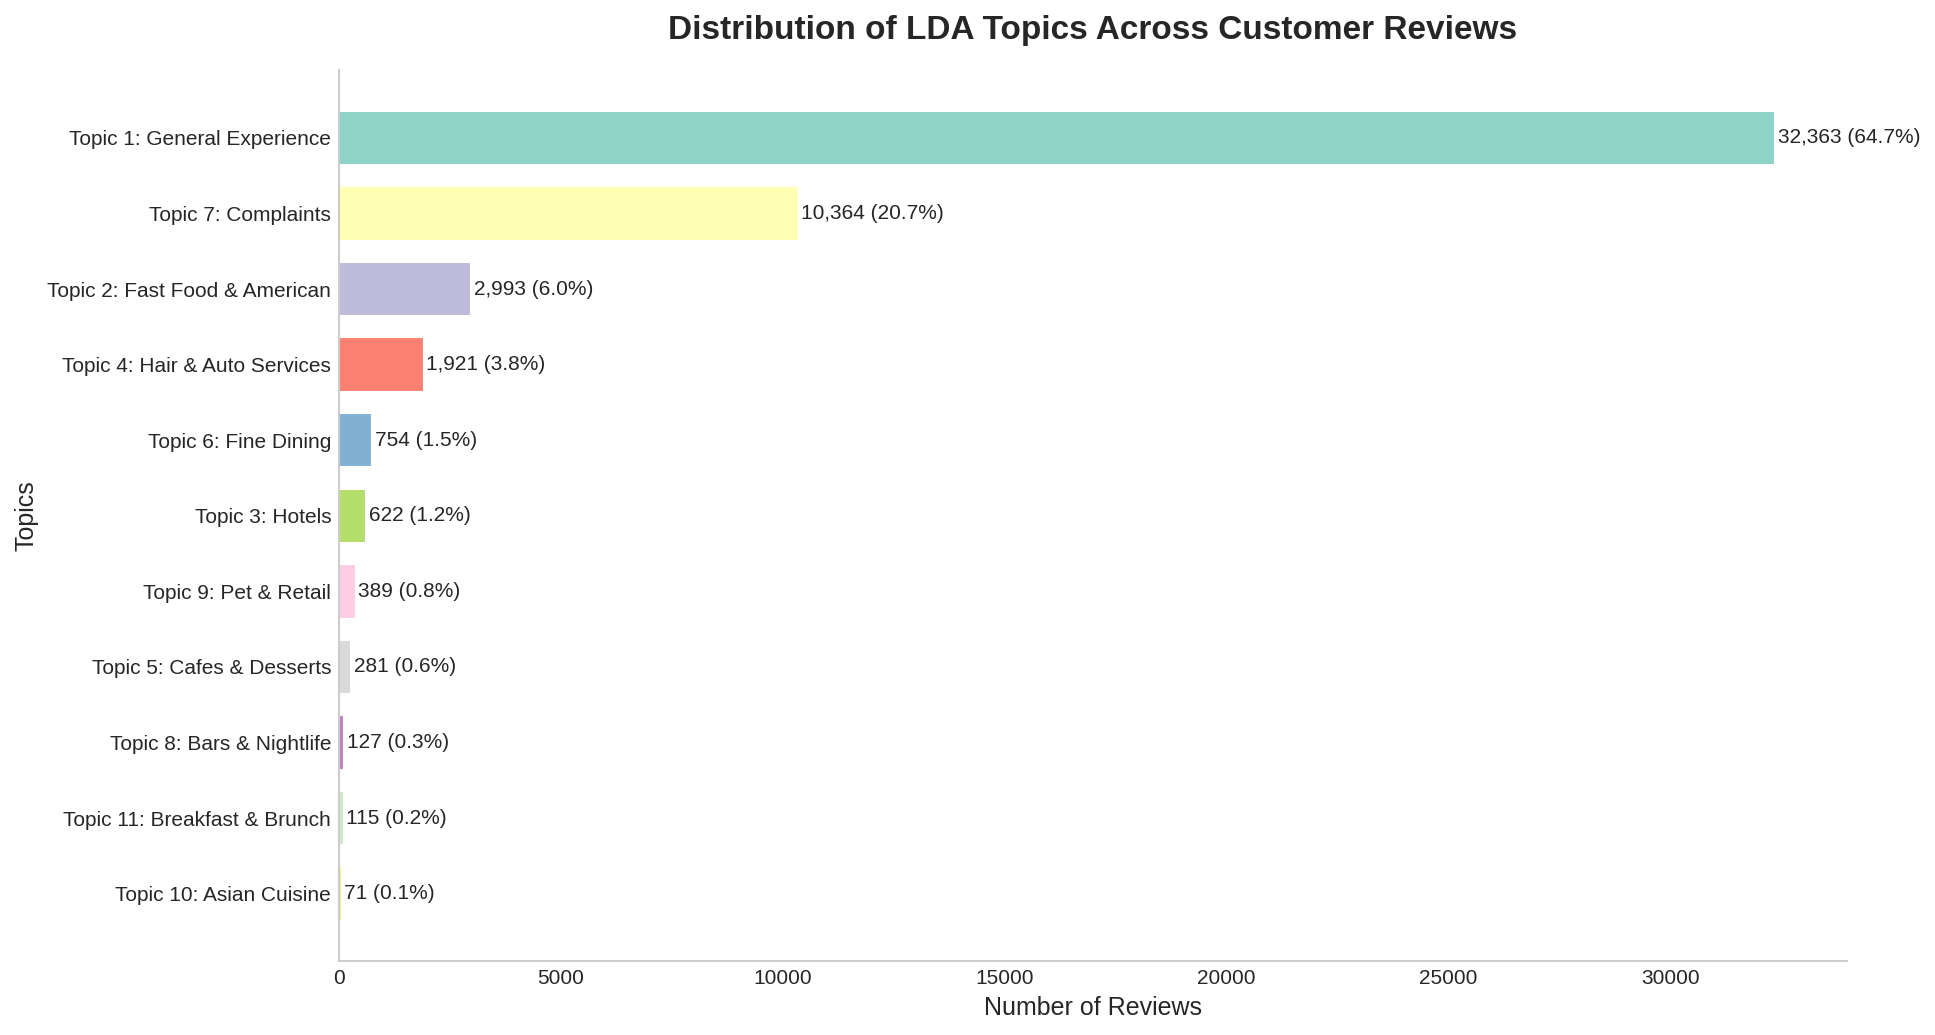

In [54]:
# Topic labels

topic_labels = {
    0: 'General Experience',
    1: 'Fast Food & American',
    2: 'Hotels',
    3: 'Hair & Auto Services',
    4: 'Cafes & Desserts',
    5: 'Fine Dining',
    6: 'Complaints',
    7: 'Bars & Nightlife',
    8: 'Pet & Retail',
    9: 'Asian Cuisine',
    10: 'Breakfast & Brunch'
}


# Function to get the dominant topic for a document
def get_dominant_topic(lda_model, doc_bow):
    topic_distribution = lda_model.get_document_topics(doc_bow)
    if not topic_distribution:
        return -1
    return max(topic_distribution, key=lambda item: item[1])[0]

# Apply to all review
dominant_topics = [
    get_dominant_topic(lda_model, doc)
    for doc in corpus
]

# Add dominant topics to the DataFrame
df_reviews['dominant_topic'] = dominant_topics

# Topic frequency
topic_counts = (
    df_reviews["dominant_topic"]
    .value_counts()
    .sort_values(ascending=False)
)

total = len(df_reviews)

labels = [
    f"Topic {i+1}: {topic_labels[i]}"
    for i in topic_counts.index
]

percentages = (
    topic_counts / total * 100
)

# color palette
topic_colors = plt.cm.Set3(
    np.linspace(0, 1, len(topic_counts))
)

# Plot

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(
    figsize=(13, 7)
)

bars = ax.barh(
    labels,
    topic_counts.values,
    color=topic_colors,
    edgecolor="white",
    height=0.72
)
ax.invert_yaxis()

ax.set_title(
    "Distribution of LDA Topics Across Customer Reviews",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Reviews",
    fontsize=12
)

ax.set_ylabel(
    "Topics",
    fontsize=12
)

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# value labels
for bar, count, pct in zip(
    bars,
    topic_counts.values,
    percentages
):

    ax.text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height()/2,
        f"{count:,} ({pct:.1f}%)",
        va="center",
        fontsize=10
    )

plt.tight_layout()


plt.show()

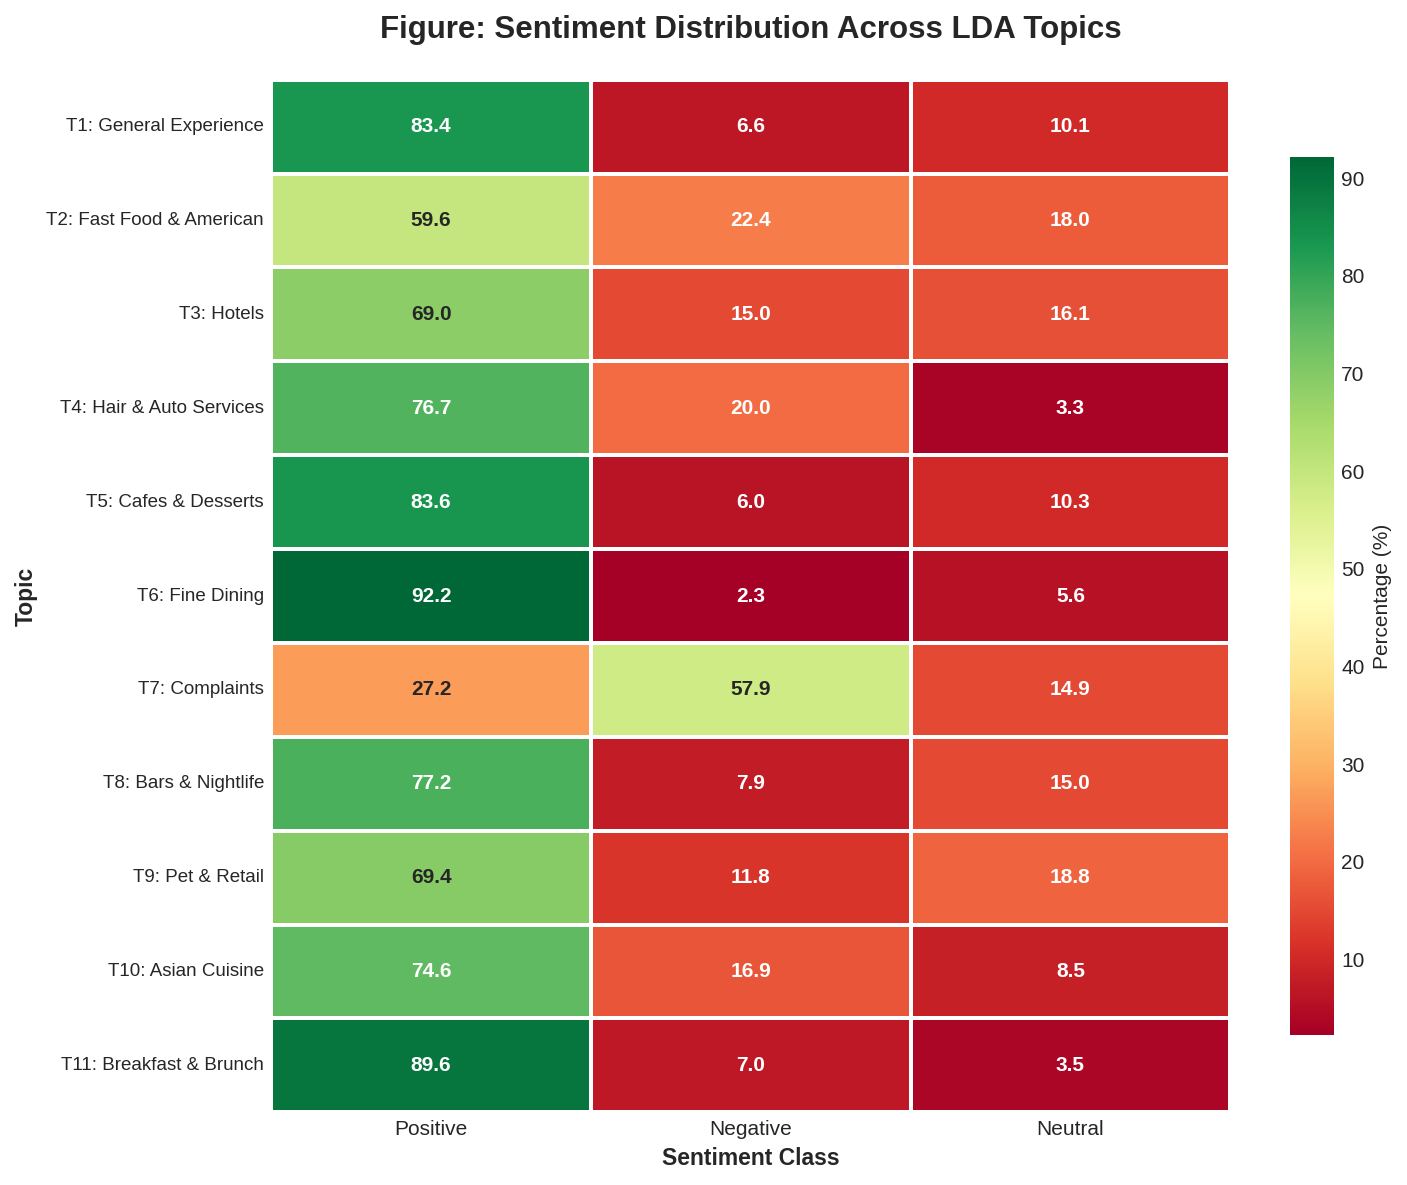

In [55]:
# Sentiment distribution per topic
topic_sentiment = (
    df_reviews
    .groupby(['dominant_topic', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

# Convert to %
topic_sentiment_pct = (
    topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0)* 100
)

# Keep order
topic_sentiment_pct = topic_sentiment_pct.reindex(range(11))

# Rename rows for display
heatmap_data = topic_sentiment_pct.rename(
    index={i: f"T{i+1}: {topic_labels[i]}" for i in range(11)}
)

# Ensure column order
heatmap_data = heatmap_data[['positive', 'negative', 'neutral']]
heatmap_data.columns = ['Positive', 'Negative', 'Neutral']


# Plot
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=1,
    linecolor='white',
    cbar_kws={
        'label': 'Percentage (%)',
        'shrink': 0.85
    },
    annot_kws={
        'fontsize': 10,
        'fontweight': 'bold'
    }
)

# Titles
plt.title(
    'Figure: Sentiment Distribution Across LDA Topics',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Sentiment Class',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Topic',
    fontsize=11,
    fontweight='bold'
)

# Tick formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

plt.tight_layout()

plt.show()

In [56]:
# Save updated CSV with dominant_topic
df_reviews.to_csv('yelp_reviews_cleaned.csv', index=False)
print(f"dominant_topic range: {df_reviews['dominant_topic'].min()} to {df_reviews['dominant_topic'].max()}")

dominant_topic range: 0 to 10


In [57]:
# Category-Topic Alignment Analysis
# NOTE: expected_mappings below is not an independent ground truth, so the alignment rate is a proxy measure only

print('Loading business metadata...')
business_data = []
with open(business_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # if i >= 100000:
            # break
        business_data.append(json.loads(line))

df_business = pd.DataFrame(business_data)[['business_id', 'categories']]
df_business = df_business.dropna(subset=['categories'])
print(f'Business data loaded: {len(df_business):,} records')

df_merged = df_reviews.merge(df_business, on='business_id', how='left')
matched_categories = df_merged['categories'].notna().sum()
coverage_pct = matched_categories / len(df_merged) * 100
print(f"Merged: {matched_categories:,} reviews with category data ({coverage_pct:.3f}% coverage)")
df_merged['categories'] = df_merged['categories'].fillna('')

# Including Topic 0 (General Experience) alongside specific topics
expected_mappings = {
    'Restaurants': [0, 1, 5, 6, 9, 10],
    'Food': [0, 1, 5, 9, 10],
    'Hotels': [0, 2],
    'Hair Salons': [0, 3],
    'Auto Repair': [0, 3],
    'Coffee': [0, 4],
    'Desserts': [0, 4],
    'Bars': [0, 7],
    'Nightlife': [0, 7],
    'Pet Services': [0, 8],
    'Shopping': [0, 8],
    'Sushi Bars': [0, 9],
    'Thai': [0, 9],
    'Breakfast & Brunch': [0, 10],
}

print('\n=== Category-Topic Alignment Analysis ===')
print('Checking topic-category alignment...\n')
alignment_results = []

for category, expected_topics in expected_mappings.items():
    cat_mask   = df_merged['categories'].str.contains(category, case=False, na=False)
    cat_reviews = df_merged[cat_mask]
    if len(cat_reviews) < 10:
        continue
    aligned = cat_reviews['dominant_topic'].isin(expected_topics).sum()
    alignment_rate = aligned / len(cat_reviews) * 100
    alignment_results.append({
        'Category': category,
        'Reviews': len(cat_reviews),
        'Expected Topics': str([f'T{t+1}' for t in expected_topics]),
        'Alignment Rate': alignment_rate
    })
    bar = '█' * int(alignment_rate / 5)
    print(f'  {category:<22} {len(cat_reviews):>5} reviews | Alignment: {alignment_rate:>5.1f}%  {bar}')

alignment_df = pd.DataFrame(alignment_results)
avg_alignment = alignment_df['Alignment Rate'].mean()
print(f"\n{'='*60}")
print(f'Average alignment rate: {avg_alignment:.1f}%  researcher-defined alignment measure')
print(f'Categories evaluated:   {len(alignment_df)}')
alignment_df.to_csv('category_topic_alignment.csv', index=False)
print('Results saved to category_topic_alignment.csv')


Loading business metadata...
Business data loaded: 150,243 records
Merged: 49,999 reviews with category data (99.998% coverage)

=== Category-Topic Alignment Analysis ===
Checking topic-category alignment...

  Restaurants            36149 reviews | Alignment:  99.0%  ███████████████████
  Food                   19693 reviews | Alignment:  78.1%  ███████████████
  Hotels                  3009 reviews | Alignment:  68.3%  █████████████
  Hair Salons              798 reviews | Alignment:  80.5%  ████████████████
  Auto Repair              717 reviews | Alignment:  71.1%  ██████████████
  Coffee                  4031 reviews | Alignment:  77.0%  ███████████████
  Desserts                1627 reviews | Alignment:  73.1%  ██████████████
  Bars                   13723 reviews | Alignment:  71.0%  ██████████████
  Nightlife              11582 reviews | Alignment:  69.5%  █████████████
  Pet Services             279 reviews | Alignment:  58.8%  ███████████
  Shopping                3092 review

## BERTopic

In [58]:
# Prepare texts
print("Preparing texts...")
texts = df_reviews['clean_text'].tolist()

# Vectorizer to clean up stopwords
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=10,
    ngram_range=(1, 2)
)

# Initialize BERTopic
print("Initializing BERTopic...")
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=11,
    min_topic_size=50,
    verbose=True,
    calculate_probabilities=False
)

# Fit model
print("Fitting BERTopic on 50,000 reviews...")
topics, probs = topic_model.fit_transform(texts)

print(f"\nBERTopic complete!")
print(f"Number of topics found: {len(set(topics)) - 1}")  # -1 for outlier topic

# Show topics
print("\n=== BERTOPIC TOPICS ===")
topic_info = topic_model.get_topic_info()
print(topic_info[['Topic', 'Count', 'Name']].to_string())

2026-10-10 14:32:47,975 - BERTopic - Embedding - Transforming documents to embeddings.


Preparing texts...
Initializing BERTopic...
Fitting BERTopic on 50,000 reviews...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

2026-10-10 14:33:51,498 - BERTopic - Embedding - Completed ✓
2026-10-10 14:33:51,500 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-10 14:35:34,554 - BERTopic - Dimensionality - Completed ✓
2026-10-10 14:35:34,556 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-10 14:35:46,636 - BERTopic - Cluster - Completed ✓
2026-10-10 14:35:46,637 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-10-10 14:35:53,104 - BERTopic - Representation - Completed ✓
2026-10-10 14:35:53,106 - BERTopic - Topic reduction - Reducing number of topics
2026-10-10 14:35:53,234 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-10 14:36:00,589 - BERTopic - Representation - Completed ✓
2026-10-10 14:36:00,599 - BERTopic - Topic reduction - Reduced number of topics from 78 to 11



BERTopic complete!
Number of topics found: 10

=== BERTOPIC TOPICS ===
    Topic  Count                          Name
0      -1  20662      -1_food_good_place_great
1       0  24289       0_food_place_good_great
2       1   1904        1_cut_class_time_great
3       2   1005       2_car_service_work_time
4       3    493     3_tour_park_history_great
5       4    460  4_store_price_shop_selection
6       5    382   5_office_staff_care_patient
7       6    326         6_dog_care_staff_time
8       7    275    7_day_beautiful_work_event
9       8    130       8_car_clean_machine_dry
10      9     74        9_game_fan_park_philly


In [59]:
# Get top words per topic from BERTopic
print("Extracting BERTopic keywords...")

bertopic_words = []
topic_ids = [t for t in topic_model.get_topic_info()['Topic'] if t != -1]

for topic_id in topic_ids:
    words = [word for word, _ in topic_model.get_topic(topic_id)]
    bertopic_words.append(words)

print(f"Extracted keywords for {len(bertopic_words)} topics")

# Rebuild tokenised texts for coherence calculation
tokenised_texts_bert = [text.split() for text in df_reviews['clean_text']]

# Build dictionary from tokenised texts
bert_dictionary = Dictionary(tokenised_texts_bert)

# Calculate C_V coherence
print("\nCalculating C_V coherence score...")
coherence_model_bert = CoherenceModel(
    topics=bertopic_words,
    texts=tokenised_texts_bert,
    dictionary=bert_dictionary,
    coherence='c_v'
)

bertopic_score = coherence_model_bert.get_coherence()

print(f"\n=== COHERENCE COMPARISON ===")
print(f"BERTopic coherence score: {bertopic_score:.4f}")

Extracting BERTopic keywords...
Extracted keywords for 10 topics

Calculating C_V coherence score...

=== COHERENCE COMPARISON ===
BERTopic coherence score: 0.4144


In [60]:
TOPN = 10

lda_cm = CoherenceModel(model=lda_model,
                        texts=tokenised_texts,
                        dictionary=dictionary,
                        coherence='c_v',
                        topn=TOPN
                        )
print(f"LDA C_V (topn={TOPN}): {lda_cm.get_coherence():.4f}")

bert_topics_n = [ws[:TOPN] for ws in bertopic_words]
absent = [sum(1 for w in ws if w not in bert_dictionary.token2id) for ws in bert_topics_n]
print("BERTopic topic words missing from the coherence dictionary (Gensim silently ignores them):", absent)

bert_cm = CoherenceModel(topics=bert_topics_n,
                         texts=tokenised_texts_bert,
                         dictionary=bert_dictionary,
                         coherence='c_v',
                         topn=TOPN
                         )
print(f"BERTopic C_V (topn={TOPN}): {bert_cm.get_coherence():.4f}")


LDA C_V (topn=10): 0.5921
BERTopic topic words missing from the coherence dictionary (Gensim silently ignores them): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
BERTopic C_V (topn=10): 0.4144


Outlier reviews: 20,662 (41.3%)
Assigned reviews: 29,338 (58.7%)


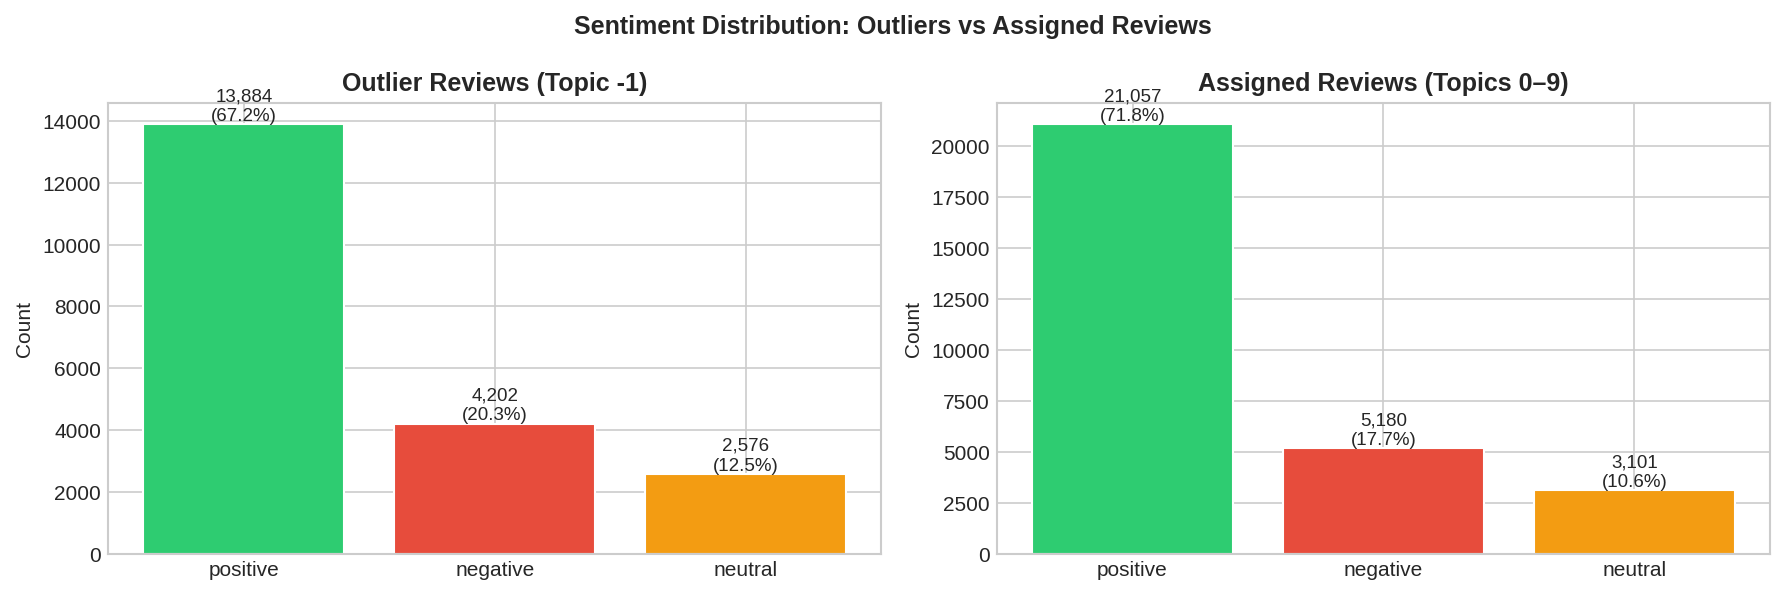

In [61]:
# Analyse BERTopic outlier reviews (Topic -1)

outlier_mask   = np.array(topics) == -1
outlier_texts  = df_reviews['clean_text'][outlier_mask]
non_outlier_texts = df_reviews['clean_text'][~outlier_mask]

print(f'Outlier reviews: {outlier_mask.sum():,} ({outlier_mask.sum()/len(topics)*100:.1f}%)')
print(f'Assigned reviews: {(~outlier_mask).sum():,} ({(~outlier_mask).sum()/len(topics)*100:.1f}%)')

# Sentiment distribution in outliers vs assigned
outlier_df  = df_reviews[outlier_mask].copy()
assigned_df = df_reviews[~outlier_mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, subset, title in [
    (axes[0], outlier_df,  'Outlier Reviews (Topic -1)'),
    (axes[1], assigned_df, 'Assigned Reviews (Topics 0–9)')
]:
    sc = subset['sentiment'].value_counts()
    bars = ax.bar(sc.index, sc.values,
                  color=['#e74c3c' if s=='negative' else '#2ecc71' if s=='positive' else '#f39c12'
                         for s in sc.index])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, sc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}\n({val/len(subset)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
plt.suptitle('Sentiment Distribution: Outliers vs Assigned Reviews', fontweight='bold')
plt.tight_layout()
plt.show()




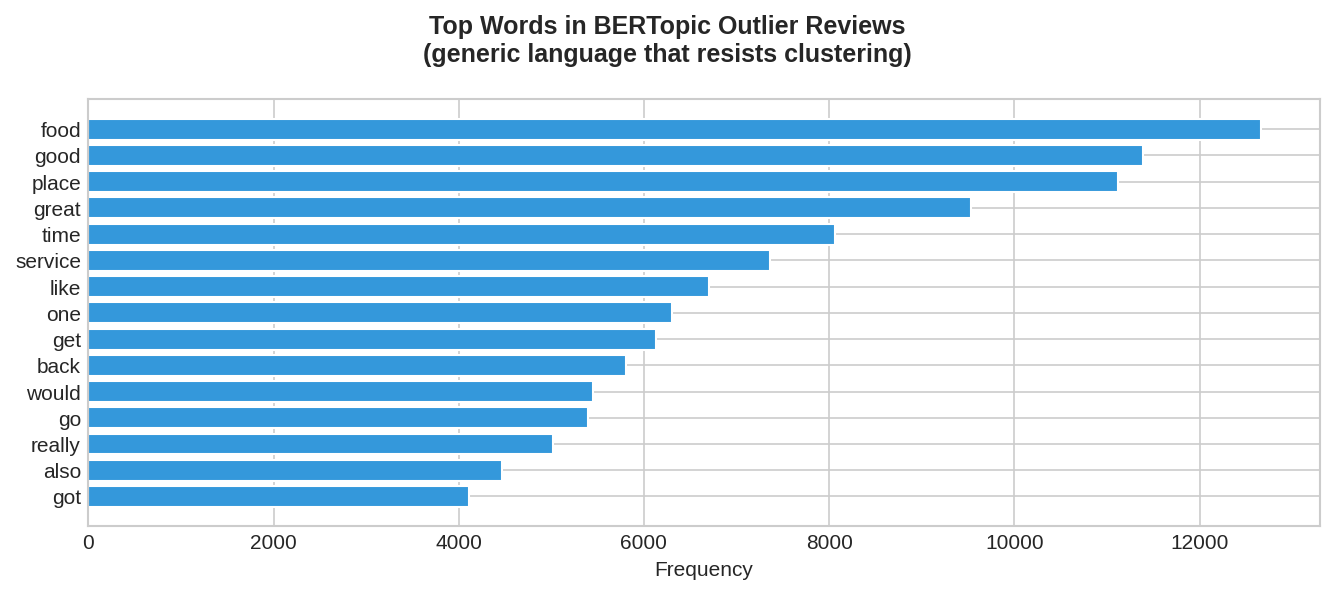


Average length - Outliers: 553 chars | Assigned: 543 chars
Outlier reviews are slightly longer on average; length alone does not explain outlier assignment.


In [62]:
# Top words in outlier reviews
outlier_words = ' '.join(outlier_texts.fillna('')).split()
top_outlier = Counter(outlier_words).most_common(15)
words, counts = zip(*top_outlier)

plt.figure(figsize=(9, 4))
plt.barh(list(reversed(words)), list(reversed(counts)), color='#3498db')
plt.suptitle('Top Words in BERTopic Outlier Reviews\n(generic language that resists clustering)',
          fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

_o, _a = outlier_df['text_length'].mean(), assigned_df['text_length'].mean()
print(f'\nAverage length - Outliers: {_o:.0f} chars | Assigned: {_a:.0f} chars')
print('Outlier reviews are slightly ' + ('longer' if _o > _a else 'shorter') + ' on average; length alone does not explain outlier assignment.')

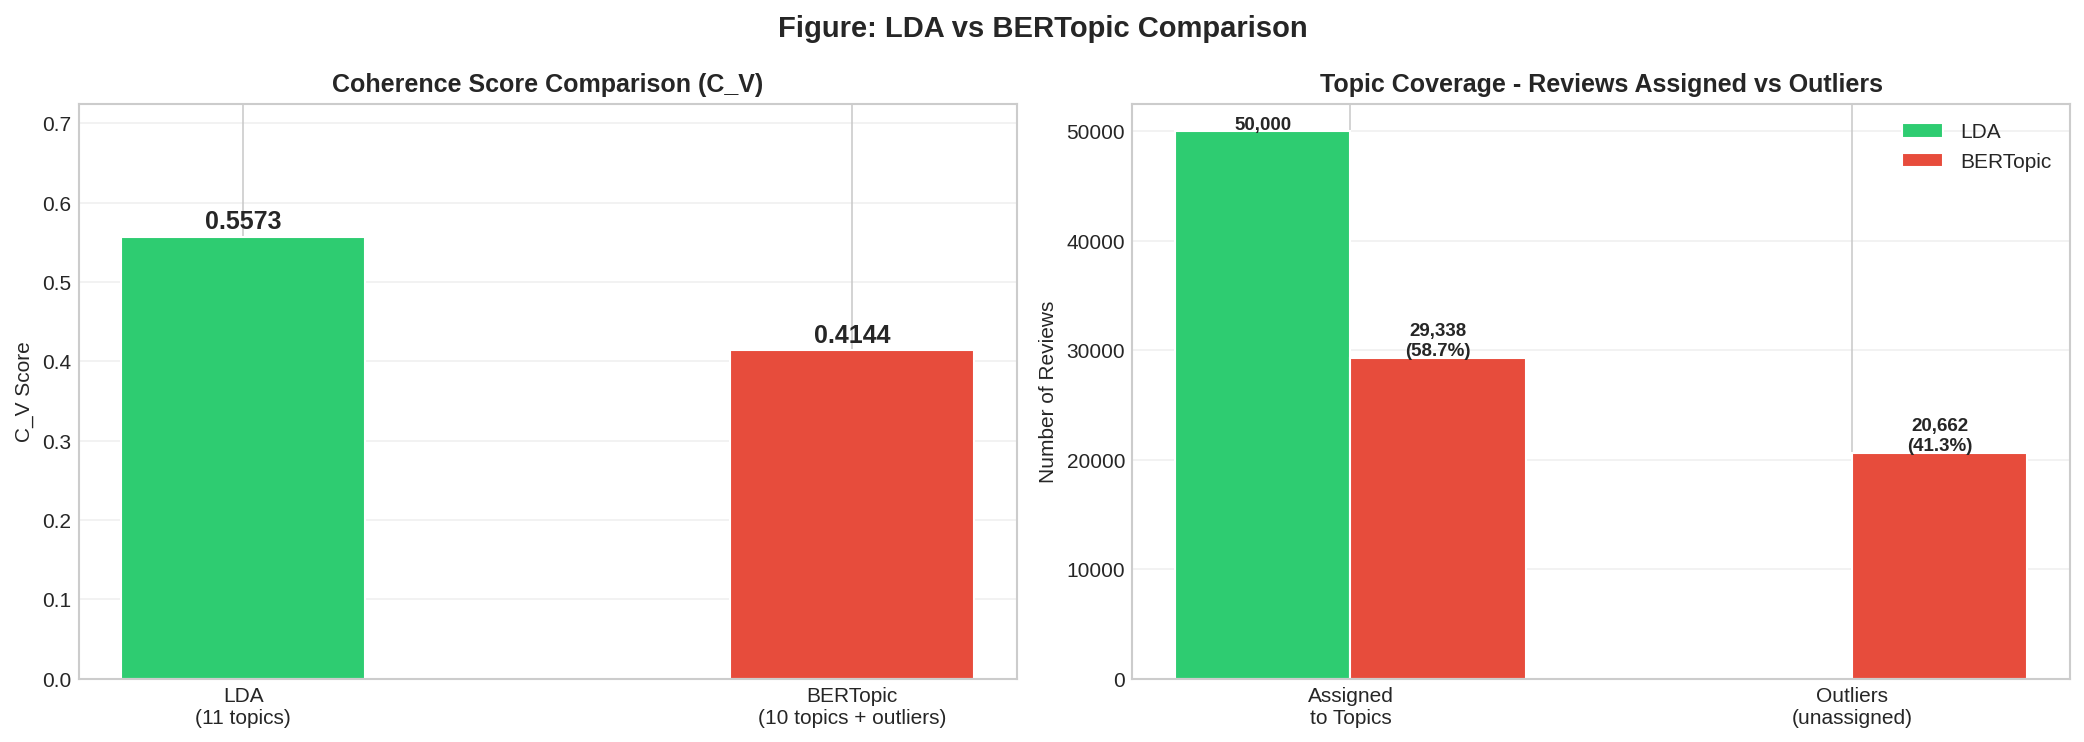

In [63]:
# Comparison visualization

lda_score = coherence_score
bertopic_score_val = bertopic_score

# Coverage (computed from BERTopic topics list)
total_reviews = len(topics)
n_assigned = int(np.sum(np.array(topics) != -1))
n_outlier= int(np.sum(np.array(topics) == -1))
lda_assigned= total_reviews  # LDA assigns every document

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure: LDA vs BERTopic Comparison', fontsize=14, fontweight='bold')

# Coherence comparison bar
models = ['LDA\n(11 topics)', 'BERTopic\n(10 topics + outliers)']
coh_scores = [lda_score, bertopic_score_val]
bar_colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(models, coh_scores, color=bar_colors, edgecolor='white', width=0.4)
axes[0].set_title('Coherence Score Comparison (C_V)', fontweight='bold')
axes[0].set_ylabel('C_V Score')
axes[0].set_ylim(0, max(coh_scores) * 1.3)
# axes[0].axhline(y=0.55, color='gray', linestyle='--', alpha=0.5, label='Good threshold (0.55)')
axes[0].legend()
for bar, score in zip(bars, coh_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{score:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Topic coverage comparison
categories = ['Assigned\nto Topics', 'Outliers\n(unassigned)']
lda_vals = [lda_assigned, 0]
bert_vals = [n_assigned,   n_outlier]

x = np.arange(len(categories))
width = 0.35
axes[1].bar(x - width/2, lda_vals,  width, label='LDA',      color='#2ecc71', edgecolor='white')
axes[1].bar(x + width/2, bert_vals, width, label='BERTopic', color='#e74c3c', edgecolor='white')
axes[1].set_title('Topic Coverage - Reviews Assigned vs Outliers', fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for val, pos in zip(lda_vals, x - width/2):
    if val > 0:
        axes[1].text(pos, val + 200, f'{val:,}',
                     ha='center', fontsize=9, fontweight='bold')

for val, pos in zip(bert_vals, x + width/2):
    pct = val / total_reviews * 100
    axes[1].text(pos, val + 200, f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ABSA

In [64]:
# Load pretrained ABSA pipeline
print("Loading ABSA model...")
absa_pipeline = pipeline(
    "text-classification",
    model="yangheng/deberta-v3-base-absa-v1.1",
    tokenizer="yangheng/deberta-v3-base-absa-v1.1",
    device=0
)
print("ABSA model loaded!")

# Define aspects we want to analyse for restaurant reviews
aspects = ['food', 'service', 'ambience', 'price', 'location']

# Test on a single review first
sample_review = df_reviews['text'][0]
print(f"\nSample review:\n{sample_review[:200]}\n")

print("=== ABSA RESULTS ===")
for aspect in aspects:
    result = absa_pipeline(sample_review[:512], text_pair=aspect)
    print(f"  {aspect:<12} → {result[0]['label']:<12} (confidence: {result[0]['score']:.2f})")

Loading ABSA model...


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

ABSA model loaded!

Sample review:
If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ 

=== ABSA RESULTS ===
  food         → Positive     (confidence: 0.51)
  service      → Negative     (confidence: 0.80)
  ambience     → Negative     (confidence: 0.80)
  price        → Negative     (confidence: 0.80)
  location     → Negative     (confidence: 0.77)


In [65]:
# Run on 2000 reviews
sample_df = df_reviews.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(frac=0.04, random_state=42)
).reset_index(drop=True)

print("Sample_df sentiment group sizes:")
print(sample_df['sentiment'].value_counts())

aspects = ['food', 'service', 'ambience', 'price', 'location']

print("Running ABSA on 2,000 reviews")

# Store results
absa_results = {aspect: [] for aspect in aspects}
absa_errors = {aspect: [] for aspect in aspects}

for idx, review in enumerate(tqdm(sample_df['text'])):
    review_truncated = review[:800]
    for aspect in aspects:
        try:
            result = absa_pipeline(review_truncated, text_pair=aspect)
            absa_results[aspect].append(result[0]['label'])
        except Exception as e:
            absa_errors[aspect].append((idx, str(e)))
            absa_results[aspect].append(None)

# Add results to dataframe
for aspect in aspects:
    sample_df[f'absa_{aspect}'] = absa_results[aspect]

# Report failure counts explicitly instead of hiding them inside the Neutral class
total_failures = sum(len(v) for v in absa_errors.values())
print(f"\nInference failures: {total_failures} across {len(sample_df) * len(aspects):,} attempted predictions")
for aspect in aspects:
    n_fail = len(absa_errors[aspect])
    if n_fail:
        print(f"  {aspect:<10} {n_fail} failed ({n_fail / len(sample_df) * 100:.2f}%)")

print("\nABSA complete!")
print("\n=== ABSA SENTIMENT DISTRIBUTION PER ASPECT ===")
for aspect in aspects:
    counts = sample_df[f'absa_{aspect}'].value_counts()
    print(f"\n{aspect.upper()}:")
    for label, count in counts.items():
        pct = round(count/len(sample_df)*100,1)
        print(f"  {label:<12} {count:>5} ({pct}%)")

Sample_df sentiment group sizes:
sentiment
positive    1398
negative     375
neutral      227
Name: count, dtype: int64
Running ABSA on 2,000 reviews


100%|██████████| 2000/2000 [10:59<00:00,  3.03it/s]


Inference failures: 0 across 10,000 attempted predictions

ABSA complete!

=== ABSA SENTIMENT DISTRIBUTION PER ASPECT ===

FOOD:
  Positive      1418 (70.9%)
  Negative       431 (21.6%)
  Neutral        151 (7.5%)

SERVICE:
  Positive      1492 (74.6%)
  Negative       477 (23.8%)
  Neutral         31 (1.6%)

AMBIENCE:
  Positive      1492 (74.6%)
  Negative       458 (22.9%)
  Neutral         50 (2.5%)

PRICE:
  Positive      1411 (70.5%)
  Negative       515 (25.8%)
  Neutral         74 (3.7%)

LOCATION:
  Positive      1289 (64.5%)
  Negative       472 (23.6%)
  Neutral        239 (11.9%)


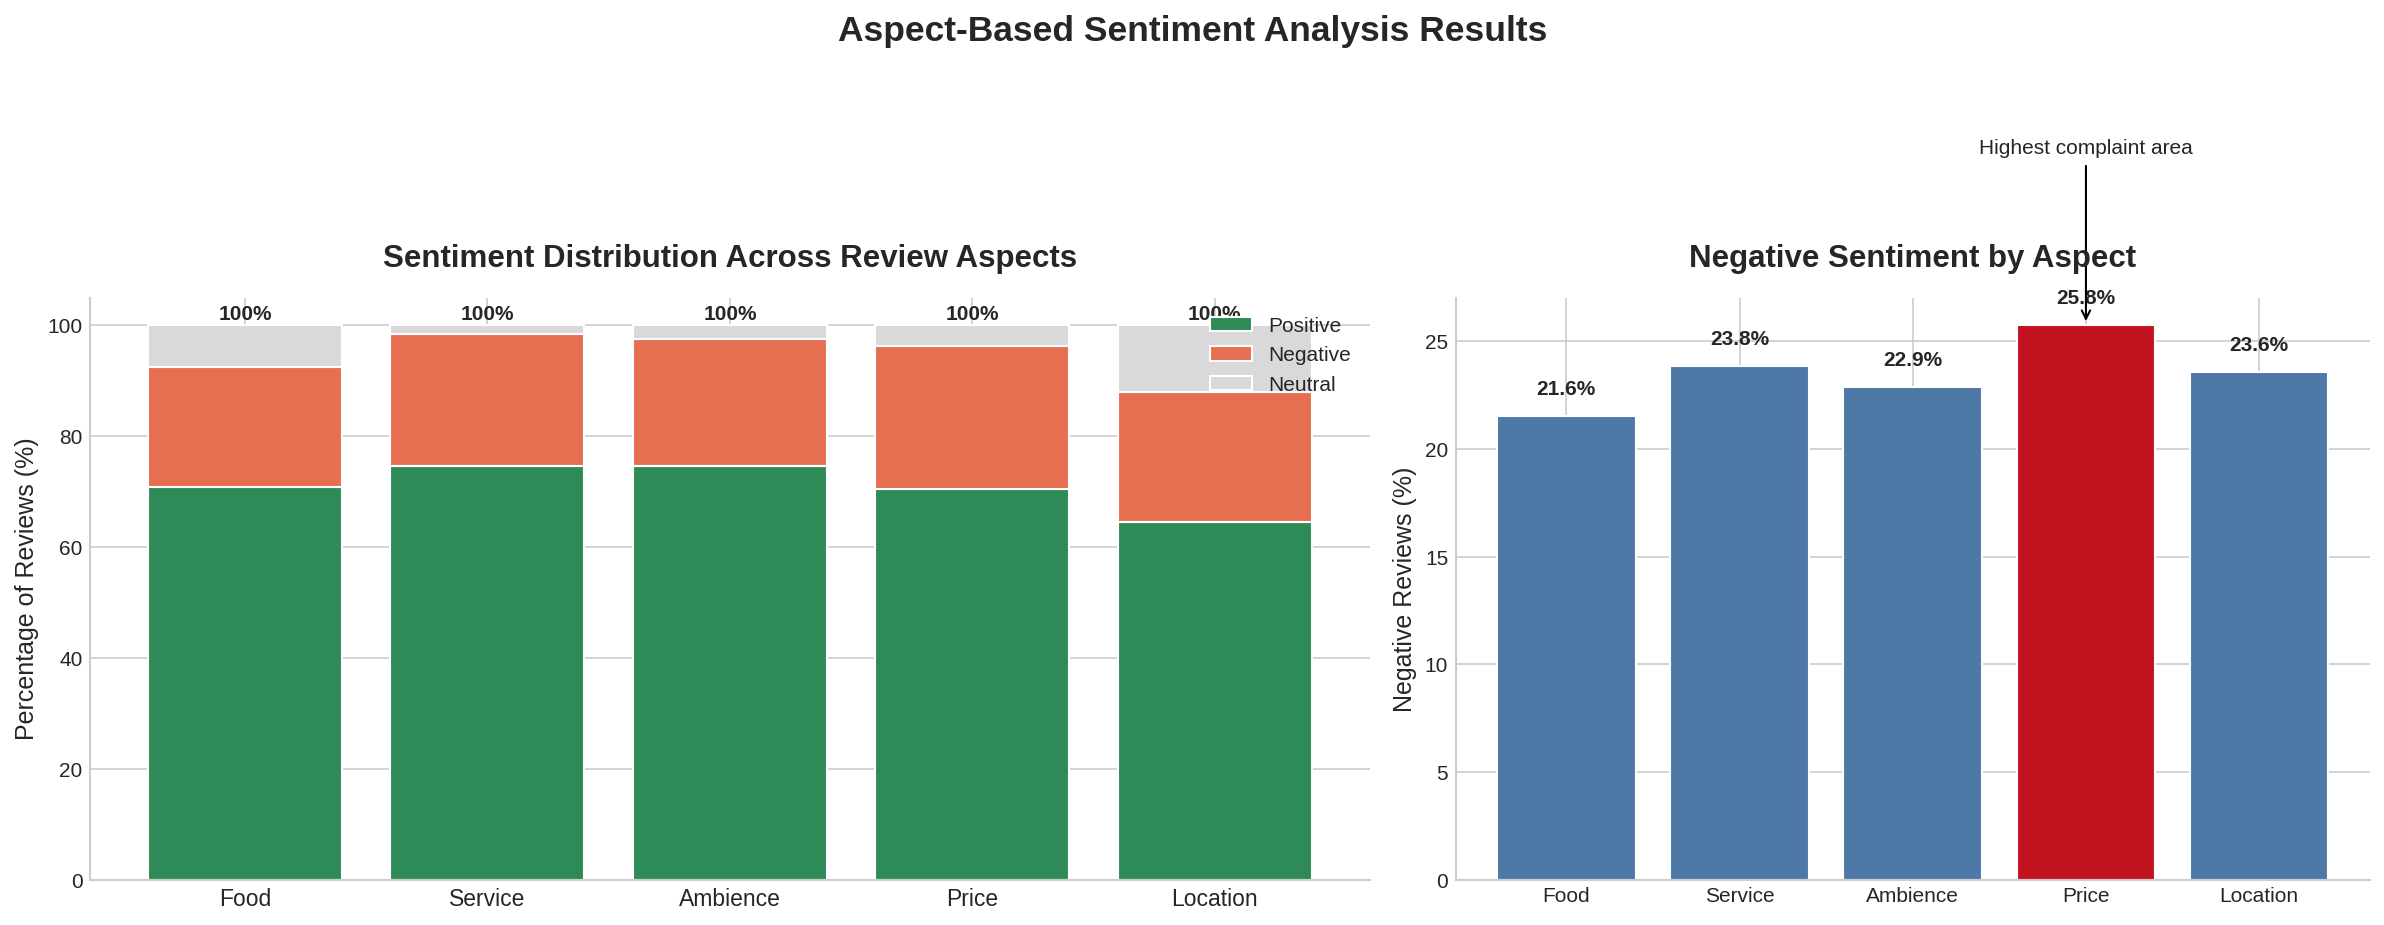


 BUSINESS INSIGHTS FROM ABSA
Most complained aspect: PRICE (25.8% negative)
Most praised aspect: SERVICE (74.6% positive)
Most neutral aspect: LOCATION (11.9% neutral)

ABSA results saved successfully.
{'Positive': np.int64(1411), 'Negative': np.int64(515), 'Neutral': np.int64(74)}
{'Positive': np.int64(1289), 'Negative': np.int64(472), 'Neutral': np.int64(239)}
total: 2000


In [66]:
# Prepare data
aspect_data = {}

for aspect in aspects:
    counts = sample_df[f'absa_{aspect}'].value_counts()
    aspect_data[aspect] = {
        'Positive': counts.get('Positive', 0),
        'Negative': counts.get('Negative', 0),
        'Neutral': counts.get('Neutral', 0)
    }

aspects_labels = [a.capitalize() for a in aspects]

total_absa_sample = len(sample_df)

pos_vals = [aspect_data[a]['Positive'] / total_absa_sample * 100 for a in aspects]
neg_vals = [aspect_data[a]['Negative'] / total_absa_sample * 100 for a in aspects]
neu_vals = [aspect_data[a]['Neutral'] / total_absa_sample * 100 for a in aspects]


plt.style.use('seaborn-v0_8-whitegrid')

positive_color = "#2E8B57"
negative_color = "#E76F51"
neutral_color  = "#D9D9D9"
highlight_color = "#C1121F"

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    gridspec_kw={'width_ratios': [1.4, 1]}
)


# Chart 1 - Sentiment Distribution per Aspect
x = np.arange(len(aspects))

axes[0].bar(
    x, pos_vals,
    color=positive_color,
    label='Positive',
    edgecolor='white'
)

axes[0].bar(
    x, neg_vals,
    bottom=pos_vals,
    color=negative_color,
    label='Negative',
    edgecolor='white'
)

axes[0].bar(
    x, neu_vals,
    bottom=np.array(pos_vals) + np.array(neg_vals),
    color=neutral_color,
    label='Neutral',
    edgecolor='white'
)

axes[0].set_title(
    "Sentiment Distribution Across Review Aspects",
    fontsize=15,
    fontweight='bold',
    pad=15
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(aspects_labels, fontsize=11)

axes[0].set_ylabel(
    "Percentage of Reviews (%)",
    fontsize=12
)

axes[0].legend(
    frameon=False,
    loc='upper right'
)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i in range(len(x)):
    total = pos_vals[i] + neg_vals[i] + neu_vals[i]
    axes[0].text(
        i,
        total + 1,
        f"{total:.0f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# Chart 2 - Negative Sentiment Comparison

max_neg = max(neg_vals)

neg_bar_colors = [
    highlight_color if v == max_neg else "#4E79A7"
    for v in neg_vals
]

bars = axes[1].bar(
    aspects_labels,
    neg_vals,
    color=neg_bar_colors,
    edgecolor='white'
)

axes[1].set_title(
    "Negative Sentiment by Aspect",
    fontsize=15,
    fontweight='bold',
    pad=15
)

axes[1].set_ylabel(
    "Negative Reviews (%)",
    fontsize=12
)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# Value labels above bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# highlight annotation
worst_aspect = aspects_labels[neg_vals.index(max_neg)]

axes[1].annotate(
    "Highest complaint area",
    xy=(neg_vals.index(max_neg), max_neg),
    xytext=(neg_vals.index(max_neg), max_neg + 8),
    ha='center',
    arrowprops=dict(
        arrowstyle='->',
        color='black'
    ),
    fontsize=10
)


plt.suptitle(
    "Aspect-Based Sentiment Analysis Results",
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()



# Business insight summary

print("\n BUSINESS INSIGHTS FROM ABSA")

print(
    f"Most complained aspect: "
    f"{aspects[neg_vals.index(max(neg_vals))].upper()} "
    f"({max(neg_vals):.1f}% negative)"
)

print(
    f"Most praised aspect: "
    f"{aspects[pos_vals.index(max(pos_vals))].upper()} "
    f"({max(pos_vals):.1f}% positive)"
)

print(
    f"Most neutral aspect: "
    f"{aspects[neu_vals.index(max(neu_vals))].upper()} "
    f"({max(neu_vals):.1f}% neutral)"
)

sample_df.to_pickle("absa_results.pkl")
print("\nABSA results saved successfully.")
print(aspect_data['price'])
print(aspect_data['location'])
print("total:", total_absa_sample)

In [67]:
# Merge ABSA results with overall sentiment
print("===ASPECT SENTIMENT BY OVERALL REVIEW SENTIMENT===\n")

for aspect in aspects:
    print(f"{aspect.upper()}:")
    for sentiment in ['positive', 'negative']:
        subset = sample_df[sample_df['sentiment'] == sentiment]
        neg_count = (subset[f'absa_{aspect}'] == 'Negative').sum()
        neg_pct = neg_count / len(subset) * 100
        pos_count = (subset[f'absa_{aspect}'] == 'Positive').sum()
        pos_pct = pos_count / len(subset) * 100
        print(f"  In {sentiment} reviews → aspect Positive: {pos_pct:.1f}% | Negative: {neg_pct:.1f}%")
    print()

# Cross-tab: which aspects drive negative overall reviews?
print("=== WHAT ASPECTS DRIVE NEGATIVE REVIEWS? ===")
neg_reviews = sample_df[sample_df['sentiment'] == 'negative']
print(f"Total negative reviews in sample: {len(neg_reviews)}\n")

for aspect in aspects:
    neg_aspect_pct = (neg_reviews[f'absa_{aspect}'] == 'Negative').sum() / len(neg_reviews) * 100
    bar = '█' * int(neg_aspect_pct / 2)
    print(f"  {aspect.upper():<12} {neg_aspect_pct:>5.1f}%  {bar}")

===ASPECT SENTIMENT BY OVERALL REVIEW SENTIMENT===

FOOD:
  In positive reviews → aspect Positive: 90.6% | Negative: 2.9%
  In negative reviews → aspect Positive: 9.3% | Negative: 82.9%

SERVICE:
  In positive reviews → aspect Positive: 94.3% | Negative: 4.3%
  In negative reviews → aspect Positive: 12.3% | Negative: 86.4%

AMBIENCE:
  In positive reviews → aspect Positive: 94.3% | Negative: 3.4%
  In negative reviews → aspect Positive: 10.4% | Negative: 86.4%

PRICE:
  In positive reviews → aspect Positive: 90.1% | Negative: 6.2%
  In negative reviews → aspect Positive: 7.5% | Negative: 89.6%

LOCATION:
  In positive reviews → aspect Positive: 82.5% | Negative: 5.1%
  In negative reviews → aspect Positive: 7.7% | Negative: 85.1%

=== WHAT ASPECTS DRIVE NEGATIVE REVIEWS? ===
Total negative reviews in sample: 375

  FOOD          82.9%  █████████████████████████████████████████
  SERVICE       86.4%  ███████████████████████████████████████████
  AMBIENCE      86.4%  ████████████████████

In [68]:
# ABSA QUALITATIVE EVALUATION

print("=== ABSA QUALITATIVE EVALUATION ===")
N_EVAL = 100

long_rows = []
for aspect in aspects:
    aspect_col = f'absa_{aspect}'
    sub = sample_df[['text', aspect_col, 'sentiment', 'stars']].copy()
    sub = sub.rename(columns={aspect_col: 'predicted'})
    sub['aspect'] = aspect
    long_rows.append(sub)
long_df = pd.concat(long_rows, ignore_index=True)
long_df = long_df.dropna(subset=['predicted'])

# Genuinely random sample of review-aspect pairs
all_eval = long_df.sample(n=min(N_EVAL, len(long_df)), random_state=42).reset_index(drop=True)
print(f"Randomly sampled {len(all_eval)} review-aspect pairs (uniform over aspects and predictions, not stratified by predicted label)")

print("\nPredicted-label composition of the random sample (reported for information only - it is an outcome of random sampling, not a sampling target): """)
print(all_eval['predicted'].value_counts().to_string())
print("\nAspect composition of the random sample:")
print(all_eval['aspect'].value_counts().to_string())

# Rebuild the per-aspect dict expected by the downstream cells
evaluation_samples = {
    aspect: all_eval[all_eval['aspect'] == aspect].reset_index(drop=True)
    for aspect in aspects
}

# -- Show samples with evaluation criteria --
print("\n=== SAMPLE REVIEW EXAMPLES ===")
for aspect in aspects:
    aspect_samples = evaluation_samples[aspect]
    if len(aspect_samples) == 0:
        print(f"\n{aspect.upper()}: no reviews landed in the random sample for this aspect.")
        continue
    print(f"\n{'='*65}")
    print(f"ASPECT: {aspect.upper()} ({len(aspect_samples)} randomly sampled pairs)")
    print(f"{'='*65}")

    for _, row in aspect_samples.head(4).iterrows():
        stars = row.get('stars', 0)
        pred = row['predicted']
        if pred == 'Positive' and stars >= 4:
            correctness_signal = "Likely Correct"
        elif pred == 'Negative' and stars <= 2:
            correctness_signal = "Likely Correct"
        elif pred == 'Neutral' and stars == 3:
            correctness_signal = "Likely Correct"
        else:
            correctness_signal = "Check Manually"

        print(f"\n  Predicted: {pred:<10} | "
              f"Overall: {row['sentiment']:<10} | "
              f"{int(stars)} Stars")
        print(f"  Signal:    {correctness_signal}")
        print(f"  Review:    {row['text'][:200]}...")
        print(f"  ---")

# Automatic signal-based accuracy estimate
print(f"\n{'='*65}")
print("=== AUTOMATIC SIGNAL-BASED CORRECTNESS ESTIMATE ===")
print("(Based on star rating alignment - proxy for true correctness, not a measured accuracy)\n")

total_correct_signal = 0
for aspect in aspects:
    aspect_samples = evaluation_samples[aspect]
    if len(aspect_samples) == 0:
        continue
    correct_signal = 0
    for _, row in aspect_samples.iterrows():
        stars = row.get('stars', 3)
        pred = row['predicted']
        if (pred == 'Positive' and stars >= 4) or \
           (pred == 'Negative' and stars <= 2) or \
           (pred == 'Neutral'  and stars == 3):
            correct_signal += 1
    rate = correct_signal / len(aspect_samples) * 100
    total_correct_signal += correct_signal
    print(f"  {aspect.capitalize():<12} Signal-correct: "
          f"{correct_signal}/{len(aspect_samples)} ({rate:.1f}%)")

overall_rate = total_correct_signal / len(all_eval) * 100
print(f"\n  Overall signal-based correctness estimate: {overall_rate:.1f}%")

# Save
all_eval.to_csv('absa_evaluation_100_samples.csv', index=False)
print(f"\nEvaluation samples saved to absa_evaluation_100_samples.csv")

=== ABSA QUALITATIVE EVALUATION ===
Randomly sampled 100 review-aspect pairs (uniform over aspects and predictions, not stratified by predicted label)

Predicted-label composition of the random sample (reported for information only - it is an outcome of random sampling, not a sampling target): 
predicted
Positive    71
Negative    25
Neutral      4

Aspect composition of the random sample:
aspect
service     25
location    21
price       19
food        18
ambience    17

=== SAMPLE REVIEW EXAMPLES ===

ASPECT: FOOD (18 randomly sampled pairs)

  Predicted: Positive   | Overall: positive   | 5 Stars
  Signal:    Likely Correct
  Review:    Wow, what a great shopping experience, Ryan and Paul really took time to get me what I needed. Never any pressure to buy!!! I went to the store first thing in the morning and got all the attention as ...
  ---

  Predicted: Positive   | Overall: neutral    | 3 Stars
  Signal:    Check Manually
  Review:    Great food. Terrible customer service. I've b

In [69]:
# ABSA EVALUATION - Wilson CI per aspect + overall
# 17-25 samples per aspect (n=100 in total)
# Correctness signal: star rating alignment

def wilson_ci_pct(k, n, z=1.96):
    """k correct out of n. Returns (lo%, hi%) or (None, None)."""
    if n == 0:
        return None, None
    lo, hi = wilson_ci(k / n, n, z)
    return lo * 100, hi * 100


absa_ci_rows = []
total_k, total_n = 0, 0

print(f"{'Aspect':<14} {'k':>4} {'n':>4} {'Accuracy':>9}  {'95% CI':>22}")
print("-" * 60)

for aspect in aspects:
    aspect_col   = f'absa_{aspect}'
    aspect_samps = evaluation_samples[aspect]
    k = sum(
        1 for _, row in aspect_samps.iterrows()
        if (row['predicted']=='Positive' and row.get('stars',3)>=4) or
           (row['predicted']=='Negative' and row.get('stars',3)<=2) or
           (row['predicted']=='Neutral'  and row.get('stars',3)==3)
    )
    n  = len(aspect_samps)
    lo, hi = wilson_ci_pct(k, n)
    total_k += k
    total_n += n
    ci_str = f"[{lo:.1f}% – {hi:.1f}%]" if lo is not None else "N/A"
    print(f"  {aspect.capitalize():<12} {k:>4} {n:>4} {k/n*100:>8.1f}%  {ci_str:>22}")
    absa_ci_rows.append({
        'aspect': aspect,
        'k_correct': k,
        'n_total': n,
        'accuracy_pct': k/n*100,
        'ci_lower_pct': lo if lo is not None else None,
        'ci_upper_pct': hi if hi is not None else None,
    })

# Overall row
lo_all, hi_all = wilson_ci_pct(total_k, total_n)
ci_str_all = f"[{lo_all:.1f}% – {hi_all:.1f}%]" if lo_all is not None else "N/A"
print("-" * 60)
print(f"  {'Overall':<12} {total_k:>4} {total_n:>4} {total_k/total_n*100:>8.1f}%  {ci_str_all:>22}")
absa_ci_rows.append({
    'aspect': 'overall',
    'k_correct': total_k,
    'n_total': total_n,
    'accuracy_pct': total_k/total_n*100,
    'ci_lower_pct': lo_all if lo_all is not None else None,
    'ci_upper_pct': hi_all if hi_all is not None else None,
})

absa_eval_ci_df = pd.DataFrame(absa_ci_rows)
absa_eval_ci_df.to_csv('absa_eval_ci.csv', index=False)
print(f'\nSaved absa_eval_ci.csv - {len(absa_eval_ci_df)} rows')
absa_eval_ci_df


Aspect            k    n  Accuracy                  95% CI
------------------------------------------------------------
  Food           12   18     66.7%         [43.7% – 83.7%]
  Service        22   25     88.0%         [70.0% – 95.8%]
  Ambience       15   17     88.2%         [65.7% – 96.7%]
  Price          14   19     73.7%         [51.2% – 88.2%]
  Location       18   21     85.7%         [65.4% – 95.0%]
------------------------------------------------------------
  Overall        81  100     81.0%         [72.2% – 87.5%]

Saved absa_eval_ci.csv - 6 rows


,aspect,k_correct,n_total,accuracy_pct,ci_lower_pct,ci_upper_pct
0,food,12,18,66.666667,43.749069,83.721446
1,service,22,25,88.000000,70.043808,95.833259
2,ambience,15,17,88.235294,65.663158,96.712092
3,price,14,19,73.684211,51.208032,88.193762
4,location,18,21,85.714286,65.363506,95.019078
5,overall,81,100,81.000000,72.220976,87.485346


In [70]:
# Category sentiment comparison
category_list = [
    'Restaurants', 'Hotels', 'Hair Salons',
    'Auto Repair', 'Coffee', 'Bars', 'Shopping'
]

category_results = []
for cat in category_list:
    mask = df_merged['categories'].str.contains(cat, case=False, na=False)
    subset = df_merged[mask]
    if len(subset) < 50:
        continue
    pos_pct = (subset['sentiment']=='positive').mean()*100
    neg_pct = (subset['sentiment']=='negative').mean()*100
    avg_star = subset['stars'].mean()
    category_results.append({
        'Category': cat,
        'Reviews': len(subset),
        'Positive %': round(pos_pct,1),
        'Negative %': round(neg_pct,1),
        'Avg Stars': round(avg_star,2)
    })

cat_df = pd.DataFrame(category_results).sort_values('Positive %', ascending=False)
print(cat_df.to_string(index=False))

   Category  Reviews  Positive %  Negative %  Avg Stars
Hair Salons      798        79.7        16.9       4.16
     Coffee     4031        73.6        15.7       3.98
   Shopping     3092        73.2        18.2       3.95
       Bars    13723        69.7        17.5       3.86
Restaurants    36149        68.6        18.8       3.81
Auto Repair      717        65.3        30.4       3.63
     Hotels     3009        65.1        22.8       3.67


## Customer Satisfaction Matrix

In [71]:
aspect_matrix = {}
for a in aspects:
    col = f'absa_{a}'
    total = len(sample_df)
    pos_n = int((sample_df[col] == 'Positive').sum())
    neg_n = int((sample_df[col] == 'Negative').sum())
    aspect_matrix[a] = {
        'pos': round(pos_n / total * 100, 1),
        'neg': round(neg_n / total * 100, 1),
        'mentions': pos_n + neg_n
    }

print('Aspect matrix (auto-calculated from ABSA results):')
for k, v in aspect_matrix.items():
    print(f" {k:<12} pos={v['pos']}%  neg={v['neg']}%  mentions={v['mentions']}")

Aspect matrix (auto-calculated from ABSA results):
 food         pos=70.9%  neg=21.6%  mentions=1849
 service      pos=74.6%  neg=23.8%  mentions=1969
 ambience     pos=74.6%  neg=22.9%  mentions=1950
 price        pos=70.5%  neg=25.8%  mentions=1926
 location     pos=64.5%  neg=23.6%  mentions=1761


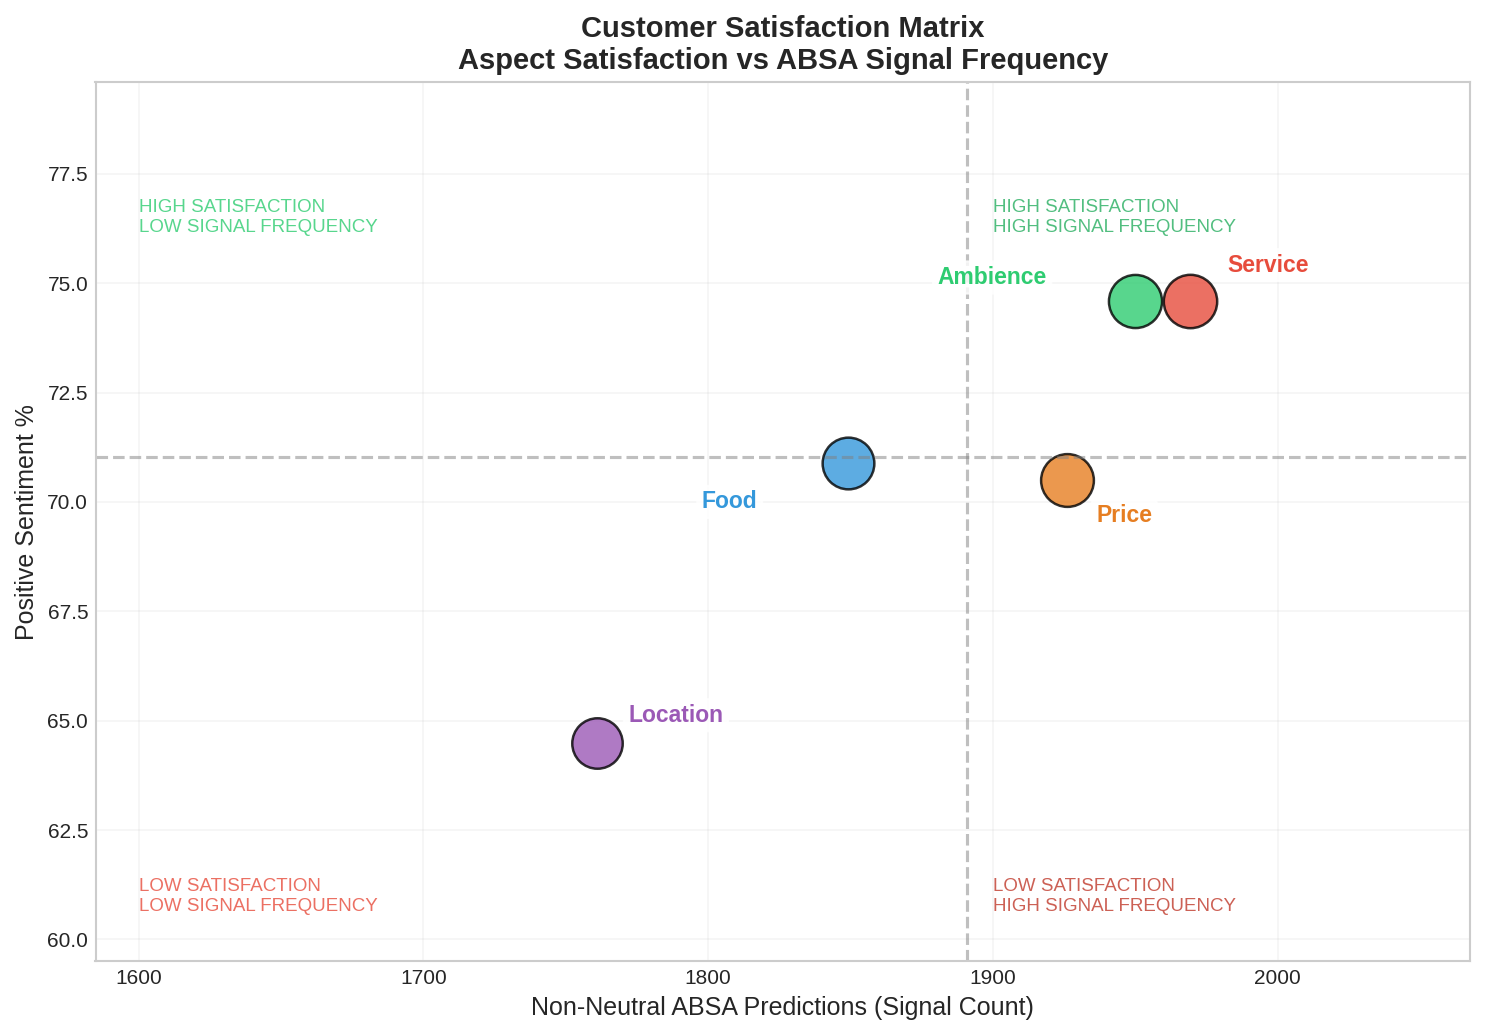

In [72]:
fig, ax = plt.subplots(figsize=(10, 7))

avg_pos = np.mean([v['pos'] for v in aspect_matrix.values()])
avg_men = np.mean([v['mentions'] for v in aspect_matrix.values()])

x_min = min(v['mentions'] for v in aspect_matrix.values()) * 0.9
x_max = max(v['mentions'] for v in aspect_matrix.values()) * 1.05

y_values = [v['pos'] for v in aspect_matrix.values()]
y_min = min(y_values) - 5
y_max = max(y_values) + 5

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.axhline(avg_pos, color='gray', linestyle='--', alpha=0.5)
ax.axvline(avg_men, color='gray', linestyle='--', alpha=0.5)

# Quadrant label positions within plot bounds
x_left = x_min + (avg_men - x_min) * 0.05
x_right = avg_men + (x_max - avg_men) * 0.05
y_high = avg_pos + (y_max - avg_pos) * 0.6
y_low = y_min + (avg_pos - y_min) * 0.1

ax.text(x_left,  y_high, 'HIGH SATISFACTION\nLOW SIGNAL FREQUENCY', fontsize=9, color='#2ecc71', alpha=0.8)
ax.text(x_right, y_high, 'HIGH SATISFACTION\nHIGH SIGNAL FREQUENCY', fontsize=9, color='#27ae60', alpha=0.8)
ax.text(x_left,  y_low, 'LOW SATISFACTION\nLOW SIGNAL FREQUENCY', fontsize=9, color='#e74c3c', alpha=0.8)
ax.text(x_right, y_low, 'LOW SATISFACTION\nHIGH SIGNAL FREQUENCY', fontsize=9, color='#c0392b', alpha=0.8)

colors_asp = {
    'food':'#3498db',
    'service':'#e74c3c',
    'ambience':'#2ecc71',
    'price':'#e67e22',
    'location':'#9b59b6'
}
label_offsets = {
    'food': (-70, -22),
    'service': (18, 14),
    'ambience': (-95, 8),
    'price': (14, -20),
    'location': (15, 10),
}
for aspect, data in aspect_matrix.items():
    ax.scatter(data['mentions'], data['pos'],
               s=data['mentions'] / 3,
               color=colors_asp[aspect],
               alpha=0.8,
               edgecolor='black',
               linewidth=1.2)
    ax.annotate(aspect.capitalize(),
                (data['mentions'], data['pos']),
                textcoords='offset points',
                xytext=label_offsets[aspect],
                fontsize=11,
                fontweight='bold',
                color=colors_asp[aspect],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

ax.set_xlabel('Non-Neutral ABSA Predictions (Signal Count)', fontsize=12)
ax.set_ylabel('Positive Sentiment %', fontsize=12)
ax.set_title('Customer Satisfaction Matrix\nAspect Satisfaction vs ABSA Signal Frequency', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig_satisfaction_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## Trend Analysis

In [73]:
# ASPECT-LEVEL TREND ANALYSIS

aspects = ['food', 'service', 'ambience', 'price', 'location']

sample_df['date']  = pd.to_datetime(sample_df['date'])
sample_df['month'] = sample_df['date'].dt.to_period('M')

# 1. MONTHLY NEGATIVE-SENTIMENT RATE, PER ASPECT
print("=== ASPECT-LEVEL MONTHLY NEGATIVE SENTIMENT RATE ===\n")
print("NOTE: the 2,000-review ABSA sample is small once split by month, so monthly counts per aspect can be in the low tens - treat the month-to-month series as noisier than the overall-sentiment trend")

monthly_aspect_neg = {}
for aspect in aspects:
    col = f'absa_{aspect}'
    monthly = (
        sample_df.groupby('month')
        .apply(lambda g: (g[col] == 'Negative').mean() * 100)
    )
    monthly_aspect_neg[aspect] = monthly

trend_df = pd.DataFrame(monthly_aspect_neg)
print(trend_df.round(1))
print(f"\nMonths covered: {len(trend_df)}  |  Avg reviews per month in ABSA sample: {len(sample_df)/len(trend_df):.0f}")

=== ASPECT-LEVEL MONTHLY NEGATIVE SENTIMENT RATE ===

NOTE: the 2,000-review ABSA sample is small once split by month, so monthly counts per aspect can be in the low tens - treat the month-to-month series as noisier than the overall-sentiment trend
          food  service  ambience  price  location
month                                             
2005-09    0.0      0.0       0.0    0.0       0.0
2005-11    0.0      0.0       0.0    0.0       0.0
2006-04    0.0      0.0       0.0    0.0       0.0
2006-05   50.0      0.0      50.0   50.0      50.0
2006-07    0.0      0.0       0.0    0.0       0.0
...        ...      ...       ...    ...       ...
2018-06   17.2     17.2      17.2   24.1      24.1
2018-07   15.2     24.2      24.2   27.3      21.2
2018-08   21.4     17.9      21.4   25.0      25.0
2018-09   35.0     40.0      35.0   40.0      35.0
2018-10  100.0    100.0     100.0  100.0     100.0

[122 rows x 5 columns]

Months covered: 122  |  Avg reviews per month in ABSA sample: 1

In [74]:
# 2. MANN-KENDALL TREND TEST PER ASPECT
print("\n=== MANN-KENDALL TREND TEST, PER ASPECT (negative sentiment %) ===\n")

trend_results = []
for aspect in aspects:
    series = trend_df[aspect].dropna().values
    if len(series) < 4:
        print(f"{aspect.upper():<10} insufficient months of data for a reliable trend test (n={len(series)}), skipped.")
        continue
    result = mk.original_test(series)
    trend_results.append({
        'aspect': aspect,
        'trend': result.trend,
        'p_value': result.p,
        'tau': result.Tau,
        'slope_pct_per_month': result.slope,
        'n_months': len(series)
    })
    sig = "SIGNIFICANT (p<0.05)" if result.p < 0.05 else "not significant (p>=0.05)"
    print(f"{aspect.upper():<10} trend={result.trend:<12} p={result.p:.4f}  "
          f"slope={result.slope:+.4f} pts/month  tau={result.Tau:+.3f}   --> {sig}")

trend_results_df = pd.DataFrame(trend_results)
print("\n" + "="*60)
n_sig = (trend_results_df['p_value'] < 0.05).sum() if len(trend_results_df) else 0
print(f"Aspects with a statistically significant trend: {n_sig} / {len(trend_results_df)}")
if n_sig == 0:
    print("--> No aspect shows a statistically significant change in negative sentiment over time within this sample; apparent ups/downs in the chart below are consistent with random month-to-month noise given the small per-month sample sizes.")


=== MANN-KENDALL TREND TEST, PER ASPECT (negative sentiment %) ===

FOOD       trend=increasing   p=0.0029  slope=+0.1120 pts/month  tau=+0.182   --> SIGNIFICANT (p<0.05)
SERVICE    trend=increasing   p=0.0019  slope=+0.1217 pts/month  tau=+0.190   --> SIGNIFICANT (p<0.05)
AMBIENCE   trend=increasing   p=0.0006  slope=+0.1289 pts/month  tau=+0.210   --> SIGNIFICANT (p<0.05)
PRICE      trend=increasing   p=0.0082  slope=+0.1054 pts/month  tau=+0.162   --> SIGNIFICANT (p<0.05)
LOCATION   trend=increasing   p=0.0003  slope=+0.1443 pts/month  tau=+0.219   --> SIGNIFICANT (p<0.05)

Aspects with a statistically significant trend: 5 / 5


In [75]:
# 2b. MULTIPLE-COMPARISON CORRECTION (Benjamini-Hochberg FDR)
# Five aspect-level Mann-Kendall tests were run above; correct for multiple comparisons before treating all five as independently significant.

print("\n=== BENJAMINI-HOCHBERG FDR CORRECTION ACROSS 5 ASPECT TESTS ===\n")

reject, p_adj, _, _ = multipletests(
    trend_results_df['p_value'].values,
    alpha=0.05,
    method='fdr_bh'
)
trend_results_df['p_value_fdr_bh'] = p_adj
trend_results_df['significant_after_fdr'] = reject

print(trend_results_df[['aspect', 'p_value', 'p_value_fdr_bh', 'significant_after_fdr']]
      .to_string(index=False))

n_sig_fdr = trend_results_df['significant_after_fdr'].sum()
print(f"\nAspects remaining significant after FDR correction: {n_sig_fdr} / {len(trend_results_df)}")



=== BENJAMINI-HOCHBERG FDR CORRECTION ACROSS 5 ASPECT TESTS ===

  aspect  p_value  p_value_fdr_bh  significant_after_fdr
    food 0.002929        0.003661                   True
 service 0.001899        0.003165                   True
ambience 0.000600        0.001501                   True
   price 0.008193        0.008193                   True
location 0.000334        0.001501                   True

Aspects remaining significant after FDR correction: 5 / 5


## Error Analysis

In [76]:
# ASPECT-LEVEL ERROR ANALYSIS (for ABSA)

# split into "signal-correct" vs "signal-flagged" subsets.
def signal_correct(row):
    stars = row.get('stars', 3)
    pred  = row['predicted']
    if (pred == 'Positive' and stars >= 4) or \
       (pred == 'Negative' and stars <= 2) or \
       (pred == 'Neutral'  and stars == 3):
        return True
    return False

all_eval['signal_correct'] = all_eval.apply(signal_correct, axis=1)
flagged = all_eval[~all_eval['signal_correct']].copy()

# 1. WHICH PREDICTED LABEL IS MOST OVER-REPRESENTED AMONG
print("=== SIGNAL-FLAGGED CASES, BY ASPECT AND PREDICTED LABEL ===\n")

flag_breakdown = flagged.groupby(['aspect', 'predicted']).size().unstack(fill_value=0)
print(flag_breakdown)

print("\n--- Flagged rate by aspect ---")
for aspect in aspects:
    sub = all_eval[all_eval['aspect'] == aspect]
    sub_flagged = sub[~sub['signal_correct']]
    if len(sub) == 0:
        continue
    print(f"\n{aspect.upper()} - {len(sub_flagged)}/{len(sub)} flagged ({len(sub_flagged)/len(sub)*100:.1f}%)")
    if len(sub_flagged):
        print(sub_flagged['predicted'].value_counts().to_string())

=== SIGNAL-FLAGGED CASES, BY ASPECT AND PREDICTED LABEL ===

predicted  Negative  Neutral  Positive
aspect                                
ambience          0        1         1
food              1        2         3
location          0        1         2
price             3        0         2
service           2        0         1

--- Flagged rate by aspect ---

FOOD - 6/18 flagged (33.3%)
predicted
Positive    3
Neutral     2
Negative    1

SERVICE - 3/25 flagged (12.0%)
predicted
Negative    2
Positive    1

AMBIENCE - 2/17 flagged (11.8%)
predicted
Positive    1
Neutral     1

PRICE - 5/19 flagged (26.3%)
predicted
Negative    3
Positive    2

LOCATION - 3/21 flagged (14.3%)
predicted
Positive    2
Neutral     1


In [77]:
# 2. STAR-RATING DISTRIBUTION WITHIN FLAGGED CASES
print("\n\n=== STAR RATING DISTRIBUTION WITHIN FLAGGED CASES ===\n")
print(flagged['stars'].value_counts().sort_index())
print(f"\nMean stars in flagged cases: {flagged['stars'].mean():.2f}")
print(f"Mean stars in signal-correct cases: {all_eval[all_eval['signal_correct']]['stars'].mean():.2f}")

mid_rating_flagged = flagged[flagged['stars'].isin([3, 4])]
print(f"\nFlagged cases at 3-4 stars (plausibly mixed-sentiment reviews): "
      f"{len(mid_rating_flagged)}/{len(flagged)} ({len(mid_rating_flagged)/len(flagged)*100:.1f}%)")



=== STAR RATING DISTRIBUTION WITHIN FLAGGED CASES ===

stars
1.0    2
2.0    1
3.0    8
4.0    7
5.0    1
Name: count, dtype: int64

Mean stars in flagged cases: 3.21
Mean stars in signal-correct cases: 3.99

Flagged cases at 3-4 stars (plausibly mixed-sentiment reviews): 15/19 (78.9%)


In [78]:
# 3. QUALITATIVE INSPECTION: show the actual flagged review text,
print("\n\n=== SAMPLE FLAGGED PREDICTIONS, BY ASPECT (for manual error-type coding) ===")
for aspect in aspects:
    aspect_flagged = flagged[flagged['aspect'] == aspect]
    if len(aspect_flagged) == 0:
        print(f"\n{aspect.upper()}: no flagged cases in this sample.")
        continue
    print(f"\n{'='*60}\n{aspect.upper()} - {len(aspect_flagged)} flagged case(s)\n{'='*60}")
    for _, row in aspect_flagged.iterrows():
        print(f"\n  Predicted: {row['predicted']:<10} | Overall sentiment: {row['sentiment']:<10} | {int(row['stars'])} stars")
        print(f"  Review: {row['text'][:220]}...")
        print(f"  [Manual code: aspect-not-mentioned / mixed-sentiment-review / genuine-model-error] -> ____")

# Save for inclusion as a dissertation appendix table
flagged.to_csv('absa_flagged_cases_for_manual_coding.csv', index=False)
print(f"\n\nSaved {len(flagged)} flagged cases to absa_flagged_cases_for_manual_coding.csv")



=== SAMPLE FLAGGED PREDICTIONS, BY ASPECT (for manual error-type coding) ===

FOOD - 6 flagged case(s)

  Predicted: Positive   | Overall sentiment: neutral    | 3 stars
  Review: Great food. Terrible customer service. I've been three times and I've had two different older waitresses. Not pleasant to deal with whatsoever. The owner on the other hand is lovely....
  [Manual code: aspect-not-mentioned / mixed-sentiment-review / genuine-model-error] -> ____

  Predicted: Negative   | Overall sentiment: neutral    | 3 stars
  Review: Let me start by saying that I love In N Out and I would give In N Out 5 stars hands down for the food alone.  I am giving 3 stars for this location only and here is why......we got in there, granted it was pretty late, b...
  [Manual code: aspect-not-mentioned / mixed-sentiment-review / genuine-model-error] -> ____

  Predicted: Positive   | Overall sentiment: neutral    | 3 stars
  Review: A place just for Mac and Cheese? Yes pl(ch)eeeeseee!  hearing about 

# Question-to-Insight Mapping

In [79]:
question_library = {
    "Q1": {
        "question": "What is the overall sentiment of customer reviews?",
        "analysis": "sentiment_distribution",
        "description": "Distribution of positive, neutral and negative reviews across the dataset"
    },

    "Q2": {
        "question": "Which aspects of the customer experience receive the most praise and criticism?",
        "analysis": "absa",
        "description": "Aspect-based sentiment analysis of food, service, ambience, price, and location"
    },

    "Q3": {
        "question": "What topics are most frequently discussed in customer reviews?",
        "analysis": "topic_modelling",
        "description": "Key themes identified through LDA topic modelling"
    },

    "Q4": {
        "question": "How has customer sentiment changed over time?",
        "analysis": "sentiment_over_time",
        "description": "Monthly sentiment trend over the review period"
    },

    "Q5": {
        "question": "What words are most frequently associated with positive and negative reviews?",
        "analysis": "review_drivers",
        "description": "Top words in 1-star vs 5-star reviews"
    }
}

print("=== RESEARCH QUESTION LIBRARY ===")

for qid, qdata in question_library.items():
    print(f"\n{qid}: {qdata['question']}")
    print(f"   → {qdata['description']}")

=== RESEARCH QUESTION LIBRARY ===

Q1: What is the overall sentiment of customer reviews?
   → Distribution of positive, neutral and negative reviews across the dataset

Q2: Which aspects of the customer experience receive the most praise and criticism?
   → Aspect-based sentiment analysis of food, service, ambience, price, and location

Q3: What topics are most frequently discussed in customer reviews?
   → Key themes identified through LDA topic modelling

Q4: How has customer sentiment changed over time?
   → Monthly sentiment trend over the review period

Q5: What words are most frequently associated with positive and negative reviews?
   → Top words in 1-star vs 5-star reviews


# Save Result

In [80]:
# Get TF-IDF
def get_tfidf_top_words(df, star, n=15):
    subset = df[df['stars'] == star]['clean_text']
    tfidf = TfidfVectorizer(max_features=5000)
    tfidf_matrix = tfidf.fit_transform(subset)
    scores = tfidf_matrix.mean(axis=0).A1
    words = tfidf.get_feature_names_out()
    top_idx = scores.argsort()[-n:][::-1]
    return [(words[i], scores[i]) for i in top_idx]

pos_tfidf = get_tfidf_top_words(df_reviews, 5)
neg_tfidf = get_tfidf_top_words(df_reviews, 1)

print("=== TOP TF-IDF WORDS - 5-STAR ===")
for w, s in pos_tfidf:
    print(f"  {w:<20} {s:.4f}")

print("\n=== TOP TF-IDF WORDS - 1-STAR ===")
for w, s in neg_tfidf:
    print(f"  {w:<20} {s:.4f}")

=== TOP TF-IDF WORDS - 5-STAR ===
  great                0.0409
  place                0.0348
  food                 0.0346
  good                 0.0277
  service              0.0259
  time                 0.0228
  best                 0.0225
  love                 0.0212
  amazing              0.0200
  back                 0.0190
  friendly             0.0187
  delicious            0.0186
  always               0.0182
  staff                0.0181
  go                   0.0180

=== TOP TF-IDF WORDS - 1-STAR ===
  food                 0.0353
  place                0.0286
  service              0.0266
  time                 0.0266
  one                  0.0227
  would                0.0226
  order                0.0226
  back                 0.0225
  get                  0.0218
  like                 0.0214
  never                0.0212
  go                   0.0199
  even                 0.0191
  minute               0.0188
  good                 0.0177


In [81]:
# EXPORT 1: results_summary.csv - Accuracy, Accuracy CI, Test N, F1, Precision, Recall, Coherence, KPI

summary_rows = []

# Sentiment models: Accuracy + 95% CI + Test N + F1/Precision/Recall (per class)
for model_name, acc, rpt in [
    ('VADER', v_acc, v_rpt),
    ('Logistic Regression', lr_acc, lr_rpt),
    ('BERT', b_acc, b_rpt),
]:
    # Accuracy
    summary_rows.append({
        'Model': model_name,
        'Metric': 'Accuracy',
        'Value': round(acc, 4)
    })

    # Accuracy 95% Wilson Confidence Interval
    acc_ci_lower, acc_ci_upper = wilson_ci(acc, test_n)

    summary_rows += [
        {
            'Model': model_name,
            'Metric': 'Accuracy_CI_Lower',
            'Value': round(acc_ci_lower, 4)
        },
        {
            'Model': model_name,
            'Metric': 'Accuracy_CI_Upper',
            'Value': round(acc_ci_upper, 4)
        },
    ]

    # Test-set size
    summary_rows.append({
        'Model': model_name,
        'Metric': 'KPI_Test_N',
        'Value': int(test_n)
    })

    # F1 / Precision / Recall per class
    for cls_label in ['Positive', 'Negative', 'Neutral']:
        d = rpt.get(cls_label.lower(), {})

        for metric_name, metric_key in [
            ('F1', 'f1-score'),
            ('Precision', 'precision'),
            ('Recall', 'recall')
        ]:
            summary_rows.append({
                'Model': model_name,
                'Metric': f'{metric_name}_{cls_label}',
                'Value': round(d.get(metric_key, 0), 4)
            })


# Topic models: Coherence
summary_rows += [
    {
        'Model': 'LDA',
        'Metric': 'Coherence',
        'Value': round(coherence_score, 4)
    },
    {
        'Model': 'BERTopic',
        'Metric': 'Coherence',
        'Value': round(bertopic_score_val, 4)
    },
]


# LDA hyperparameter tuning history (grid search run earlier in notebook)
# Stored as JSON-encoded list so it can live in one row of the long-format CSV
import json as _json

lda_tuning_history = [
    {
        'Configuration': 'Baseline (10 topics)',
        'C_V Score': round(coherence_score_baseline, 4),
        'Decision': 'Baseline'
    },
    {
        'Configuration': 'Optimal (11 topics)',
        'C_V Score': round(coherence_score_optimal, 4),
        'Decision': 'Improved'
    },
    {
        'Configuration': 'Custom stopwords',
        'C_V Score': round(coherence_v2, 4),
        'Decision': 'Rejected'
    },
    {
        'Configuration': 'Looser filter',
        'C_V Score': round(coherence_v3, 4),
        'Decision': 'Rejected'
    },
    {
        'Configuration': 'Bigrams/trigrams',
        'C_V Score': round(coherence_v4, 4),
        'Decision': 'Rejected'
    },
    {
        'Configuration': 'Final (passes=15)',
        'C_V Score': round(coherence_score, 4),
        'Decision': 'Final'
    },
]

summary_rows.append({
    'Model': 'LDA',
    'Metric': 'TuningHistory_JSON',
    'Value': _json.dumps(lda_tuning_history)
})


# Other KPIs (dashboard-level summary numbers)
kpi_total_reviews = len(df_reviews)
kpi_avg_stars = round(df_reviews['stars'].mean(), 2)
kpi_pos_pct = round((df_reviews['sentiment'] == 'positive').mean() * 100, 1)
kpi_neg_pct = round((df_reviews['sentiment'] == 'negative').mean() * 100, 1)
kpi_neu_pct = round((df_reviews['sentiment'] == 'neutral').mean() * 100, 1)
kpi_n_topics = int(lda_model.num_topics)
kpi_lda_coverage = 100.0
kpi_bertopic_cov = round(n_assigned / len(df_reviews) * 100, 1)
kpi_proxy_alignment = round(avg_alignment, 1)
kpi_proxy_n_cats = len(alignment_df)

summary_rows += [
    {
        'Model': 'Overall',
        'Metric': 'KPI_Total_Reviews',
        'Value': kpi_total_reviews
    },
    {
        'Model': 'Overall',
        'Metric': 'KPI_Avg_Stars',
        'Value': kpi_avg_stars
    },
    {
        'Model': 'Overall',
        'Metric': 'KPI_Positive_Pct',
        'Value': kpi_pos_pct
    },
    {
        'Model': 'Overall',
        'Metric': 'KPI_Negative_Pct',
        'Value': kpi_neg_pct
    },
    {
        'Model': 'Overall',
        'Metric': 'KPI_Neutral_Pct',
        'Value': kpi_neu_pct
    },
    {
        'Model': 'LDA',
        'Metric': 'KPI_N_Topics',
        'Value': kpi_n_topics
    },
    {
        'Model': 'LDA',
        'Metric': 'KPI_Coverage_Pct',
        'Value': kpi_lda_coverage
    },
    {
        'Model': 'BERTopic',
        'Metric': 'KPI_Coverage_Pct',
        'Value': kpi_bertopic_cov
    },
    {
        'Model': 'LDA',
        'Metric': 'KPI_Proxy_GT_Alignment',
        'Value': kpi_proxy_alignment
    },
    {
        'Model': 'LDA',
        'Metric': 'KPI_Proxy_GT_NumCategories',
        'Value': kpi_proxy_n_cats
    },
]


# McNemar's test results (for dashboard Statistical Validation section)
for comparison, stat, p in [
    ('BERT_vs_VADER', res_bert_vader.statistic, res_bert_vader.pvalue),
    ('BERT_vs_LR', res_bert_lr.statistic, res_bert_lr.pvalue),
]:
    summary_rows += [
        {
            'Model': 'McNemar',
            'Metric': f'{comparison}_Statistic',
            'Value': round(float(stat), 4)
        },
        {
            'Model': 'McNemar',
            'Metric': f'{comparison}_PValue',
            'Value': f'{p:.3e}'
        },
    ]


# BERT Error Analysis export (for dashboard Error Analysis section)
error_df.to_csv('bert_error_analysis.csv', index=False)
print('Saved bert_error_analysis.csv')

# Final results summary export
results_summary = pd.DataFrame(summary_rows)
results_summary.to_csv('results_summary.csv', index=False)

print(f'Saved results_summary.csv - {len(results_summary)} rows')

# Quick verification of dashboard-required fields
print("\nDashboard KPI fields:")

results_summary

Saved bert_error_analysis.csv
Saved results_summary.csv - 56 rows

Dashboard KPI fields:


,Model,Metric,Value
0,VADER,Accuracy,0.773
1,VADER,Accuracy_CI_Lower,0.7647
2,VADER,Accuracy_CI_Upper,0.7811
3,VADER,KPI_Test_N,10000
4,VADER,F1_Positive,0.8688
5,VADER,Precision_Positive,0.7793
6,VADER,Recall_Positive,0.9815
7,VADER,F1_Negative,0.5744
8,VADER,Precision_Negative,0.7773
9,VADER,Recall_Negative,0.4555


In [82]:
# EXPORT 2: absa_results.csv - aspect, sentiment, frequency

absa_rows = []
for aspect in aspects:
    col = f'absa_{aspect}'
    counts = sample_df[col].value_counts()
    for sentiment_label in ['Positive', 'Negative', 'Neutral']:
        absa_rows.append({
            'aspect': aspect,
            'sentiment': sentiment_label,
            'frequency': int(counts.get(sentiment_label, 0))
        })

absa_results_df = pd.DataFrame(absa_rows)
absa_results_df.to_csv('absa_results.csv', index=False)
print(f'Saved absa_results.csv - {len(absa_results_df)} rows')
absa_results_df


Saved absa_results.csv - 15 rows


,aspect,sentiment,frequency
0,food,Positive,1418
1,food,Negative,431
2,food,Neutral,151
3,service,Positive,1492
4,service,Negative,477
5,service,Neutral,31
6,ambience,Positive,1492
7,ambience,Negative,458
8,ambience,Neutral,50
9,price,Positive,1411


In [83]:
# EXPORT 3: topic_results.csv - topic_id, keywords, size

topic_rows = []
topic_sizes = df_reviews['dominant_topic'].value_counts()

for topic_id in range(lda_model.num_topics):
    top_words = lda_model.show_topic(topic_id, topn=8)
    keywords = ', '.join([w for w, _ in top_words])
    size = int(topic_sizes.get(topic_id, 0))
    topic_rows.append({
        'topic_id': topic_id,
        'label': topic_labels.get(topic_id, f'Topic {topic_id}'),
        'keywords': keywords,
        'size': size
    })

topic_results_df = pd.DataFrame(topic_rows)
topic_results_df.to_csv('topic_results.csv', index=False)
print(f'Saved topic_results.csv - {len(topic_results_df)} rows')
topic_results_df


Saved topic_results.csv - 11 rows


,topic_id,label,keywords,size
0,0,General Experience,"place, great, food, good, service, really, go,...",32363
1,1,Fast Food & American,"chicken, pizza, good, sauce, ordered, burger, ...",2993
2,2,Hotels,"room, hotel, stay, clean, nice, bathroom, staf...",622
3,3,Hair & Auto Services,"car, work, hair, day, job, year, called, customer",1921
4,4,Cafes & Desserts,"coffee, cream, ice, cake, chocolate, tea, flav...",281
5,5,Fine Dining,"wine, shrimp, restaurant, dinner, dish, meal, ...",754
6,6,Complaints,"time, u, would, one, back, got, didnt, order",10364
7,7,Bars & Nightlife,"bar, drink, night, music, bartender, game, sea...",127
8,8,Pet & Retail,"store, dog, shop, buy, find, lot, park, item",389
9,9,Asian Cuisine,"roll, sushi, thai, soup, rice, noodle, dish, tour",71


In [84]:
!pip freeze > environment_requirements.txt

# Streamlit

In [85]:


%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import json
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from gensim import corpora
from gensim.models import LdaModel
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
import plotly.colors as pc

CSS = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&family=JetBrains+Mono:wght@400;600&display=swap');

    /* -- Reset & base -- */
    .block-container { padding-top: 1.2rem; padding-bottom: 2rem; max-width: 1400px; }
    section[data-testid="stSidebar"] { background: #0f1117; }
    section[data-testid="stSidebar"] * { color: #e2e8f0 !important; }
    section[data-testid="stSidebar"] input {color: #1e293b !important;}
    section[data-testid="stSidebar"] .stDateInput * {color: #1e293b !important;}
    section[data-testid="stSidebar"] .stDateInput input {color: #1e293b !important; background: #ffffff !important;}
    section[data-testid="stSidebar"] .stDateInput div[data-baseweb="input"] {background: #ffffff !important;}
    section[data-testid="stSidebar"] .stRadio label { padding: 0.35rem 0.75rem; border-radius: 6px; transition: background 0.15s; }
    section[data-testid="stSidebar"] .stRadio label:hover { background: rgba(255,255,255,0.07); }
    section[data-testid="stSidebar"] .stButton button * {
        background: #ffffff;
        color: #1e293b !important;
        font-weight: 600;
        transition: background 0.05s, color 0.05s !important;
    }
    section[data-testid="stSidebar"] .stButton button:hover {
        background-color: #6366f1 !important;
        border-color: #6366f1 !important;
    }

    section[data-testid="stSidebar"] .stButton button:hover * {
        color: #ffffff !important;
        background-color: transparent !important;
    }

    /* -- Page header -- */
    .page-header {
        display: flex; align-items: flex-start; gap: 1rem;
        padding: 1.4rem 1.8rem; margin-bottom: 1.5rem;
        background: linear-gradient(135deg, #0f1117 0%, #1a1f2e 100%);
        border-radius: 14px; border-left: 4px solid #6366f1;
    }
    .page-title { font-size: 1.65rem; font-weight: 800; color: #f1f5f9; margin: 0; letter-spacing: -0.02em; }
    .page-subtitle { color: #94a3b8; font-size: 0.88rem; margin-top: 0.3rem; }

    /* -- Section headers -- */
    .section-header {
        font-size: 0.72rem; font-weight: 700; color: #6366f1;
        text-transform: uppercase; letter-spacing: 0.12em;
        padding: 0.5rem 0 0.5rem 0; margin: 1.5rem 0 0.8rem 0;
        border-bottom: 1px solid #e2e8f0;
    }

    /* -- KPI cards -- */
    .kpi-grid { display: flex; gap: 0.8rem; margin-bottom: 1.2rem; }
    .kpi-card {
        flex: 1; background: #ffffff; border-radius: 12px;
        padding: 1.1rem 1.3rem; text-align: left;
        border: 1px solid #e8eaf0;
        box-shadow: 0 1px 4px rgba(0,0,0,0.06), 0 4px 16px rgba(0,0,0,0.04);
        position: relative; overflow: hidden;
    }
    .kpi-card::before {
        content: ''; position: absolute; top: 0; left: 0;
        width: 4px; height: 100%; background: var(--accent, #6366f1);
    }
    .kpi-card.pos::before { background: #10b981; }
    .kpi-card.neg::before { background: #ef4444; }
    .kpi-card.neu::before { background: #f59e0b; }
    .kpi-card.blue::before { background: #3b82f6; }
    .kpi-card.purple::before { background: #6366f1; }
    .kpi-value { font-size: 1.9rem; font-weight: 800; color: #1e293b; line-height: 1.1; letter-spacing: -0.03em; }
    .kpi-label { font-size: 0.72rem; color: #64748b; text-transform: uppercase; letter-spacing: 0.08em; margin-top: 0.25rem; font-weight: 600; }
    .kpi-delta { font-size: 0.78rem; color: #94a3b8; margin-top: 0.2rem; }

    /* -- Insight boxes -- */
    .insight-pos { background: #f0fdf4; border-left: 4px solid #10b981; border-radius: 8px; padding: 0.85rem 1.2rem; margin: 0.5rem 0; }
    .insight-neg { background: #fef2f2; border-left: 4px solid #ef4444; border-radius: 8px; padding: 0.85rem 1.2rem; margin: 0.5rem 0; }
    .insight-neu { background: #eff6ff; border-left: 4px solid #3b82f6; border-radius: 8px; padding: 0.85rem 1.2rem; margin: 0.5rem 0; }
    .insight-pos p, .insight-neg p, .insight-neu p { margin: 0; font-size: 0.88rem; color: #1e293b; }

    /* -- Recommendation cards -- */
    .rec-card {
        background: white; border-radius: 12px; padding: 1.1rem 1.4rem;
        border: 1px solid #e8eaf0;
        box-shadow: 0 1px 4px rgba(0,0,0,0.05);
        margin-bottom: 0.75rem; display: flex; gap: 1rem; align-items: flex-start;
    }
    .rec-priority { font-size: 0.68rem; font-weight: 700; letter-spacing: 0.1em; text-transform: uppercase; padding: 0.2rem 0.55rem; border-radius: 4px; white-space: nowrap; margin-top: 0.15rem; }
    .rec-priority.high { background: #fee2e2; color: #dc2626; }
    .rec-priority.medium { background: #fef9c3; color: #a16207; }
    .rec-priority.low { background: #dcfce7; color: #16a34a; }
    .rec-content.rec-title { font-weight: 700; color: #1e293b; font-size: 0.95rem; margin-bottom: 0.3rem; }
    .rec-content.rec-body { color: #475569; font-size: 0.86rem; line-height: 1.5; }
    .rec-content.rec-evidence { color: #94a3b8; font-size: 0.8rem; margin-top: 0.4rem; font-style: italic; }

    /* -- Badges -- */
    .badge { display: inline-block; padding: 0.2rem 0.65rem; border-radius: 20px; font-size: 0.73rem; font-weight: 600; margin-right: 0.35rem; }
    .badge-bert { background: #ede9fe; color: #5b21b6; }
    .badge-lda { background: #d1fae5; color: #065f46; }
    .badge-absa { background: #dbeafe; color: #1e40af; }

    /* -- Review cards -- */
    .review-card {
        background: #f8fafc; border-radius: 10px; padding: 0.9rem 1.1rem;
        border: 1px solid #e8eaf0; margin: 0.45rem 0; font-size: 0.875rem;
        line-height: 1.6; color: #334155;
    }
    .review-card .stars { color: #f59e0b; font-weight: 700; margin-bottom: 0.3rem; font-size: 0.8rem; letter-spacing: 0.04em; }

    /* -- Metric pill -- */
    .metric-pill {
        display: inline-flex; align-items: center; gap: 0.4rem;
        background: #f1f5f9; border-radius: 20px; padding: 0.25rem 0.75rem;
        font-size: 0.8rem; font-weight: 600; color: #475569;
    }
</style>
"""

st.set_page_config(
    page_title="NLP Business Intelligence Dashboard",
    page_icon="📊", layout="wide", initial_sidebar_state="expanded"
)
st.markdown(CSS, unsafe_allow_html=True)


# -- Data loading --
@st.cache_data
def load_data():
    df = pd.read_csv("yelp_reviews_cleaned.csv")
    df["date"] = pd.to_datetime(df["date"])
    return df

@st.cache_data
def load_merged():
    try:
        df = pd.read_csv("yelp_reviews_merged.csv")
        df["date"] = pd.to_datetime(df["date"])
        return df
    except:
        return None

@st.cache_data
def load_absa():
    try:
        return pd.read_pickle("absa_results.pkl")
    except:
        return None

@st.cache_resource
def load_lda():
    try:
        lda = LdaModel.load("lda_model_final")
        dic = corpora.Dictionary.load("lda_dictionary_final.gensim")
        return lda, dic
    except:
        return None, None

# -- 3-file results loader (results_summary.csv, absa_results.csv, topic_results.csv) --
@st.cache_data
def load_results_summary():
    try:
        return pd.read_csv("results_summary.csv")
    except:
        return None

@st.cache_data
def load_absa_summary():
    try:
        return pd.read_csv("absa_results.csv")
    except:
        return None

@st.cache_data
def load_topic_results():
    try:
        return pd.read_csv("topic_results.csv")
    except:
        return None

@st.cache_data
def load_absa_eval_ci():
    try:
        return pd.read_csv("absa_eval_ci.csv")
    except:
        return None

@st.cache_data
def load_bert_error_analysis():
    """bert_error_analysis.csv - columns: text, true, bert_pred, vader_pred, lr_pred
    Export from the notebook error-analysis cell by adding:
        error_df.to_csv('bert_error_analysis.csv', index=False)
    """
    try:
        df = pd.read_csv("bert_error_analysis.csv")
        if "text_length" not in df.columns and "text" in df.columns:
            df["text_length"] = df["text"].str.len()
        return df
    except:
        return None

@st.cache_data
def load_absa_flagged():
    """absa_flagged_cases_for_manual_coding.csv - already exported by the notebook."""
    try:
        df = pd.read_csv("absa_flagged_cases_for_manual_coding.csv")
        df["stars"] = pd.to_numeric(df["stars"], errors="coerce")
        return df
    except:
        return None

def get_kpi(results_df, model, metric, default=None):
    """Helper to look up a single value from results_summary.csv"""
    if results_df is None:
        return default
    row = results_df[(results_df["Model"] == model) & (results_df["Metric"] == metric)]
    if row.empty:
        return default
    return row["Value"].iloc[0]

# -- N/A-safe formatting helpers (no hardcoded fallback numbers) --
def fmt_pct(val, decimals=1):
    """Format a 0-1 ratio as a percentage string, or 'N/A' if missing."""
    if val is None:
        return "N/A"
    return f"{float(val)*100:.{decimals}f}%"

def fmt_pct_raw(val, decimals=1):
    """Format a value already in 0-100 scale as a percentage string, or 'N/A'."""
    if val is None:
        return "N/A"
    return f"{float(val):.{decimals}f}%"

def fmt_score(val, decimals=4):
    """Format a numeric score (e.g. F1, coherence), or 'N/A' if missing."""
    if val is None:
        return "N/A"
    return f"{float(val):.{decimals}f}"

def fmt_int(val):
    """Format an integer-like value, or 'N/A' if missing."""
    if val is None:
        return "N/A"
    return f"{int(val)}"

df_full = load_data()
df_merged_st = load_merged()
absa_df = load_absa()
lda_model, dictionary = load_lda()
results_summary_df = load_results_summary()
absa_summary_df = load_absa_summary()
topic_results_df = load_topic_results()
bert_error_df = load_bert_error_analysis()
absa_flagged_df = load_absa_flagged()
absa_eval_ci_df = load_absa_eval_ci()

ASPECTS = ["food","service","ambience","price","location"]
TOPIC_LABELS = {
    0:"General Experience",
    1:"Fast Food & American",
    2:"Hotels",
    3:"Hair & Auto Services",
    4:"Cafes & Desserts",
    5:"Fine Dining",
    6:"Complaints",
    7:"Bars & Nightlife",
    8:"Pet & Retail",
    9:"Asian Cuisine",
    10:"Breakfast & Brunch"
}
C = {
    "pos": "#10b981",
    "neg": "#ef4444",
    "neu": "#f59e0b",
    "blue": "#3b82f6",
    "purple": "#6366f1",
    "red": "#e94560",
    "slate": "#64748b",
    "indigo": "#4f46e5",
}

THEME = dict(
    plot_bgcolor="#ffffff",
    paper_bgcolor="#ffffff",
    font=dict(family="Inter, sans-serif", size=12, color="#334155"),
    margin=dict(t=48, b=36, l=36, r=24),
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Inter"),
)

def apply_clean_axes(fig, x_grid=False, y_grid=True):
    """Apply clean, minimal axis styling to any figure."""
    fig.update_xaxes(showgrid=x_grid, gridcolor="#f1f5f9", zeroline=False,
                     linecolor="#e2e8f0", tickfont=dict(size=11))
    fig.update_yaxes(showgrid=y_grid, gridcolor="#f1f5f9", zeroline=False,
                     linecolor="#e2e8f0", tickfont=dict(size=11))
    return fig

def page_header(title, subtitle="", icon=""):
    st.markdown(f'''<div class="page-header">
        <div>
            <div class="page-title">{icon} {title}</div>
            <div class="page-subtitle">{subtitle}</div>
        </div>
    </div>''', unsafe_allow_html=True)

def section(label):
    st.markdown(f'<div class="section-header">{label}</div>', unsafe_allow_html=True)

def kpi_card(val, label, delta="", accent="purple"):
    return f'''<div class="kpi-card {accent}">
        <div class="kpi-value">{val}</div>
        <div class="kpi-label">{label}</div>
        <div class="kpi-delta">{delta}</div>
    </div>'''

def ibox(text, kind="neu"):
    cls = {"pos":"insight-pos","neg":"insight-neg","neu":"insight-neu"}.get(kind,"insight-neu")
    icon = {"pos":"✅","neg":"⚠️","neu":"💡"}.get(kind,"💡")
    st.markdown(f'<div class="{cls}"><p><b>{icon}</b> {text}</p></div>', unsafe_allow_html=True)

def fmt_p(p):
    return "< 0.0001" if p < 0.0001 else f"= {p:.4f}"

def fmt_peq(p):
    return "< 0.0001" if p < 0.0001 else f"= {p:.4f}"

def fmt_pval(p):
    return "N/A" if p is None else f"{float(p):.3e}"

# -- Sidebar --
with st.sidebar:
    st.markdown("### 📊 NLP Dashboard")
    st.markdown('<span style="font-size:0.8rem;color:#94a3b8;">Yelp Review Intelligence - MSc DS</span>', unsafe_allow_html=True)
    st.divider()
    page = st.radio("**Navigate**", [
        "🏠 Executive Dashboard",
        "🏢 Category Analysis",
        "📈 Q1 Overall Sentiment",
        "🔍 Q2 Aspect Analysis",
        "🗂️ Q3 Topic Modelling",
        "📅 Q4 Sentiment Trends",
        "🔑 Q5 Review Drivers",
        "💡 Recommendations",
        "🤖 Technical Appendix",
    ], label_visibility="visible")
    st.divider()
    st.markdown("**⚙️ Filters**")
    min_d = df_full["date"].min().date()
    max_d = df_full["date"].max().date()
    date_range = st.date_input(
        "Date Range",
        value=(min_d, max_d),
        min_value=min_d,
        max_value=max_d,
        key="date_range")
    star_filter = st.multiselect(
        "Star Rating",
        [1.0,2.0,3.0,4.0,5.0],
        default=[1.0,2.0,3.0,4.0,5.0],
        format_func=lambda x: f"{'⭐'*int(x)} {int(x)}★",
        key="star_filter")
    sent_filter = st.multiselect(
        "Sentiment",
        ["positive","negative","neutral"],
        default=["positive","negative","neutral"],
        format_func=lambda x: {"positive":"✅ Positive","negative":"⚠️ Negative","neutral":"➖ Neutral"}[x],
        key="sent_filter"
        )
    st.divider()
    st.caption("50,000 Yelp reviews - BERT - DeBERTa - LDA")

    def clear_filters():
      st.session_state.date_range = (min_d, max_d)
      st.session_state.star_filter = [1.0, 2.0, 3.0, 4.0, 5.0]
      st.session_state.sent_filter = ["positive", "negative", "neutral"]

    st.button(
      "🔄 Clear Filters",
      use_container_width=True,
      on_click=clear_filters
      )

df = df_full.copy()
if len(date_range) == 2:
    df = df[(df["date"].dt.date >= date_range[0]) & (df["date"].dt.date <= date_range[1])]
if star_filter:
    df = df[df["stars"].isin(star_filter)]
if sent_filter:
    df = df[df["sentiment"].isin(sent_filter)]

# ==========================================================
# HOME
# ==========================================================
if page == "🏠 Executive Dashboard":
    page_header("NLP Business Intelligence Dashboard",
                "Question-Driven Customer Review Analysis - Yelp Open Dataset - MSc Data Science", "📊")

    sc = df_full["sentiment"].value_counts()
    total = len(df)
    pos_pct = (df["sentiment"]=="positive").mean()*100
    neg_pct = (df["sentiment"]=="negative").mean()*100
    avg_star = df["stars"].mean()
    n_topics = get_kpi(results_summary_df, "LDA", "KPI_N_Topics", None)
    bert_acc_home = get_kpi(results_summary_df, "BERT", "Accuracy", None)

    section("Key Performance Indicators")
    c1,c2,c3,c4,c5,c6 = st.columns(6)
    for col,val,lbl,delta,acc in [
        (c1,f"{total:,}","Total Reviews","50k sample","blue"),
        (c2,f"{avg_star:.2f} ★","Avg Rating","Yelp dataset","neu"),
        (c3,f"{pos_pct:.1f}%","Positive","Sentiment","pos"),
        (c4,f"{neg_pct:.1f}%","Negative","Sentiment","neg"),
        (c5,fmt_pct(bert_acc_home),"BERT Accuracy","Best model","purple"),
        (c6,fmt_int(n_topics),"LDA Topics","Discovered","blue"),
    ]:
        with col:
            st.markdown(kpi_card(val, lbl, delta, acc), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    section("Sentiment Overview")
    col1,col2,col3 = st.columns(3)
    with col1:
        labels_ordered = ["Positive","Negative","Neutral"]
        vals_ordered = [sc.get(l.lower(),0) for l in labels_ordered]
        fig = go.Figure(go.Pie(
            labels=labels_ordered, values=vals_ordered, hole=0.6,
            marker_colors=[C["pos"],C["neg"],C["neu"]],
            marker_line=dict(color="white", width=3),
            textinfo="percent", textfont_size=12,
        ))
        fig.update_layout(**THEME, title="Sentiment Split",
                          legend=dict(orientation="h", yanchor="bottom", y=-0.2))
        fig.add_annotation(text=f"<b>{total:,}</b><br>reviews",
                           x=0.5, y=0.5, showarrow=False, font_size=13, font_color="#334155")
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        fig = go.Figure(go.Bar(
            x=labels_ordered, y=vals_ordered,
            marker=dict(
                color=[C["pos"],C["neg"],C["neu"]],
                line=dict(color="white", width=1.5)
            ),
            text=[f"{v:,}<br><span style='font-size:10px'>{v/total*100:.1f}%</span>" for v in vals_ordered],
            textposition="outside",
        ))
        fig.update_layout(**THEME, title="Review Counts", yaxis_title="Reviews",
                          showlegend=False, yaxis=dict(range=[0, max(vals_ordered)*1.25]))
        apply_clean_axes(fig, x_grid=False, y_grid=True)
        st.plotly_chart(fig, use_container_width=True)

    with col3:
        star_c = df["stars"].value_counts().sort_index()
        star_colors = [C["neg"],"#f87171",C["neu"],"#6ee7b7",C["pos"]]
        fig = go.Figure(go.Bar(
            x=[f"{int(s)}★" for s in star_c.index], y=star_c.values,
            marker=dict(color=star_colors, line=dict(color="white",width=1.5)),
            text=[f"{v:,}" for v in star_c.values], textposition="outside",
        ))
        fig.update_layout(**THEME, title="Star Distribution", yaxis_title="Reviews", showlegend=False)
        apply_clean_axes(fig)
        st.plotly_chart(fig, use_container_width=True)

    section("Review Volume Over Time")
    if len(df) > 0:
        df["month"] = df["date"].dt.to_period("M").astype(str)
        monthly_trend = df.groupby("month").agg(Reviews=("stars","count"), Avg_Stars=("stars","mean")).reset_index()
        col1, col2 = st.columns(2)
        with col1:
            fig = go.Figure(go.Bar(
                x=monthly_trend["month"], y=monthly_trend["Reviews"],
                marker=dict(color=C["blue"], opacity=0.85, line=dict(color="white",width=0.5)),
                name="Reviews",
            ))
            fig.update_layout(**THEME, title="Review Volume Trend", showlegend=False,
                              xaxis=dict(tickangle=45, showgrid=False), yaxis=dict(title="Reviews"))
            apply_clean_axes(fig)
            st.plotly_chart(fig, use_container_width=True)
        with col2:
            fig = go.Figure(go.Scatter(
                x=monthly_trend["month"], y=monthly_trend["Avg_Stars"],
                mode="lines+markers",
                line=dict(width=2.5, color=C["pos"]),
                marker=dict(size=5, color=C["pos"]),
                fill="tozeroy", fillcolor="rgba(16,185,129,0.08)",
            ))
            fig.update_layout(**THEME, title="Average Rating Trend", showlegend=False,
                              xaxis=dict(tickangle=45, showgrid=False),
                              yaxis=dict(title="Avg Stars", range=[1,5]))
            apply_clean_axes(fig)
            st.plotly_chart(fig, use_container_width=True)

    section("Executive Summary")
    bert_neu_home = get_kpi(results_summary_df, "BERT", "F1_Neutral", None)
    ibox(f"Positive reviews dominate at <b>{sc.get('positive',0)/total*100:.1f}%</b>, consistent with positivity bias in online review platforms.", "pos")
    ibox(f"Neutral reviews account for only <b>{sc.get('neutral',0)/total*100:.1f}%</b> - the hardest class to classify (BERT F1={fmt_score(bert_neu_home,2)}).", "neu")


# ==========================================================
# CATEGORY ANALYSIS
# ==========================================================
elif page == "🏢 Category Analysis":
    page_header("How does sentiment differ across business categories?", "Business category comparison using Yelp metadata")
    if df_merged_st is None:
        st.warning("yelp_reviews_merged.csv not found. Run Business Category Analysis cells in notebook first.")
    else:
        cat_list = ["Restaurants","Hotels","Hair Salons","Auto Repair","Coffee","Bars","Shopping"]
        cat_res = []
        for cat in cat_list:
            mask = df_merged_st["categories"].str.contains(cat, case=False, na=False)
            sub = df_merged_st[mask]
            if len(sub) < 50: continue
            cat_res.append({"Category":cat,"Reviews":len(sub),
                "Positive %":round(float((sub["sentiment"]=="positive").mean())*100,1),
                "Negative %":round(float((sub["sentiment"]=="negative").mean())*100,1),
                "Avg Stars":round(float(sub["stars"].mean()),2)})
        cat_df = pd.DataFrame(cat_res).sort_values("Positive %", ascending=False)

        c1,c2,c3 = st.columns(3)
        for col,val,lbl,delta in [
            (c1,str(len(cat_df)),"Categories Analysed",""),
            (c2,cat_df.iloc[0]["Category"],"Top Category",f"{cat_df.iloc[0]['Positive %']:.1f}% positive"),
            (c3,cat_df.loc[cat_df["Reviews"].idxmax(),"Category"],"Most Reviewed",f"{cat_df['Reviews'].max():,} reviews"),

        ]:
            with col:
                st.markdown(kpi_card(val, lbl, delta), unsafe_allow_html=True)

        section("Category Sentiment Analysis")

        # Chart 1: Positive vs Negative grouped
        fig = go.Figure()
        fig.add_trace(
            go.Bar(name="Positive %",
                   y=cat_df["Category"],
                   x=cat_df["Positive %"],
                   orientation="h",
                   marker_color=C["pos"],
                   text=[f"{v:.1f}%" for v in cat_df["Positive %"]],
                   textposition="outside")
            )
        fig.add_trace(
            go.Bar(name="Negative %",
                   y=cat_df["Category"],
                   x=cat_df["Negative %"],
                   orientation="h",
                   marker_color=C["neg"],
                   text=[f"{v:.1f}%" for v in cat_df["Negative %"]],
                   textposition="outside")
            )
        fig.update_layout(
            **THEME,
            title="Positive vs Negative Sentiment by Category",
            barmode="group",
            xaxis_title="%",
            xaxis=dict(range=[0, cat_df["Positive %"].max()*1.3]),
            yaxis=dict(autorange="reversed"), height=380)
        st.plotly_chart(
            fig,
            use_container_width=True
            )
        # Chart 2 & 3: Avg Stars + Volume
        col1, col2 = st.columns(2)
        with col1:
            srt = cat_df.sort_values("Avg Stars", ascending=False)
            fig = go.Figure(
                go.Bar(
                    y=srt["Category"],
                    x=srt["Avg Stars"],
                    orientation="h",
                    marker_color=C["blue"],
                    text=[f"{v:.2f}" for v in srt["Avg Stars"]],
                    textposition="outside")
                )
            fig.update_layout(
                **THEME,
                title="Average Star Rating by Category",
                xaxis_title="Avg Stars",
                xaxis=dict(range=[0, 5.8]),
                yaxis=dict(autorange="reversed"), height=320
                )
            st.plotly_chart(
                fig,
                use_container_width=True
                )
        with col2:
            srt2 = cat_df.sort_values("Reviews", ascending=False)
            fig = go.Figure(
                go.Bar(
                    y=srt2["Category"],
                    x=srt2["Reviews"],
                    orientation="h",
                    marker_color=C["purple"],
                    text=[f"{v:,}" for v in srt2["Reviews"]],
                    textposition="outside")
                )
            fig.update_layout(
                **THEME,
                title="Review Volume by Category",
                xaxis_title="Reviews",
                yaxis=dict(autorange="reversed"),
                height=320
                )
            st.plotly_chart(
                fig,
                use_container_width=True
                )

        section("Category Summary Table")
        st.dataframe(cat_df.reset_index(drop=True), use_container_width=True, hide_index=True)
        top_c = cat_df.iloc[0]; bot_c = cat_df.iloc[-1]

        section("Executive Summary")
        ibox(f"<b>{top_c['Category']}</b> leads with {top_c['Positive %']:.1f}% positive sentiment. Avg rating: {top_c['Avg Stars']:.2f} stars.","pos")
        ibox(f"<b>{bot_c['Category']}</b> has the lowest positive rate ({bot_c['Positive %']:.1f}%).","neg")
        ibox(f"Positive sentiment ranges from {cat_df['Positive %'].min():.1f}% to {cat_df['Positive %'].max():.1f}% across categories. This is descriptive: no significance test was run and categories overlap.","neu")

# ==========================================================
# Q1
# ==========================================================
elif page == "📈 Q1 Overall Sentiment":
    page_header('Q1: What is the overall sentiment of Yelp reviews?')
    sc = df["sentiment"].value_counts()
    total = len(df)

    c1,c2,c3 = st.columns(3)
    for col,val,lbl,delta in [
        (c1,f"{sc.get('positive',0)/total*100:.1f}%","Positive",f"{sc.get('positive',0):,}"),
        (c2,f"{sc.get('negative',0)/total*100:.1f}%","Negative",f"{sc.get('negative',0):,}"),
        (c3,f"{sc.get('neutral',0)/total*100:.1f}%","Neutral",f"{sc.get('neutral',0):,}"),
    ]:
        with col:
            st.markdown(kpi_card(val, lbl, delta), unsafe_allow_html=True)


    section("Sentiment Distribution")
    col1,col2 = st.columns(2)
    with col1:
        fig = go.Figure(
            go.Pie(
                labels=[s.capitalize() for s in sc.index],
                values=sc.values,
                hole=0.5,
                marker_colors=[C["pos"],C["neg"],C["neu"]],
                marker_line=dict(color="white",width=2))
            )
        fig.update_layout(
            **THEME,
            title="Sentiment Distribution"
            )
        st.plotly_chart(
            fig,
            use_container_width=True
            )
    with col2:
        fig = go.Figure(
            go.Bar(
                x=[s.capitalize() for s in sc.index],
                y=sc.values,
                marker_color=[C["pos"],C["neg"],C["neu"]],
                text=[f"{v:,} ({v/total*100:.1f}%)" for v in sc.values],
                textposition="outside"))
        fig.update_layout(
            **THEME,
            title="Review Count by Sentiment",
            yaxis_title="Reviews",
            showlegend=False,
            yaxis=dict(range=[0,sc.max()*1.2])
            )
        st.plotly_chart(
            fig,
            use_container_width=True
            )

    pivot = df.groupby(["stars","sentiment"]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1),axis=0)*100
    fig = px.imshow(
        pivot_pct.round(1),
        color_continuous_scale=[
            [0.0, "#fff5f5"],
            [0.5, "#fde68a"],
            [1.0, "#6ee7b7"],
            ],
        zmin=0,
        zmax=100,
        title="Sentiment % by Star Rating",
        text_auto=True,
        labels=dict(x="Sentiment",
                    y="Stars",
                    color="%")
        )
    fig.update_layout(**THEME)
    st.plotly_chart(
        fig,
        use_container_width=True
        )

    t1,t2,t3 = st.tabs(["✅ Positive","⚠️ Negative","➖ Neutral"])
    for tab,sent,color in [(t1,"positive",C["pos"]),(t2,"negative",C["neg"]),(t3,"neutral",C["neu"])]:
        with tab:
            samples = df[df["sentiment"]==sent][["text","stars"]].sample(min(3,len(df[df["sentiment"]==sent])),random_state=42)
            for _,row in samples.iterrows():
                st.markdown(f'''<div class="review-card">
                    <div class="stars">{"⭐" * int(row["stars"])} {int(row["stars"])} stars</div>
                    {row["text"][:250]}…
                </div>''', unsafe_allow_html=True)

    section("Executive Summary")
    bert_neu_q1 = get_kpi(results_summary_df, "BERT", "F1_Neutral", None)
    ibox(f"Positive reviews dominate at {sc.get('positive',0)/total*100:.1f}%.","pos")
    ibox(f"Neutral reviews account for {sc.get('neutral',0)/total*100:.1f}% - hardest class (BERT F1={fmt_score(bert_neu_q1,2)}).","neu")

# ==========================================================
# Q2 - ASPECT ANALYSIS
# ==========================================================
elif page == "🔍 Q2 Aspect Analysis":
    page_header('Q2: Which aspects receive the most praise and criticism?','DeBERTa ABSA 2,000 review sample')

    if absa_df is None:
        st.warning("ABSA results not loaded. Run absa_results.pkl in notebook.")
    else:
        section("Aspect Sentiment Analysis")
        pos_pcts = [round(float((absa_df[f"absa_{a}"]=="Positive").mean())*100, 1) for a in ASPECTS]
        neg_pcts = [round(float((absa_df[f"absa_{a}"]=="Negative").mean())*100, 1) for a in ASPECTS]
        neu_pcts = [round(float((absa_df[f"absa_{a}"]=="Neutral").mean())*100, 1)  for a in ASPECTS]
        col1,col2 = st.columns(2)
        with col1:
            sp = sorted(zip(ASPECTS,pos_pcts),key=lambda x:x[1],reverse=True)
            fig = go.Figure(
                go.Bar(
                    y=[a[0].capitalize() for a in sp],
                    x=[a[1] for a in sp],
                    orientation="h",
                    marker_color=C["pos"],
                    text=[f"{a[1]:.1f}%" for a in sp],
                    textposition="outside"))
            fig.update_layout(
                **THEME,
                title="Positive Aspect Scores",
                xaxis_title="%",
                yaxis=dict(autorange="reversed"
                ))
            st.plotly_chart(
                fig,
                use_container_width=True
                )

        with col2:
            sn = sorted(
                zip(ASPECTS,neg_pcts),
                key=lambda x:x[1],
                reverse=True)
            bc = [C["neg"] if i==0 else "#4E79A7" for i in range(len(sn))]
            fig = go.Figure(
                go.Bar(
                    y=[a[0].capitalize() for a in sn],
                    x=[a[1] for a in sn],
                    orientation="h",
                    marker_color=bc,
                    text=[f"{a[1]:.1f}%" for a in sn],
                    textposition="outside"))
            fig.update_layout(
                **THEME,
                title="Negative Aspect Scores",
                xaxis_title="%",
                yaxis=dict(autorange="reversed")
                )
            st.plotly_chart(
                fig,
                use_container_width=True)

        col3,col4 = st.columns(2)
        with col3:
            fig = go.Figure()
            fig.add_trace(go.Bar(name="Positive",x=ASPECTS,y=pos_pcts,marker_color=C["pos"]))
            fig.add_trace(go.Bar(name="Negative",x=ASPECTS,y=neg_pcts,marker_color=C["neg"]))
            fig.add_trace(go.Bar(name="Neutral", x=ASPECTS,y=neu_pcts,marker_color=C["neu"]))
            fig.update_layout(
                **THEME,
                title="Aspect Sentiment Ranking",
                barmode="group",
                yaxis_title="%"
                )
            st.plotly_chart(
                fig,
                use_container_width=True
                )

        with col4:
            hm = pd.DataFrame({"Positive":pos_pcts,"Negative":neg_pcts,"Neutral":neu_pcts}, index=[a.capitalize() for a in ASPECTS])
            hm = hm.sort_values("Positive",ascending=False)
            fig = px.imshow(
                hm.T.round(1),
                color_continuous_scale="RdYlGn",
                title="Aspect Sentiment Heatmap",
                text_auto=True,
                labels=dict(x="Aspect", y="Sentiment", color="%")
                )
            fig.update_layout(**THEME)
            st.plotly_chart(
                fig,
                use_container_width=True)

        # Aspect x Star Rating
        section("Aspect Sentiment by Star Rating")
        if "stars" in absa_df.columns:
            sel_asp = st.selectbox("Select aspect:", [a.capitalize() for a in ASPECTS])
            asp_col = f"absa_{sel_asp.lower()}"
            if asp_col in absa_df.columns:
                rows = []
                for star_val, grp in absa_df.groupby("stars"):
                    vc = grp[asp_col].value_counts(normalize=True) * 100
                    for sent_label, pct in vc.items():
                        rows.append({"Star Rating": f"{int(star_val)}★", "Sentiment": sent_label, "%": round(float(pct), 1)})
                star_long = pd.DataFrame(rows)
                fig = px.bar(
                    star_long,
                    x="Star Rating",
                    y="%",
                    color="Sentiment",
                    title=f"{sel_asp} Sentiment by Star Rating",
                    color_discrete_map={"Positive":C["pos"],"Negative":C["neg"],"Neutral":C["neu"]},
                    barmode="stack", text="%"
                    )
                fig.update_traces(
                    texttemplate="%{text:.1f}%",
                    textposition="inside"
                    )
                fig.update_layout(
                    **THEME,
                    yaxis_title="%",
                    xaxis_title="Star Rating"
                    )
                st.plotly_chart(
                    fig,
                    use_container_width=True
                    )
                ibox(f"Chart shows how <b>{sel_asp}</b> sentiment shifts across star tiers - higher stars correlate with more positive aspect mentions.","neu")
        else:
            st.info("To enable this chart: merge absa_df with df_reviews on review_id to add the 'stars' column.")

        # Customer Satisfaction Matrix
        section("Importance-Satisfaction Matrix")
        asp_colors_hex = {"food":"#3498db","service":"#e74c3c","ambience":"#2ecc71","price":"#e67e22","location":"#9b59b6"}
        total_ab = len(absa_df)
        mat_data = []
        for i, a in enumerate(ASPECTS):
            col_a = f"absa_{a}"
            men = int((absa_df[col_a]!="Neutral").sum())
            mat_data.append({
                "Aspect": a.capitalize(),
                "Positive": pos_pcts[i],
                "Negative": neg_pcts[i],
                "Mentions": men,
                "Color": asp_colors_hex[a]
            })
        mat_df = pd.DataFrame(mat_data)
        avg_p = mat_df["Positive"].mean()
        avg_m = mat_df["Mentions"].mean()
        fig = go.Figure()
        for _,row in mat_df.iterrows():
            fig.add_trace(
                go.Scatter(
                    x=[row["Mentions"]],
                    y=[row["Positive"]],
                    mode="markers+text",
                    marker=dict(size=row["Mentions"]/25,
                                color=row["Color"],
                                opacity=0.85),
                    text=[row["Aspect"]],
                    textposition="top center",
                    name=row["Aspect"])
                )
        fig.add_hline(
            y=avg_p,
            line_dash="dash",
            line_color="gray",
            opacity=0.5,
            annotation_text="Avg Satisfaction")
        fig.add_vline(
            x=avg_m,
            line_dash="dash",
            line_color="gray",
            opacity=0.5,
            annotation_text="Avg Signal Frequency")
        fig.update_layout(
            **THEME,
            title="Customer Satisfaction Matrix",
            xaxis_title="Non-Neutral ABSA Predictions (Signal Count)",
            yaxis_title="Positive Sentiment %",
            showlegend=False, height=460)
        fig.add_annotation(
            x=mat_df["Mentions"].min(),
            y=mat_df["Positive"].max(),
            text="HIGH SATISFACTION<br>LOW SIGNAL FREQUENCY",
            showarrow=False,
            font=dict(size=16, color="#2ecc71"),
            xanchor="left",
            yanchor="top"
        )

        fig.add_annotation(
            x=avg_m + (mat_df["Mentions"].max() - avg_m) * 0.05,
            y=mat_df["Positive"].max(),
            text="HIGH SATISFACTION<br>HIGH SIGNAL FREQUENCY",
            showarrow=False,
            font=dict(size=16, color="#2ecc71"),
            xanchor="left",
            yanchor="top"
        )

        fig.add_annotation(
            x=mat_df["Mentions"].min(),
            y=mat_df["Positive"].min(),
            text="LOW SATISFACTION<br>LOW SIGNAL FREQUENCY",
            showarrow=False,
            font=dict(size=16, color="#e74c3c"),
            xanchor="left",
            yanchor="bottom"
        )

        fig.add_annotation(
            x=avg_m + (mat_df["Mentions"].max() - avg_m) * 0.05,
            y=mat_df["Positive"].min(),
            text="LOW SATISFACTION<br>HIGH SIGNAL FREQUENCY",
            showarrow=False,
            font=dict(size=16, color="#e74c3c"),
            xanchor="left",
            yanchor="bottom"
        )
        st.plotly_chart(fig, use_container_width=True)

        section("Executive Summary")
        most_pos = ASPECTS[pos_pcts.index(max(pos_pcts))]
        most_neg = ASPECTS[neg_pcts.index(max(neg_pcts))]
        ca,cb = st.columns(2)
        with ca:
            top_pos = [a for a,p in zip(ASPECTS,pos_pcts) if round(p,1)==round(max(pos_pcts),1)]
            if len(top_pos) > 1:
              ibox(f"{' and '.join(a.capitalize() for a in top_pos)} are tied for the strongest positive sentiment ({max(pos_pcts):.1f}% each). Key competitive strengths.","pos")
            else:
              ibox(f"{most_pos.capitalize()} receives strongest positive sentiment ({max(pos_pcts):.1f}%). Key competitive strengths.","pos")
        with cb:
            ibox(f"{most_neg.capitalize()} generates highest negative sentiment ({max(neg_pcts):.1f}%). Directional only: differences between aspects may fall within sampling uncertainty.","neg")

# ==========================================================
# Q3 - TOPIC MODELLING
# ==========================================================
elif page == "🗂️ Q3 Topic Modelling":
    lda_coherence_val = get_kpi(results_summary_df, "LDA", "Coherence", None)
    n_topics_q3 = get_kpi(results_summary_df, "LDA", "KPI_N_Topics", None)
    page_header('Q3: What topics are most frequently discussed?',f'LDA {fmt_int(n_topics_q3)} Topics C_V Coherence: {fmt_score(lda_coherence_val)}')
    if "dominant_topic" not in df_full.columns:
        st.warning("Topic assignments not found. Run topic assignment in notebook first.")
    else:
        df_full["topic_label"] = df_full["dominant_topic"].map(TOPIC_LABELS)
        topic_counts = df_full["dominant_topic"].value_counts().sort_index()
        topic_df = pd.DataFrame({"topic_id":list(topic_counts.index),
            "label":[TOPIC_LABELS.get(i,"Unknown") for i in topic_counts.index],
            "count":topic_counts.values, "pct":topic_counts.values/len(df_full)*100})
        section("Topic Summary")
        c1,c2,c3 = st.columns(3)
        for col,val,lbl,delta in [
            (c1,fmt_int(n_topics_q3),"Total Topics","LDA optimised"),
            (c2,fmt_score(lda_coherence_val),"Coherence Score","Final Result"),
            (c3,TOPIC_LABELS.get(topic_counts.idxmax(),"Unknown"),"Largest Topic",f"{topic_counts.max():,} reviews")
        ]:
            with col:
                st.markdown(kpi_card(val, lbl, delta), unsafe_allow_html=True)

        section("Topic Distribution")
        # Reviews per Topic - full width horizontal bar (cleaner than treemap)
        topic_df = topic_df.sort_values("count", ascending=False)
        colors = pc.sample_colorscale("Blues", [i / (len(topic_df) - 1) for i in range(len(topic_df))])[::-1]
        fig = go.Figure(
            go.Bar(
                y=topic_df["label"],
                x=topic_df["count"],
                orientation="h",
                marker=dict(
                    color=colors,
                    line=dict(width=0)
                ),
                text=topic_df["count"].apply(lambda x: f"{x:,}"),
                textposition="outside"
            )
        )
        fig.update_layout(
            **THEME,
            title="Reviews per Topic",
            xaxis_title="Number of Reviews",
            yaxis=dict(autorange="reversed"),
            xaxis=dict(
                range=[0, topic_df["count"].max()*1.25]
            ),
            height=450,
            showlegend=False
        )
        fig.update_xaxes(showgrid=False)
        fig.update_yaxes(showgrid=False)
        st.plotly_chart(fig, use_container_width=True)

        # Topic x Sentiment Matrix
        section("Topic x Sentiment Matrix")
        topic_sent = (df_full.groupby(["dominant_topic", "sentiment"]).size().unstack(fill_value=0))
        topic_sent_pct = (topic_sent.div(topic_sent.sum(axis=1), axis=0)* 100)
        topic_sent_pct = topic_sent_pct.sort_values("positive",ascending=False)
        topic_sent_pct.index = [TOPIC_LABELS.get(i, f"Topic {i}") for i in topic_sent_pct.index]
        col_order = [
            c for c in ["negative", "neutral", "positive"]
            if c in topic_sent_pct.columns
        ]
        tsm_display = topic_sent_pct[col_order].copy()
        tsm_display.columns = [c.capitalize() for c in tsm_display.columns]
        fig = go.Figure()
        colors = {"Negative": "#f87171", "Neutral": "#fbbf24", "Positive": "#34d399"}
        for col in tsm_display.columns:
            fig.add_trace(go.Bar(
                name=col,
                x=tsm_display.index,
                y=tsm_display[col],
                marker_color=colors[col],
                text=tsm_display[col].round(1).astype(str) + "%",
                textposition="inside"
            ))
        fig.update_layout(
            **THEME,
            barmode="stack",
            height=450,
            xaxis_title="Topic",
            yaxis_title="%",
            xaxis_tickangle=-30
        )

        fig.update_traces(
            textfont_size=12
        )
        st.plotly_chart(fig, use_container_width=True)

        # Topic Deep Dive
        section("Topic Deep Dive")
        selected = st.selectbox("Select a topic:", [f"Topic {i+1}: {TOPIC_LABELS[i]}" for i in range(11)])
        t_idx = int(selected.split(":")[0].replace("Topic","").strip()) - 1

        tr = df_full[df_full["dominant_topic"] == t_idx]
        sc2 = tr["sentiment"].value_counts()
        avg_star = tr["stars"].mean()
        positive_pct = (sc2.get("positive", 0) / len(tr)) * 100
        negative_pct = (sc2.get("negative", 0) / len(tr)) * 100
        st.info(
            f"""
            **📌 Topic Summary**
            • Reviews: **{len(tr):,}**
            • Average Rating: **{avg_star:.2f} ⭐**
            • Positive Reviews: **{positive_pct:.1f}%**
            • Negative Reviews: **{negative_pct:.1f}%**
            • Dataset Share: **{len(tr)/len(df_full)*100:.1f}%**
            """
            )

        col_a,col_b = st.columns(2)
        with col_a:
            if lda_model:
                tw = lda_model.show_topic(t_idx, topn=10)
                words   = [w for w,_ in tw]
                weights = [round(w*100,3) for _,w in tw]
                fig = go.Figure(
                    go.Bar(
                        y=list(reversed(words)),
                        x=list(reversed(weights)),
                        orientation="h",
                        marker=dict(
                            color=list(reversed(weights)),
                            colorscale="Blues",
                            showscale=False),
                        text=[f"{w:.2f}%" for w in reversed(weights)], textposition="outside")
                    )
                fig.update_layout(
                    **THEME,
                    title=f"Keywords: {TOPIC_LABELS[t_idx]}",
                    xaxis_title="Weight (%)",
                    height=380
                    )
                st.plotly_chart(
                    fig,
                    use_container_width=True
                    )


        with col_b:
            tr = df_full[df_full["dominant_topic"]==t_idx]
            if len(tr) > 0:
                sc2 = tr["sentiment"].value_counts()
                fig = go.Figure(
                    go.Pie(
                        labels=[s.capitalize() for s in sc2.index],
                        values=sc2.values,
                        hole=0.5,
                        marker_colors=[{"positive":C["pos"],"negative":C["neg"],"neutral":C["neu"]}[x] for x in sc2.index],
                        marker_line=dict(color="white",width=2))
                    )
                fig.update_layout(
                    **THEME,
                    title=f"Sentiment: {TOPIC_LABELS[t_idx]}",
                    height=320
                    )
                st.plotly_chart(
                    fig,
                    use_container_width=True
                    )
                # st.metric("Reviews in Topic", f"{len(tr):,}", f"{len(tr)/len(df_full)*100:.1f}% of total")

        st.markdown("**Sample Reviews**")

        if len(tr) > 0:
            ts = df_full[
                df_full["dominant_topic"]==t_idx][["text","sentiment","stars"]].sample(
                    min(3,len(df_full[df_full["dominant_topic"]==t_idx])),
                    random_state=42
                    )
            for _,row in ts.iterrows():
                color = {"positive":C["pos"],"negative":C["neg"],"neutral":C["neu"]}.get(row["sentiment"],C["neu"])
                st.markdown(f'''<div class="review-card">
                    <div class="stars">{"⭐" * int(row["stars"])} {int(row["stars"])} stars</div>
                    {row["text"][:200]}…
                </div>''', unsafe_allow_html=True)

        top_t = topic_counts.idxmax()
        ibox(f"11 topics identified. {TOPIC_LABELS.get(top_t,'Unknown')} is the most discussed ({topic_counts[top_t]:,} reviews, {topic_counts[top_t]/len(df_full)*100:.1f}%). Topic 7 Complaints has the highest share of negative reviews, consistent with the sentiment findings.","neu")

# ==========================================================
# Q4 - SENTIMENT TRENDS
# ==========================================================
elif page == "📅 Q4 Sentiment Trends":
    page_header("Q4: How has customer sentiment changed over time?", "Monthly sentiment trend analysis")
    df["month"] = df["date"].dt.to_period("M").astype(str)
    monthly = df.groupby(["month","sentiment"]).size().reset_index(name="count")
    monthly_total = df.groupby("month").size().reset_index(name="total")
    monthly = monthly.merge(monthly_total, on="month")
    monthly["pct"] = monthly["count"] / monthly["total"] * 100

    col1,_ = st.columns([3,1])
    with col1:
        view = st.radio("View:", ["Percentage (%)", "Raw Count"], horizontal=True)
    y_col = "pct" if "%" in view else "count"
    y_title = "Percentage (%)" if "%" in view else "Number of Reviews"
    fig = px.line(
        monthly,
        x="month",
        y=y_col,
        color="sentiment",
        color_discrete_map={"positive":C["pos"],"negative":C["neg"],"neutral":C["neu"]},
        title="Monthly Sentiment Trend",
        markers=True
        )
    fig.update_layout(
        **THEME,
        xaxis_title="Month",
        yaxis_title=y_title,
        xaxis=dict(tickangle=45),
        height=420
        )
    st.plotly_chart(
        fig,
        use_container_width=True
        )

    col3,col4 = st.columns(2)
    with col3:
        vol = df.groupby("month").size().reset_index(name="count")
        fig = px.bar(
            vol,
            x="month",
            y="count",
            title="Review Volume by Month",
            color_discrete_sequence=[C["blue"]]
            )
        fig.update_layout(
            **THEME,
            xaxis=dict(tickangle=45),
            yaxis_title="Reviews"
            )
        st.plotly_chart(
            fig,
            use_container_width=True
            )
    with col4:
        df["year"] = df["date"].dt.year
        df["month_num"] = df["date"].dt.month
        hm_df = df[df["sentiment"]=="positive"].groupby(["year","month_num"]).size().unstack(fill_value=0)
        if not hm_df.empty and len(hm_df.columns) > 0:
            month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
            cols_av = [month_names[i-1] for i in hm_df.columns if 1 <= i <= 12]
            hm_display = hm_df.copy()
            hm_display.index = [str(y) for y in hm_display.index]
            fig = px.imshow(
                hm_display,
                title="Positive Reviews - Year x Month",
                color_continuous_scale="Greens",
                labels=dict(x="Month", y="Year", color="Reviews"),
                x=cols_av, aspect="auto"
                )
            fig.update_layout(
                **THEME
                )
            st.plotly_chart(
                fig,
                use_container_width=True
                )
        else:
            st.info("Not enough data to display Year x Month heatmap.")

    # -- Mann-Kendall trend test (overall, full dataset) --
    st.markdown('<div class="section-header">Statistical Trend Test</div>', unsafe_allow_html=True)
    try:
        import pymannkendall as mk
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pymannkendall", "-q"])
        import pymannkendall as mk

    monthly_pos_series = (
        df.assign(month=df["date"].dt.to_period("M"))
          .groupby("month")
          .apply(lambda g: (g["sentiment"] == "positive").mean() * 100)
          .dropna()
    )
    if len(monthly_pos_series) < 2:
      st.info("Not enough data to display Year x Month heatmap.")
    else:
      mk_result = mk.original_test(monthly_pos_series.values)
      mk1, mk2, mk3, mk4 = st.columns(4)
      for col, val, lbl, sub in [
          (mk1, mk_result.trend.capitalize(), "Trend Direction", "Mann-Kendall"),
          (mk2, f"{mk_result.p:.4f}", "p-value",
          "significant" if mk_result.p < 0.05 else "not significant"),
          (mk3, f"{mk_result.Tau:+.3f}", "Kendall's Tau", "strength of trend"),
          (mk4, f"{mk_result.slope:+.4f} pts/mo", "Sen's Slope", f"n={len(monthly_pos_series)} months"),
      ]:
        with col:
            st.markdown(
                f"""
                <div class="kpi-card">
                    <div class="kpi-value">{val}</div>
                    <div class="kpi-label">{lbl}</div>
                    <div style="font-size:11px;color:#888">{sub}</div>
                </div>
                """,
                unsafe_allow_html=True,
            )
    pos_monthly = monthly[monthly["sentiment"]=="positive"]
    if len(pos_monthly) >= 2:
        latest   = pos_monthly["pct"].iloc[-1]
        earliest = pos_monthly["pct"].iloc[0]
        trend = "increased" if latest > earliest else "decreased"
        ibox(f"Positive sentiment shows a statistically significant {mk_result.trend} trend over the observed period (Mann-Kendall p={mk_result.p:.4f}).","neu")


# ==========================================================
# Q5 - REVIEW DRIVERS
# ==========================================================
elif page == "🔑 Q5 Review Drivers":
    page_header("Q5: What words are most frequently associated with positive and negative reviews?", "Word frequency and TF-IDF analysis - 1-star vs 5-star reviews")

    df_full["clean_text"] = df_full["clean_text"].fillna("")
    cc1,cc2 = st.columns(2)
    with cc1:
        top_n = st.slider("Number of words:", 10, 25, 15)
    with cc2:
        method = st.radio("Analysis method:", ["Raw Frequency","TF-IDF Weighted"], horizontal=True)
    five_star = df_full[df_full["stars"]==5.0]["clean_text"]
    one_star = df_full[df_full["stars"]==1.0]["clean_text"]

    if method == "TF-IDF Weighted":
        from sklearn.feature_extraction.text import TfidfVectorizer
        def get_tfidf(texts, n):
            tfidf = TfidfVectorizer(max_features=5000)
            mat = tfidf.fit_transform(texts)
            scores = np.asarray(mat.mean(axis=0)).flatten()
            top_idx = scores.argsort()[-n:][::-1]
            vocab = tfidf.get_feature_names_out()
            return [(vocab[i], float(scores[i])) for i in top_idx]
        five_words = get_tfidf(five_star.tolist(), top_n)
        one_words  = get_tfidf(one_star.tolist(), top_n)
        x_label = "TF-IDF Score"
    else:
        five_words = Counter(" ".join(five_star).split()).most_common(top_n)
        one_words  = Counter(" ".join(one_star).split()).most_common(top_n)
        x_label = "Frequency"

    section("Positive Review Drivers")
    col1,col2 = st.columns(2)
    with col1:
        if five_words:
            w5,c5 = zip(*five_words)
            fig = go.Figure(
                go.Bar(
                    y=list(reversed(w5)),
                    x=list(reversed(c5)),
                    orientation="h",
                    marker_color=C["pos"],
                    text=[f"{v:.4f}" if method=="TF-IDF Weighted" else f"{int(v):,}" for v in reversed(c5)],
                    textposition="outside")
                )
            fig.update_layout(
                **THEME,
                title="5-star Top Keywords",
                xaxis_title=x_label,
                height=480)
            st.plotly_chart(
                fig,
                use_container_width=True
                )

    with col2:
        st.markdown("**Sample 5-Star Reviews**")
        for _,row in df_full[df_full["stars"]==5.0][["text"]].sample(3,random_state=42).iterrows():
            st.markdown(f'''<div class="review-card">
                <div class="stars">⭐⭐⭐⭐⭐ 5 stars</div>
                {row["text"][:250]}…
                </div>''', unsafe_allow_html=True)
        if five_words:
            ibox(f"5-star reviews feature: <b>{five_words[0][0]}</b>, <b>{five_words[1][0]}</b>, <b>{five_words[2][0]}</b>.","pos")

    section("Negative Review Drivers")
    col3,col4 = st.columns(2)
    with col3:
        if one_words:
            w1,c1 = zip(*one_words)
            fig = go.Figure(
                go.Bar(
                    y=list(reversed(w1)),
                    x=list(reversed(c1)),
                    orientation="h",
                    marker_color=C["neg"],
                    text=[f"{v:.4f}" if method=="TF-IDF Weighted" else f"{int(v):,}" for v in reversed(c1)],
                    textposition="outside")
                )
            fig.update_layout(
                **THEME,
                title="1-star Top Keywords",
                xaxis_title=x_label,
                height=480
                )
            st.plotly_chart(
                fig,
                use_container_width=True
                )
    with col4:
        st.markdown("**Sample 1-Star Reviews**")
        for _,row in df_full[df_full["stars"]==1.0][["text"]].sample(3,random_state=42).iterrows():
            st.markdown(f'''<div class="review-card">
                <div class="stars">⭐ 1 star</div>
                {row["text"][:250]}…
                </div>''', unsafe_allow_html=True)
        if one_words:
            ibox(f"1-star reviews feature: <b>{one_words[0][0]}</b>, <b>{one_words[1][0]}</b>, <b>{one_words[2][0]}</b>.","neg")

    section("Driver Comparison")
    if five_words and one_words:
        comp = pd.DataFrame({"Rank":range(1,6),
            "Positive Drivers (5 star)": [w for w,_ in five_words[:5]],
            "Score": [f"{c:.4f}" if method=="TF-IDF Weighted" else f"{int(c):,}" for _,c in five_words[:5]],
            "Negative Drivers (1 star)": [w for w,_ in one_words[:5]],
            "Score ": [f"{c:.4f}" if method=="TF-IDF Weighted" else f"{int(c):,}" for _,c in one_words[:5]],
        })
        st.dataframe(comp, use_container_width=True, hide_index=True)
    ibox(f"Method: <b>{method}</b>. Many of the most frequent terms appear in both lists, so frequency alone does not show sentiment-specific language.","neg")


# ==========================================================
# RECOMMENDATIONS
# ==========================================================
elif page == "💡 Recommendations":
    page_header("Business Recommendations", "Indicative suggestions from NLP pipeline outputs - directional only, not precision-ranked findings")
    ibox("Priorities are researcher-assigned and indicative only. ABSA aspect differences are small relative to sampling uncertainty (see Technical Appendix), so treat these as hypotheses to investigate, not validated findings.", "neu")
    recs = [
        {"priority":"HIGH","title":"Address Pricing Strategy",
         "body":"Price had the highest negative rate among the five aspects, although the differences between aspects are small. Worth investigating value proposition and price-quality communication.",
         "evidence":"ABSA: Price highest negative aspect."},
        {"priority":"HIGH","title":"Improve Service Consistency",
         "body":"Service shows both high praise and substantial criticism. Review service-related complaints for recurring patterns before acting.",
         "evidence":"ABSA: Service has both high positive and substantial negative rates."},
        {"priority":"MEDIUM","title":"Leverage Service and Ambience as Marketing Asset",
         "body":"Service and Ambience are the most praised aspects. Highlight friendly staff and atmosphere together in marketing communications and visual content.",
         "evidence":"ABSA: Service and Ambience tied for highest positive score."},
        {"priority":"MEDIUM","title":"Monitor Complaint Topic Cluster",
         "body":"Topic 7 Complaints emerged as distinct cluster. Monitor for early signals of service deterioration.",
         "evidence":"LDA Topic 7 keywords: time, would, back, didnt."},
        {"priority":"LOW","title":"Maintain Food Quality Standards",
         "body":"Food is among the most frequent terms in both 5-star and 1-star reviews, so food quality is likely central to customer feedback. No driver analysis was performed.",
         "evidence":"Word frequency: food = top word in both positive and negative reviews."},
    ]
    for rec in recs:
        p_color = {"HIGH":"#e53e3e","MEDIUM":"#d69e2e","LOW":"#38a169"}.get(rec["priority"],"#3182ce")
        icon = {"HIGH":"🔴","MEDIUM":"🟡","LOW":"🟢"}.get(rec["priority"],"🔵")
        st.markdown(f'''<div class="rec-card">
            <div class="rec-title">{icon} {rec["title"]}
                <span style="color:{p_color};font-size:0.75rem;font-weight:700;"> {rec["priority"]} PRIORITY</span>
            </div>
            <div class="rec-body">{rec["body"]}</div>
            <div class="rec-body" style="color:#718096;margin-top:0.3rem;font-style:italic;">Evidence: {rec["evidence"]}</div>
        </div>''', unsafe_allow_html=True)
    sc_full = df_full["sentiment"].value_counts()

    vader_acc = get_kpi(results_summary_df, "VADER", "Accuracy", None)
    lr_acc    = get_kpi(results_summary_df, "Logistic Regression", "Accuracy", None)
    bert_acc  = get_kpi(results_summary_df, "BERT", "Accuracy", None)
    lda_coh   = get_kpi(results_summary_df, "LDA", "Coherence", None)
    bert_coh  = get_kpi(results_summary_df, "BERTopic", "Coherence", None)

    lines = ["NLP BUSINESS INSIGHT REPORT","="*50,
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
        f"Dataset: Yelp Open Dataset 50,000 reviews","",
        "SENTIMENT SUMMARY","-"*30,
        f"Positive: {sc_full.get('positive',0):,} ({sc_full.get('positive',0)/len(df_full)*100:.1f}%)",
        f"Negative: {sc_full.get('negative',0):,} ({sc_full.get('negative',0)/len(df_full)*100:.1f}%)",
        f"Neutral: {sc_full.get('neutral',0):,}  ({sc_full.get('neutral',0)/len(df_full)*100:.1f}%)",
        "","MODEL PERFORMANCE","-"*30,
        f"VADER: {fmt_pct(vader_acc)} | Logistic Regression: {fmt_pct(lr_acc)} | BERT: {fmt_pct(bert_acc)}",
        f"LDA Coherence: {fmt_score(lda_coh)} | BERTopic Coherence: {fmt_score(bert_coh)}",
        "","RECOMMENDATIONS","-"*30] + [f"[{r['priority']}] {r['title']}: {r['body'][:80]}..." for r in recs]
    st.download_button("Download Full Report (.txt)", "\n".join(lines),
        f"NLP_Report_{datetime.now().strftime('%Y%m%d')}.txt", "text/plain")

# ==========================================================
# TECHNICAL APPENDIX
# ==========================================================
elif page == "🤖 Technical Appendix":
    page_header("Technical Appendix - Model Evaluation", "Performance metrics for all pipeline components - for examiner review")

    tab1,tab2,tab3 = st.tabs(["BERT Sentiment","ABSA","LDA Topic Model"])
    #BERT Sentiment
    with tab1:
        st.markdown('<div class="section-header">BERT Sentiment Classification</div>', unsafe_allow_html=True)

        bert_acc  = get_kpi(results_summary_df, "BERT", "Accuracy", None)
        bert_pos  = get_kpi(results_summary_df, "BERT", "F1_Positive", None)
        bert_neg  = get_kpi(results_summary_df, "BERT", "F1_Negative", None)
        bert_neu  = get_kpi(results_summary_df, "BERT", "F1_Neutral", None)
        vader_acc = get_kpi(results_summary_df, "VADER", "Accuracy", None)
        delta_pp  = (float(fmt_score(bert_acc)) - float(fmt_score(vader_acc))) * 100 if (bert_acc is not None and vader_acc is not None) else None

        c1,c2,c3,c4 = st.columns(4)
        for col,val,lbl,delta in [
            (c1,fmt_pct(bert_acc),"Accuracy",f"+{delta_pp:.0f}pp vs VADER" if delta_pp is not None else "N/A"),
            (c2,fmt_score(bert_pos,2),"Positive F1","Strong"),
            (c3,fmt_score(bert_neg,2),"Negative F1","Good"),
            (c4,fmt_score(bert_neu,2),"Neutral F1","Challenging class"),
        ]:
            with col:
                st.markdown(f'''<div class="kpi-card">
                    <div class="kpi-value">{val}</div>
                    <div class="kpi-label">{lbl}</div>
                    <div class="kpi-delta">{delta}</div>
                </div>''',unsafe_allow_html=True)

        eval_df = None
        if results_summary_df is not None:
            model_order = ["VADER", "Logistic Regression", "BERT"]
            eval_rows = []
            for m in model_order:
                for cls in ["Positive", "Negative", "Neutral"]:
                    f1 = get_kpi(results_summary_df, m, f"F1_{cls}", None)
                    prec = get_kpi(results_summary_df, m, f"Precision_{cls}", None)
                    rec = get_kpi(results_summary_df, m, f"Recall_{cls}", None)
                    if f1 is not None:
                        eval_rows.append({
                            "Model": m, "Class": cls,
                            "F1": round(float(f1), 2),
                            "Precision": round(float(prec), 2) if prec is not None else None,
                            "Recall": round(float(rec), 2) if rec is not None else None,
                        })
            if eval_rows:
                eval_df = pd.DataFrame(eval_rows)

        if eval_df is None or eval_df.empty:
            st.warning("results_summary.csv not found or missing F1 metrics. Run the export cells in the notebook first.")
        else:
            test_n = get_kpi(results_summary_df, "BERT", "KPI_Test_N", None)
            model_order = ["VADER", "Logistic Regression", "BERT"]
            acc_rows = []
            for m in model_order:
                acc = get_kpi(results_summary_df, m, "Accuracy", None)
                lo = get_kpi(results_summary_df, m, "Accuracy_CI_Lower", None)
                hi = get_kpi(results_summary_df, m, "Accuracy_CI_Upper", None)
                acc_rows.append({
                    "Model": m,
                    "Accuracy_pct": float(acc) * 100 if acc is not None else None,
                    "CI_lower_pct": float(lo) * 100 if lo is not None else None,
                    "CI_upper_pct": float(hi) * 100 if hi is not None else None,
                    "err_minus": (float(acc) - float(lo)) * 100 if (acc is not None and lo is not None) else 0,
                    "err_plus": (float(hi) - float(acc)) * 100 if (acc is not None and hi is not None) else 0,
                })
            acc_df = pd.DataFrame(acc_rows)

            col1, col2 = st.columns(2)
            with col1:
                model_colors = {"VADER": C["neg"], "Logistic Regression": C["neu"], "BERT": C["pos"]}
                fig = go.Figure()
                for _, row in acc_df.iterrows():
                    fig.add_trace(go.Bar(
                        name=row["Model"],
                        x=[row["Model"]],
                        y=[row["Accuracy_pct"]],
                        marker_color=model_colors.get(row["Model"], C["blue"]),
                        error_y=dict(
                            type="data",
                            symmetric=False,
                            array=[row["err_plus"]],
                            arrayminus=[row["err_minus"]],
                            color="#555",
                            thickness=2,
                            width=6,
                        ),
                        text=[f"{row['Accuracy_pct']:.1f}%<br>[{row['CI_lower_pct']:.1f}–{row['CI_upper_pct']:.1f}]"
                              if row["CI_lower_pct"] is not None else fmt_pct_raw(row["Accuracy_pct"])],
                        textposition="outside",
                        showlegend=False,
                    ))
                n_label = f"n={int(test_n):,}" if test_n is not None else "n=unknown"
                fig.update_layout(
                    **THEME,
                    title=f"Model Accuracy with 95% Wilson CI ({n_label} test samples)",
                    yaxis=dict(title="Accuracy (%)", range=[0, 105]),
                    xaxis_title="Model",
                    barmode="group",
                )
                st.plotly_chart(fig, use_container_width=True)

            with col2:
                f1_pivot = eval_df.pivot(index="Model", columns="Class", values="F1")
                fig = px.imshow(
                    f1_pivot,
                    color_continuous_scale="RdYlGn",
                    title="F1 Score Heatmap by Class",
                    text_auto=True,
                    zmin=0, zmax=1
                )
                fig.update_layout(**THEME)
                st.plotly_chart(fig, use_container_width=True)

            st.markdown("**Classification Report**")
            st.dataframe(eval_df.set_index(["Model","Class"])[["F1","Precision","Recall"]].round(2), use_container_width=True)
        c1,c2,c3 = st.columns(3)
        with c1:
            st.markdown("**Strengths**")
            st.markdown(f"- BERT {fmt_pct(bert_acc)} accuracy\n- Positive F1={fmt_score(bert_pos,2)}\n- Clear progressive improvement")
        with c2:
            st.markdown("**Limitations**")
            st.markdown(f"- Neutral F1={fmt_score(bert_neu,2)}\n- Star-rating proxy labels\n- Computationally expensive")
        with c3:
            st.markdown("**Future Work**")
            st.markdown("- RoBERTa or DeBERTa\n- Manual neutral annotation\n- Domain-adaptive pre-training")

        # -- STATISTICAL VALIDATION: McNemar's test --------------------------
        st.markdown("---")
        st.markdown('<div class="section-header">Statistical Validation - McNemar Test</div>', unsafe_allow_html=True)
        st.caption(
            "McNemar's test (χ² with Yates correction, p < 0.05) checks whether BERT's error reduction over baseline models is statistically significant, not random. "
        )

        mcn_bv_stat = get_kpi(results_summary_df, "McNemar", "BERT_vs_VADER_Statistic", None)
        mcn_bv_p = get_kpi(results_summary_df, "McNemar", "BERT_vs_VADER_PValue", None)
        mcn_bl_stat = get_kpi(results_summary_df, "McNemar", "BERT_vs_LR_Statistic", None)
        mcn_bl_p = get_kpi(results_summary_df, "McNemar", "BERT_vs_LR_PValue", None)

        def _sig_label(p):
            if p is None: return "N/A - run export snippet above"
            return "✅ Significant (p < 0.05)" if float(p) < 0.05 else "⬜ Not significant (p ≥ 0.05)"

        mc1, mc2 = st.columns(2)
        with mc1:
            p_str = fmt_pval(mcn_bv_p) if mcn_bv_p is not None else "N/A"
            χ_str = f"{float(mcn_bv_stat):.4f}" if mcn_bv_stat is not None else "N/A"
            winner = "BERT performs better" if (mcn_bv_p is not None and float(mcn_bv_p) < 0.05) else ""
            st.markdown(
                f'''
                <div class="kpi-card" style="text-align:left;padding:18px;">
                    <div style="font-size:13px;font-weight:700;margin-bottom:8px;color:#1e293b;">
                        🧪 BERT vs VADER
                    </div>
                    <div style="font-size:13px;line-height:1.8;">
                        <span style="color:black;">χ² statistic:</span>
                        <b style="color:black;">{χ_str}</b><br>
                        <span style="color:black;">p-value:</span>
                        <b style="color:black;">{p_str}</b><br>
                        <span style="color:black;">Result:</span>
                        <b style="color:black;">{_sig_label(float(mcn_bv_p))}</b>
                        {"<br><span style='color:#90EE90;font-weight:700'>" + winner + "</span>" if winner else ""}
                    </div>
                </div>
                ''',
                unsafe_allow_html=True
                )
        with mc2:
            p_str2 = fmt_pval(mcn_bl_p) if mcn_bl_p is not None else "N/A"
            χ_str2 = f"{float(mcn_bl_stat):.4f}" if mcn_bl_stat is not None else "N/A"
            winner2 = "BERT performs better" if (mcn_bl_p is not None and float(mcn_bl_p) < 0.05) else ""
            st.markdown(
                f'''
                <div class="kpi-card" style="text-align:left;padding:18px">
                    <div style="font-size:13px;font-weight:700;margin-bottom:8px;color:#1e293b;">
                    🧪 BERT vs Logistic Regression
                    </div>
                    <div style="font-size:13px;line-height:1.8;">
                        <span style="color:black;">χ² statistic:</span>
                        <b style="color:black;">{χ_str2}</b><br>
                        <span style="color:black;">p-value:</span>
                        <b style="color:black;">{p_str2}</b><br>
                        <span style="color:black;">Result:</span>
                        <b style="color:black;">{_sig_label(float(mcn_bl_p))}</b>
                        {"<br><span style='color:#90EE90;font-weight:700'>" + winner + "</span>" if winner else ""}
                    </div>
                </div>''', unsafe_allow_html=True)

        if mcn_bv_p is not None and mcn_bl_p is not None:
            if float(mcn_bv_p) < 0.05 and float(mcn_bl_p) < 0.05:
                ibox("Both McNemar tests significant (p < 0.05) - BERT's gains over VADER and Logistic Regression are statistically significant.", "pos")
            elif float(mcn_bv_p) < 0.05 or float(mcn_bl_p) < 0.05:
                ibox("One McNemar test is significant. BERT shows a confirmed advantage over one baseline but not both at p < 0.05.", "neu")
            else:
                ibox("Neither McNemar test reaches p < 0.05 on this test set. Accuracy differences may be within random variation - consider increasing test-set size.", "neg")

        # -- ERROR ANALYSIS ---------------------------------------------------
        st.markdown("---")
        st.markdown('<div class="section-header">Error Analysis</div>', unsafe_allow_html=True)

        if bert_error_df is None:
            st.info(
                "**bert_error_analysis.csv not found.** "
                "Add the line below to the notebook error-analysis cell, then re-run it:"
            )
            st.code("error_df.to_csv('bert_error_analysis.csv', index=False)", language="python")
            st.caption(
                "`error_df` already exists in the notebook - it contains the columns "
                "`text`, `true`, `bert_pred`, `vader_pred`, `lr_pred`."
            )
        else:
            edf = bert_error_df.copy()
            edf["bert_correct"] = edf["true"] == edf["bert_pred"]
            edf["vader_correct"] = edf["true"] == edf["vader_pred"]
            edf["lr_correct"] = edf["true"] == edf["lr_pred"]
            errors_only = edf[~edf["bert_correct"]]
            all3_wrong = edf[~edf["bert_correct"] & ~edf["vader_correct"] & ~edf["lr_correct"]]
            only_bert_wrong = edf[~edf["bert_correct"] & edf["vader_correct"] & edf["lr_correct"]]
            n_total  = len(edf)
            n_errors = len(errors_only)

            # KPI row
            ea1,ea2,ea3,ea4 = st.columns(4)
            for col,val,lbl,sub in [
                (ea1, f"{n_total:,}", "Test Samples", "held-out set"),
                (ea2, f"{n_errors:,}", "BERT Errors", f"{n_errors/n_total*100:.1f}% error rate"),
                (ea3, f"{len(all3_wrong):,}", "All 3 Models Wrong", f"{len(all3_wrong)/n_total*100:.2f}% of test set"),
                (ea4, f"{len(only_bert_wrong):,}", "Only BERT Wrong",f"{len(only_bert_wrong)/n_total*100:.2f}% of test set"),
            ]:
                with col:
                    st.markdown(
                        f'''<div class="kpi-card">
                            <div class="kpi-value">{val}</div>
                            <div class="kpi-label">{lbl}</div>
                            <div class="kpi-delta">{sub}</div>
                        </div>''', unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)
            ec1, ec2 = st.columns(2)

            # Confusion heatmap of errors only
            with ec1:
                CLS = ["negative","neutral","positive"]
                ep = errors_only.groupby(["true","bert_pred"]).size().unstack(fill_value=0)
                ep = ep.reindex(index=[c for c in CLS if c in ep.index],
                                columns=[c for c in CLS if c in ep.columns], fill_value=0)
                ep.index   = [c.capitalize() for c in ep.index]
                ep.columns = [c.capitalize() for c in ep.columns]
                fig = px.imshow(ep, text_auto=True, color_continuous_scale="Reds",
                                title="Error Confusion Matrix (BERT misclassifications only)",
                                labels=dict(x="BERT Predicted", y="True Label", color="Count"))
                fig.update_layout(**THEME, height=320)
                st.plotly_chart(fig, use_container_width=True)

            # Dominant error patterns bar chart
            with ec2:
                pat_rows = []
                for tc in ["negative","neutral","positive"]:
                    for pc in ["negative","neutral","positive"]:
                        if tc == pc: continue
                        n = len(errors_only[(errors_only["true"]==tc)&(errors_only["bert_pred"]==pc)])
                        if n:
                            pat_rows.append({
                                "Pattern": f"True {tc.capitalize()} → Pred {pc.capitalize()}",
                                "Count": n,
                                "% of Errors": round(n/n_errors*100,1)
                            })
                if pat_rows:
                    pf = pd.DataFrame(pat_rows).sort_values("Count", ascending=True)
                    fig = go.Figure(go.Bar(
                        y=pf["Pattern"], x=pf["% of Errors"], orientation="h",
                        marker_color=C["neg"],
                        text=[f"{v:.1f}%" for v in pf["% of Errors"]],
                        textposition="outside"
                    ))
                    fig.update_layout(
                        **THEME, title="Dominant Error Patterns (% of all BERT errors)",
                        xaxis_title="% of All Errors",
                        xaxis=dict(range=[0, pf["% of Errors"].max()*1.35]),
                        height=320
                    )
                    st.plotly_chart(fig, use_container_width=True)

            # Review-length vs error (Welch t-test)
            if "text_length" in edf.columns:
                from scipy import stats as _sp
                len_ok  = edf.loc[ edf["bert_correct"], "text_length"].dropna()
                len_err = edf.loc[~edf["bert_correct"], "text_length"].dropna()
                t_stat, p_val = _sp.ttest_ind(len_ok, len_err, equal_var=False)
                direction = "longer" if len_err.mean() > len_ok.mean() else "shorter"

                lc1, lc2 = st.columns(2)
                with lc1:
                    fig = go.Figure()
                    fig.add_trace(go.Box(y=len_ok.clip(upper=3000), name="Correct", marker_color=C["pos"], boxmean=True))
                    fig.add_trace(go.Box(y=len_err.clip(upper=3000), name="Incorrect", marker_color=C["neg"], boxmean=True))
                    fig.update_layout(**THEME, title="Review Length: Correct vs Incorrect",
                                      yaxis_title="Characters (capped 3,000)", height=300)
                    st.plotly_chart(fig, use_container_width=True)
                with lc2:
                    st.markdown("**Welch's t-test - does review length predict errors?**")
                    st.markdown(f"""
                    | Metric | Value |
                    |---|---|
                    | Mean length - correct | {len_ok.mean():.0f} chars |
                    | Mean length - incorrect | {len_err.mean():.0f} chars |
                    | t-statistic | {t_stat:.3f} |
                    | p-value | {fmt_p(p_val)} |
                    | Significant? | {"✅ Yes (p < 0.05)" if p_val < 0.05 else "❌ No (p ≥ 0.05)"} |
                    """)
                    if p_val < 0.05:
                        ibox(f"Misclassified reviews are statistically significantly <b>{direction}</b> (Welch t-test p {fmt_peq(p_val)}). Length may confound the neutral class.", "neg")
                    else:
                        ibox(f"No significant length difference between correct and incorrect predictions (p {fmt_peq(p_val)}). Review length does not reliably predict BERT errors.", "neu")

            # Qualitative: sample misclassified neutrals
            neu2pos = edf[(edf["true"]=="neutral") & (edf["bert_pred"]=="positive")]
            if len(neu2pos) > 0 and "text" in edf.columns:
                n_neu = len(edf[edf["true"]=="neutral"])
                st.markdown(
                    f"**Sample Misclassified Neutral Reviews** "
                    f"(true = neutral → predicted positive | {len(neu2pos)} cases, "
                    f"{len(neu2pos)/n_neu*100:.1f}% of all true-neutral test reviews)"
                )
                for _, row in neu2pos.sample(min(3,len(neu2pos)), random_state=42).iterrows():
                    txt = str(row["text"])[:300]
                    st.markdown(
                        f'''<div class="review-card" style="border-left:4px solid {C["neu"]};padding:10px 14px;margin:6px 0;background:#fffbea;border-radius:6px">
                            <span style="font-size:11px;color:#888">True: Neutral → Predicted: Positive</span><br>
                            <span style="font-size:13px">{txt}…</span>
                        </div>''', unsafe_allow_html=True)

    # -- ABSA EVALUATION tab  --------
    #ABSA Evaluation
    with tab2:
        st.markdown('<div class="section-header">ABSA - Error Analysis</div>', unsafe_allow_html=True)

        # -- PART 1: Signal-based flagged cases (absa_flagged_cases_for_manual_coding.csv) --
        if absa_flagged_df is None:
            st.info(
                "**absa_flagged_cases_for_manual_coding.csv not found.** "
                "This file is already exported by the notebook error-analysis cell. "
                "Make sure it is in the same directory as app.py."
            )
        else:
            flagged = absa_flagged_df.copy()
            all_eval_absa = None
            try:
                all_eval_absa = pd.read_csv("absa_evaluation_100_samples.csv")
                all_eval_absa["stars"] = pd.to_numeric(all_eval_absa["stars"], errors="coerce")
            except:
                pass

            n_flagged = len(flagged)
            n_total_absa = len(all_eval_absa) if all_eval_absa is not None else None

            # KPI row
            fa1,fa2,fa3,fa4 = st.columns(4)
            for col,val,lbl,sub in [
                (fa1, f"{n_flagged:,}", "Flagged Cases", "signal-label mismatch"),
                (fa2, f"{flagged['aspect'].nunique() if 'aspect' in flagged.columns else 'N/A'}", "Aspects Affected", "across all 5 aspects"),
                (fa3, f"{n_total_absa:,}" if n_total_absa else "N/A", "Eval Sample Size", "total ABSA evaluated"),
                (fa4, f"{n_flagged/n_total_absa*100:.1f}%" if n_total_absa else "N/A", "Flagged Rate", "overall"),
            ]:
                with col:
                    st.markdown(
                        f'''<div class="kpi-card">
                            <div class="kpi-value">{val}</div>
                            <div class="kpi-label">{lbl}</div>
                            <div class="kpi-delta">{sub}</div>
                        </div>''', unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)
            ab1, ab2 = st.columns(2)

            # Flagged cases by aspect + predicted label heatmap
            with ab1:
                if "aspect" in flagged.columns and "predicted" in flagged.columns:
                    flag_piv = flagged.groupby(["aspect","predicted"]).size().unstack(fill_value=0)
                    flag_piv.index = [a.capitalize() for a in flag_piv.index]
                    fig = px.imshow(
                        flag_piv, text_auto=True, color_continuous_scale="OrRd",
                        title="Flagged Cases by Aspect × Predicted Label",
                        labels=dict(x="Predicted Label", y="Aspect", color="Count")
                    )
                    fig.update_layout(**THEME, height=320)
                    st.plotly_chart(fig, use_container_width=True)
                else:
                    st.warning("Expected columns 'aspect' and 'predicted' not found in flagged CSV.")

            # Flagged rate per aspect bar
            with ab2:
                if all_eval_absa is not None and "aspect" in flagged.columns and "aspect" in all_eval_absa.columns:
                    rate_rows = []
                    for asp in ASPECTS:
                        tot = len(all_eval_absa[all_eval_absa["aspect"]==asp])
                        flg = len(flagged[flagged["aspect"]==asp])
                        if tot > 0:
                            rate_rows.append({"Aspect": asp.capitalize(),
                                              "Flagged": flg,
                                              "Total": tot,
                                              "Rate (%)": round(flg/tot*100,1)})
                    if rate_rows:
                        rdf = pd.DataFrame(rate_rows).sort_values("Rate (%)", ascending=True)
                        fig = go.Figure(go.Bar(
                            y=rdf["Aspect"], x=rdf["Rate (%)"], orientation="h",
                            marker_color=C["neg"],
                            text=[f"{v:.1f}%" for v in rdf["Rate (%)"]],
                            textposition="outside"
                        ))
                        fig.update_layout(**THEME,
                                          title="Flagged Rate per Aspect",
                                          xaxis_title="% Flagged",
                                          xaxis=dict(range=[0, rdf["Rate (%)"].max()*1.4]),
                                          height=320)
                        st.plotly_chart(fig, use_container_width=True)
                else:
                    # Fallback: just show count per aspect
                    if "aspect" in flagged.columns:
                        fc = flagged["aspect"].value_counts().reset_index()
                        fc.columns = ["Aspect","Count"]
                        fc["Aspect"] = fc["Aspect"].str.capitalize()
                        fig = go.Figure(go.Bar(
                            x=fc["Aspect"], y=fc["Count"], marker_color=C["neg"],
                            text=fc["Count"], textposition="outside"
                        ))
                        fig.update_layout(**THEME, title="Flagged Cases per Aspect", height=320)
                        st.plotly_chart(fig, use_container_width=True)

            # Star-rating distribution in flagged vs correct
            if "stars" in flagged.columns:
                star_col1, star_col2 = st.columns(2)
                with star_col1:
                    star_cnt = flagged["stars"].value_counts().sort_index().reset_index()
                    star_cnt.columns = ["Stars","Count"]
                    mid_pct = len(flagged[flagged["stars"].isin([3,4])])/len(flagged)*100 if len(flagged) else 0
                    fig = go.Figure(go.Bar(
                        x=star_cnt["Stars"].astype(str), y=star_cnt["Count"],
                        marker_color=[C["neg"],C["neg"],C["neu"],C["neu"],C["pos"]],
                        text=star_cnt["Count"], textposition="outside"
                    ))
                    fig.update_layout(**THEME, title="Star-Rating Distribution - Flagged Cases",
                                      xaxis_title="Stars", yaxis_title="Count", height=300)
                    st.plotly_chart(fig, use_container_width=True)
                with star_col2:
                    st.markdown("**Flagged cases at 3–4 stars (plausibly mixed-sentiment):**")
                    mid_n = len(flagged[flagged["stars"].isin([3,4])])
                    st.markdown(f"""
                    | Metric | Value |
                    |---|---|
                    | Mean stars - flagged | {flagged["stars"].mean():.2f} |
                    | Flagged at 3–4 stars | {mid_n} ({mid_pct:.1f}%) |
                    | Total flagged | {n_flagged} |
                    """
                    )
                    ibox(
                        f"{mid_pct:.0f}% of flagged cases occur at 3–4 stars - mixed-sentiment reviews where the star proxy is ambiguous, so many may not be clear model errors. "
                        "This is indicative only: no manually annotated ABSA ground truth was available.", "neu"
                    )

            # Sample flagged records per aspect
            if "aspect" in flagged.columns and "predicted" in flagged.columns and "text" in flagged.columns:
                st.markdown("**Sample Flagged Predictions by Aspect**")
                asp_sel = st.selectbox("Select aspect", [a.capitalize() for a in ASPECTS], key="absa_err_asp")
                sub_f = flagged[flagged["aspect"]==asp_sel.lower()]
                if len(sub_f) == 0:
                    st.info(f"No flagged cases for {asp_sel}.")
                else:
                    for _, row in sub_f.head(5).iterrows():
                        stars_val = int(row["stars"]) if pd.notna(row.get("stars")) else "?"
                        pred_col = C["neg"] if str(row["predicted"])=="Negative" else C["pos"] if str(row["predicted"])=="Positive" else C["neu"]
                        st.markdown(
                            f'''<div class="review-card" style="border-left:4px solid {pred_col};padding:10px 14px;margin:6px 0;background:#fafafa;border-radius:6px">
                                <span style="font-size:11px;color:#888">
                                    Predicted: <b>{row["predicted"]}</b> | Stars: {"⭐"*stars_val} ({stars_val})
                                </span><br>
                                <span style="font-size:13px">{str(row["text"])[:280]}…</span>
                            </div>''', unsafe_allow_html=True)

        # -- PART Sample Validation -----------------------
        st.markdown('<div class="section-header">Signal-correctness by Aspect with 95% Wilson CI (proxy)</div>', unsafe_allow_html=True)

        if absa_eval_ci_df is None:
            st.warning("absa_eval_ci.csv not found. Run the ABSA CI cell in the notebook first.")
        else:
            # -- Overall KPI cards --
            overall = absa_eval_ci_df[absa_eval_ci_df["aspect"] == "overall"].iloc[0]
            aspect_rows = absa_eval_ci_df[absa_eval_ci_df["aspect"] != "overall"]

            c1,c2,c3,c4 = st.columns(4)
            for col,val,lbl,delta in [
                (c1, f"{int(overall['n_total'])}", "Total Samples", "n varies by aspect"),
                (c2, f"{overall['accuracy_pct']:.1f}%", "Overall signal-correctness", f"{int(overall['k_correct'])}/{int(overall['n_total'])} correct"),
                (c3, f"{overall['ci_lower_pct']:.1f}%", "95% CI Lower", "Wilson score"),
                (c4, f"{overall['ci_upper_pct']:.1f}%", "95% CI Upper", "Wilson score"),
            ]:
                with col:
                    st.markdown(f'''<div class="kpi-card">
                        <div class="kpi-value">{val}</div>
                        <div class="kpi-label">{lbl}</div>
                        <div class="kpi-delta">{delta}</div>
                    </div>''', unsafe_allow_html=True)

            st.markdown('<div class="page-subtitle">100 randomly sampled review-aspect predictions - star-rating alignment used as a proxy signal - Wilson score CI</div>', unsafe_allow_html=True)

            col_a, col_b = st.columns([3, 2])
            with col_a:
                asp_colors = {"food":"#3498db","service":"#e74c3c","ambience":"#2ecc71","price":"#e67e22","location":"#9b59b6"}
                fig = go.Figure()
                for _, row in aspect_rows.iterrows():
                    asp = row["aspect"]
                    lo_str = f"{row['ci_lower_pct']:.1f}"
                    hi_str = f"{row['ci_upper_pct']:.1f}"
                    fig.add_trace(go.Bar(
                        name=asp.capitalize(),
                        x=[asp.capitalize()],
                        y=[row["accuracy_pct"]],
                        marker_color=asp_colors.get(asp, C["blue"]),
                        error_y=dict(
                            type="data",
                            symmetric=False,
                            array=[row["ci_upper_pct"] - row["accuracy_pct"]],
                            arrayminus=[row["accuracy_pct"] - row["ci_lower_pct"]],
                            color="#444", thickness=2, width=8,
                        ),
                        text=[f"{row['accuracy_pct']:.1f}%<br>[{lo_str}–{hi_str}]"],
                        textposition="outside",
                        showlegend=False,
                    ))
                # Overall reference line
                fig.add_hline(
                    y=overall["accuracy_pct"],
                    line_dash="dash", line_color="gray", opacity=0.6,
                    annotation_text=f"Overall {overall['accuracy_pct']:.1f}%",
                    annotation_position="top right",
                )
                fig.update_layout(
                    **THEME,
                    title=f"ABSA Signal-Correctness per Aspect (n differs by aspect, 95% Wilson CI)",
                    yaxis=dict(range=[0, 115], title="Signal-correctness (%)"),
                    xaxis_title="Aspect",
                )
                st.plotly_chart(fig, use_container_width=True)

            with col_b:
                # Summary table
                tbl = aspect_rows[["aspect","k_correct","n_total","accuracy_pct","ci_lower_pct","ci_upper_pct"]].copy()
                tbl.columns = ["Aspect","Correct","N","Signal-correct %","CI Lower %","CI Upper %"]
                tbl["Aspect"] = tbl["Aspect"].str.capitalize()
                tbl["95% CI"] = tbl.apply(lambda r: f"[{r['CI Lower %']:.1f}–{r['CI Upper %']:.1f}]", axis=1)
                st.dataframe(tbl[["Aspect","Correct","N","Signal-correct %","95% CI"]],
                             use_container_width=True,
                             hide_index=True,
                             column_config={"Signal-correct %": st.column_config.NumberColumn(format="%.1f%%")}
                             )


        # -- PART 2: Mann-Kendall Trend Test per Aspect -----------------------
        st.markdown("---")
        st.markdown('<div class="section-header">Mann-Kendall Trend Test per Aspect</div>', unsafe_allow_html=True)
        st.caption(
            "Kendall's τ-based non-parametric test on monthly negative-sentiment rates per aspect. "
            "Computed live from absa_results.pkl. Threshold: p < 0.05."
        )

        if absa_df is None:
            st.warning("absa_results.pkl not found. Run the ABSA notebook cells and save the pickle.")
        else:
            try:
                import pymannkendall as mk
            except ImportError:
                import subprocess, sys
                subprocess.check_call([sys.executable,"-m","pip","install","pymannkendall","-q"])
                import pymannkendall as mk

            _adf = absa_df.copy()
            _adf["date"]  = pd.to_datetime(_adf["date"], errors="coerce")
            _adf["month"] = _adf["date"].dt.to_period("M")

            # Monthly negative-sentiment rate per aspect
            monthly_neg = {}
            for asp in ASPECTS:
                col = f"absa_{asp}"
                if col not in _adf.columns:
                    continue
                m = (_adf.groupby("month")
                         .apply(lambda g: (g[col]=="Negative").mean()*100))
                monthly_neg[asp] = m

            trend_df_mk = pd.DataFrame(monthly_neg)

            mk_rows = []
            for asp in ASPECTS:
                if asp not in trend_df_mk.columns:
                    continue
                series = trend_df_mk[asp].dropna().values
                if len(series) < 4:
                    mk_rows.append({"Aspect": asp.capitalize(), "Trend": "Skipped (n<4)",
                                    "p-value": None, "Tau (τ)": None,
                                    "Slope (pts/month)": None, "Months": len(series), "Significant": False})
                    continue
                res = mk.original_test(series)
                mk_rows.append({
                    "Aspect": asp.capitalize(),
                    "Trend": res.trend.capitalize(),
                    "p-value": round(float(res.p), 4),
                    "Tau (τ)": round(float(res.Tau), 3),
                    "Slope (pts/month)": round(float(res.slope), 4),
                    "Months": len(series),
                    "Significant": res.p < 0.05
                })
            mk_df = pd.DataFrame(mk_rows)

            # -- Benjamini-Hochberg FDR correction across the 5 aspect tests --
            # Five simultaneous tests were run above; correct for multiple comparisons
            # rather than treating each raw p < 0.05 as independently significant.
            _testable = mk_df["p-value"].notna()
            if _testable.sum() > 0:
                try:
                    from statsmodels.stats.multitest import multipletests
                except ImportError:
                    import subprocess, sys
                    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
                    from statsmodels.stats.multitest import multipletests
                _reject, _p_adj, _, _ = multipletests(
                    mk_df.loc[_testable, "p-value"].values, alpha=0.05, method="fdr_bh"
                )
                mk_df.loc[_testable, "p-value (FDR)"] = _p_adj.round(4)
                mk_df.loc[_testable, "Significant (FDR)"] = _reject
                mk_df["p-value (FDR)"] = mk_df["p-value (FDR)"].astype(object)
                mk_df["Significant (FDR)"] = mk_df["Significant (FDR)"].fillna(False)
            else:
                mk_df["p-value (FDR)"] = None
                mk_df["Significant (FDR)"] = False

            # KPI: how many significant trends (FDR-corrected is the primary figure;
            # raw is shown as context since it is what the uncorrected table displays)
            n_sig_mk = mk_df["Significant (FDR)"].sum() if len(mk_df) else 0
            n_sig_raw = mk_df["Significant"].sum() if len(mk_df) else 0
            mka,mkb,mkc = st.columns(3)
            for col,val,lbl,sub in [
                (mka, f"{len(mk_df)}", "Aspects Tested", "food, service, ambience, price, location"),
                (mkb, f"{n_sig_mk}", "Significant Trends (FDR-corrected)", f"{n_sig_raw} of {len(mk_df)} before correction, p < 0.05"),
                (mkc, f"{len(trend_df_mk)}", "Months Covered", "in ABSA sample"),
            ]:
                with col:
                    st.markdown(
                        f'''<div class="kpi-card">
                            <div class="kpi-value">{val}</div>
                            <div class="kpi-label">{lbl}</div>
                            <div class="kpi-delta">{sub}</div>
                        </div>''', unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)
            mk1, mk2 = st.columns(2)

            # Summary table with colour coding (FDR-corrected significance drives the colour,
            # since the raw per-aspect p-value alone overstates confidence across 5 simultaneous tests)
            with mk1:
                def _sig_colour(row):
                    if row["Significant (FDR)"]:
                        return ["background-color:#d4edda"]*len(row)
                    return [""]*len(row)
                disp_mk = mk_df[["Aspect","Trend","p-value","p-value (FDR)","Tau (τ)","Slope (pts/month)","Months","Significant (FDR)"]].copy()
                disp_mk["Significant (FDR)"] = disp_mk["Significant (FDR)"].map({True:"✅ Yes", False:"❌ No"})
                st.markdown("**Mann-Kendall Results Table**")
                st.caption("p-value (FDR) is the Benjamini-Hochberg-adjusted p-value across the 5 aspect tests; significance is assessed on the corrected value.")
                st.dataframe(
                    disp_mk.style.apply(_sig_colour, axis=1),
                    use_container_width=True, hide_index=True
                )

            # Monthly trend line chart
            with mk2:
                if not trend_df_mk.empty:
                    fig = go.Figure()
                    palette = [C["pos"],C["neg"],C["neu"],C["blue"],C["purple"]]
                    for i,asp in enumerate(ASPECTS):
                        if asp not in trend_df_mk.columns: continue
                        series_plot = trend_df_mk[asp].dropna()
                        row_mk = mk_df[mk_df["Aspect"]==asp.capitalize()]
                        sig_mk = bool(row_mk["Significant (FDR)"].values[0]) if len(row_mk) else False
                        fig.add_trace(go.Scatter(
                            x=[str(m) for m in series_plot.index],
                            y=series_plot.values,
                            mode="lines+markers",
                            name=asp.capitalize() + (" *" if sig_mk else ""),
                            line=dict(color=palette[i%5], width=2 if sig_mk else 1,
                                      dash="solid" if sig_mk else "dot"),
                            marker=dict(size=5)
                        ))
                    fig.update_layout(
                        **THEME,
                        title="Monthly Negative-Sentiment Rate per Aspect (★ = significant trend)",
                        xaxis_title="Month", yaxis_title="Negative Rate (%)",
                        legend=dict(title="Aspect (* = sig.)"),
                        xaxis=dict(tickangle=30),
                        height=380
                    )
                    st.plotly_chart(fig, use_container_width=True)

            # Tau bar chart
            if not mk_df.empty and mk_df["Tau (τ)"].notna().any():
                tau_df = mk_df.dropna(subset=["Tau (τ)"]).sort_values("Tau (τ)")
                fig = go.Figure(go.Bar(
                    y=tau_df["Aspect"],
                    x=tau_df["Tau (τ)"],
                    orientation="h",
                    marker_color=[C["neg"] if v > 0 else C["pos"] for v in tau_df["Tau (τ)"]],
                    text=[f"{v:+.3f}" for v in tau_df["Tau (τ)"]],
                    textposition="outside"
                ))
                fig.add_vline(x=0, line_dash="dash", line_color="gray")
                fig.update_layout(
                    **THEME,
                    title="Kendall's τ per Aspect (positive = worsening trend in negative sentiment)",
                    xaxis_title="Kendall's τ",
                    height=280
                )
                st.plotly_chart(fig, use_container_width=True)

            # Insight box
            ibox(f"Overall signal-based correctness: <b>{overall['accuracy_pct']:.1f}%</b> "
                 f"({int(overall['k_correct'])}/{int(overall['n_total'])} predictions aligned with the star-rating-derived signal). "
                 f"95% Wilson CI: [{overall['ci_lower_pct']:.1f}%–{overall['ci_upper_pct']:.1f}%]. "
                 f"Signal-correctness differs by aspect, but per-aspect samples are small and confidence intervals overlap.", "pos")
            if n_sig_mk == 0:
                ibox(
                    "No aspect shows a statistically significant trend in negative-sentiment rate (all p ≥ 0.05). "
                    "Month-to-month variation is consistent with random noise given the small per-month ABSA sample sizes - this does not mean sentiment is stable, but that the 2,000-review ABSA sample lacks the statistical power to detect gradual trends.",
                    "neu"
                )
            else:
                sig_aspects = mk_df[mk_df["Significant (FDR)"]]["Aspect"].tolist()
                ibox(
                    f"{n_sig_mk} aspect(s) remain statistically significant after Benjamini-Hochberg FDR correction for the 5 simultaneous tests: <b>{', '.join(sig_aspects)}</b>. "
                    "These trends are exploratory: monthly counts in the 2,000-review sample are sparse, so they should not by themselves drive business recommendations.", "neu"
                )

    #LDA Topic Model
    with tab3:
        st.markdown('<div class="section-header">LDA Topic Model Evaluation</div>', unsafe_allow_html=True)

        n_topics_kpi = get_kpi(results_summary_df, "LDA", "KPI_N_Topics", None)
        lda_coh_kpi = get_kpi(results_summary_df, "LDA", "Coherence", None)
        bertopic_coh = get_kpi(results_summary_df, "BERTopic", "Coherence", None)
        bertopic_cov = get_kpi(results_summary_df, "BERTopic", "KPI_Coverage_Pct", None)
        proxy_align = get_kpi(results_summary_df, "LDA", "KPI_Proxy_GT_Alignment", None)
        proxy_n_cats = get_kpi(results_summary_df, "LDA", "KPI_Proxy_GT_NumCategories", None)

        c1,c2,c3,c4 = st.columns(4)
        for col,val,lbl,delta in [
            (c1,fmt_int(n_topics_kpi),"Optimal Topics","Grid search"),
            (c2,fmt_score(lda_coh_kpi),"C_V Coherence","Final result"),
            (c3,"15","Training Passes","Final model"),
            (c4,fmt_pct_raw(proxy_align),"Category-Topic Alignment",f"{fmt_int(proxy_n_cats)} categories"),
        ]:
            with col:
                st.markdown(f'''<div class="kpi-card">
                    <div class="kpi-value">{val}</div>
                    <div class="kpi-label">{lbl}</div>
                    <div class="kpi-delta">{delta}</div>
                </div>''',unsafe_allow_html=True)

        col1,col2 = st.columns(2)
        with col1:
            tuning_json = get_kpi(results_summary_df, "LDA", "TuningHistory_JSON", None)
            if tuning_json is not None:
                tuning_df = pd.DataFrame(json.loads(tuning_json))
            else:
                tuning_df = None

            if tuning_df is None or tuning_df.empty:
                st.warning("LDA tuning history not found in results_summary.csv. Run the notebook's grid-search and export cells first.")
            else:
                fig = go.Figure(
                    go.Bar(
                        x=tuning_df["Configuration"],
                        y=tuning_df["C_V Score"],
                        marker_color=[C["neg"] if "Rejected" in d else C["pos"] if d in ["Improved","Final"] else C["neu"] for d in tuning_df["Decision"]],
                        text=tuning_df["C_V Score"].round(4),
                        textposition="outside")
                    )
                fig.update_layout(
                    **THEME,
                    title="LDA Hyperparameter Tuning",
                    yaxis=dict(range=[0.4, max(0.65, tuning_df["C_V Score"].max()*1.1)],title="C_V Score"),
                    xaxis=dict(tickangle=30))
                st.plotly_chart(fig, use_container_width=True)

        with col2:
            if lda_coh_kpi is None or bertopic_coh is None:
                st.warning("Coherence scores not found in results_summary.csv.")
            else:
                cdf = pd.DataFrame({"Model":["LDA","BERTopic"],
                    "C_V Coherence":[lda_coh_kpi, bertopic_coh],
                    "Coverage (%)":[100.0, bertopic_cov if bertopic_cov is not None else None],
                    "Selected":["Yes","No"]})
                fig = go.Figure(
                    go.Bar(
                        x=cdf["Model"],
                        y=cdf["C_V Coherence"],
                        marker_color=[C["pos"],C["neg"]],
                        text=cdf["C_V Coherence"].round(4),
                        textposition="outside")
                    )

                fig.update_layout(
                    **THEME,
                    title="LDA vs BERTopic Comparison",
                    yaxis=dict(range=[0, max(0.7, float(lda_coh_kpi)*1.1)],title="C_V Score")
                    )
                st.plotly_chart(fig, use_container_width=True)

        # Topic table from topic_results.csv (topic_id, keywords, size)
        if topic_results_df is not None:
            idf = topic_results_df.copy()
            idf["Topic"] = idf["topic_id"].apply(lambda i: f"Topic {i+1}")
            idf = idf.rename(columns={"label":"Label","keywords":"Top Keywords","size":"Size"})
            idf = idf[["Topic","Label","Top Keywords","Size"]]
            st.dataframe(idf, use_container_width=True, hide_index=True)
        else:
            st.warning("topic_results.csv not found. Run the notebook's export cells first.")

        if lda_coh_kpi is not None and bertopic_coh is not None:
            ibox(f"LDA {'scored higher than' if lda_coh_kpi > bertopic_coh else 'did not score higher than'} BERTopic on coherence ({fmt_score(lda_coh_kpi)} vs {fmt_score(bertopic_coh)}) and coverage (100% vs {fmt_pct_raw(bertopic_cov)}). Category-Topic Alignment Analysis achieved {fmt_pct_raw(proxy_align)} alignment across {fmt_int(proxy_n_cats)} business categories.","neu")


Writing app.py


In [86]:
ngrok.kill()

In [87]:
NGROK_AUTHTOKEN = userdata.get('NGROK_AUTHTOKEN')
os.environ['NGROK_AUTHTOKEN'] = NGROK_AUTHTOKEN

In [88]:
ngrok.set_auth_token(os.environ.get("NGROK_AUTHTOKEN", ""))
proc = subprocess.Popen(["streamlit", "run", "app.py", "--server.port=8501"])
tunnel = ngrok.connect(8501)
print(f"App running at: {tunnel.public_url}")

App running at: https://slate-answering-bullfight.ngrok-free.dev


In [89]:
GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
GITHUB_USERNAME = "Vymisa"
REPO_NAME = "yelp-dissertation-app"

os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN
os.environ["GITHUB_USERNAME"] = GITHUB_USERNAME
os.environ["REPO_NAME"] = REPO_NAME

In [ ]:
import json
try:
    from google.colab import _message
    nb_json = _message.blocking_request('get_ipynb', request='', timeout_sec=600)
    with open('/content/STU237014_AdvancedComputingProject.ipynb', 'w') as f:
        json.dump(nb_json['ipynb'], f)
    print('Saved /content/STU237014_AdvancedComputingProject.ipynb')
except Exception as e:
    print('Automatic save failed:', e)

In [ ]:
%%bash
cd /content
mkdir -p deploy_repo && cd deploy_repo
git init
git config user.email "you@example.com"
git config user.name "$GITHUB_USERNAME"

# Copy deployment files
cp /content/app.py .
cp /content/yelp_reviews_cleaned.csv .
cp /content/yelp_reviews_merged.csv .
cp /content/absa_results.pkl .
cp /content/results_summary.csv .
cp /content/absa_results.csv .
cp /content/topic_results.csv .
cp /content/absa_eval_ci.csv .
cp /content/bert_error_analysis.csv .
cp /content/absa_flagged_cases_for_manual_coding.csv .
cp /content/absa_evaluation_100_samples.csv .
cp /content/environment_requirements.txt .
cp /content/STU237014_AdvancedComputingProject.ipynb .

cat > requirements.txt << 'EOF'
streamlit
pandas
numpy
plotly
gensim
pymannkendall
statsmodels
scikit-learn
EOF

git add .
git commit -m "Deploy Streamlit app" 2>/dev/null || true
git branch -M main

# Remove origin if it already exists to avoid remote collision errors
git remote remove origin 2>/dev/null || true

# Add the remote using token authentication
git remote add origin "https://${GITHUB_TOKEN}@github.com/${GITHUB_USERNAME}/${REPO_NAME}.git"

# Push changes
git push -u origin main --force